# Doob WTMC Full Validation Notebook

Comprehensive validation of the partial post-selection (PPS) Doob waiting-time Monte Carlo implementation.
Covers model consistency, $\zeta=1$ recovery, tilted-measure sampling ($Q_s$ vs $R_\zeta$),
backward pass accuracy, conditioned survival, performance benchmarks, and entanglement scaling.

In [41]:
import sys, subprocess, time, warnings
from pathlib import Path

import numpy as np
import matplotlib
matplotlib.rcParams.update({
    'font.size': 11, 'axes.labelsize': 12,
    'legend.fontsize': 9, 'figure.dpi': 120,
})
import matplotlib.pyplot as plt

# Ensure repo root is on path
repo = Path('.').resolve().parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

FIGDIR = repo / 'outputs' / 'validation_figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

SEED = 20260401

def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(FIGDIR / f'{name}.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIGDIR / f'{name}.pdf', bbox_inches='tight')
    print(f'  saved {name}.png/.pdf')

results = {}  # collect pass/fail
print('Imports OK')

Imports OK


In [42]:
# Run the fast pytest suite as baseline
r = subprocess.run(
    [sys.executable, '-m', 'pytest', 'tests/test_doob_wtmc.py', '-v', '--tb=short'],
    capture_output=True, text=True, cwd=str(repo), timeout=300
)
print(r.stdout[-2000:] if len(r.stdout) > 2000 else r.stdout)
if r.returncode != 0:
    print('WARNING: pytest failures detected')
    print(r.stderr[-500:])

============================= test session starts ==============================
platform darwin -- Python 3.13.6, pytest-9.0.2, pluggy-1.6.0 -- /Users/catlover1337/Documents/ppsQJ_m2/.venv/bin/python
cachedir: .pytest_cache
rootdir: /Users/catlover1337/Documents/ppsQJ_m2
configfile: pyproject.toml
collecting ... collected 9 items

tests/test_doob_wtmc.py::test_1_zeta_one_recovery PASSED                 [ 11%]
tests/test_doob_wtmc.py::test_2_zeta_to_zero_concentrates_no_click_sector PASSED [ 22%]
tests/test_doob_wtmc.py::test_3_single_mode_exact_formulas PASSED        [ 33%]
tests/test_doob_wtmc.py::test_4_commuting_case_backward_pass_and_rates PASSED [ 44%]
tests/test_doob_wtmc.py::test_5_partition_function_and_moment_consistency PASSED [ 55%]
tests/test_doob_wtmc.py::test_6_click_count_distribution_matches_weighted_born PASSED [ 66%]
tests/test_doob_wtmc.py::test_7_entanglement_entropy_decreases_with_zeta PASSED [ 77%]
tests/test_doob_wtmc.py::test_8_conditioned_survival_is_monotone 

In [43]:
from pps_qj.exact_backend import (
    build_exact_spin_chain_model, exact_model_consistency,
    ordinary_quantum_jump_trajectory, procedure_a_trajectory,
    procedure_b_trajectory, procedure_c_local_trajectory,
    _propagate_unnormalized, _sample_waiting_time, _sample_channel,
    integrate_lindblad, lindbladian_superoperator,
)
from pps_qj.gaussian_backend import (
    build_gaussian_chain_model, neel_covariance,
    covariance_from_orbitals, orbitals_from_covariance,
    propagate_no_click_orbitals, apply_projective_jump,
    entanglement_entropy, bond_jump_pair,
)
from pps_qj.backward_pass import (
    run_gaussian_backward_pass, run_exact_backward_pass,
    k_matrix_from_covariance,
)
from pps_qj.overlaps import gaussian_overlap, exact_operator_overlap
from pps_qj.doob_wtmc import (
    doob_exact_trajectory, doob_gaussian_trajectory,
    conditioned_survival_exact, conditioned_survival_gaussian,
)
from pps_qj.observables.basic import entanglement_entropy_statevector
from pps_qj.core.numerics import safe_normalize
from pps_qj.types import Tolerances

print('All imports OK')

All imports OK


---
## Section 1: Sanity Checks and Model Consistency

In [44]:
L, w, gamma_m = 4, 0.5, 1.0
exact = build_exact_spin_chain_model(L=L, w=w, gamma_m=gamma_m)
gauss = build_gaussian_chain_model(L=L, w=w, gamma_m=gamma_m)

# Model consistency
cc = exact_model_consistency(exact)
print('=== Exact Model Consistency ===')
for k, v in cc.items():
    print(f'  {k}: {v:.2e}')

# Verify jump sum eigenvalues in {0,...,L-1}
jump_sum = sum(P.toarray() for P in exact.jump_projectors)
eigs = np.sort(np.linalg.eigvalsh(jump_sum).real)
print(f'\nJump-sum eigenvalues (should be integers in [0,{L-1}]):')
print(f'  min={eigs[0]:.6f}, max={eigs[-1]:.6f}')
int_err = max(abs(e - round(e)) for e in eigs)
print(f'  max integrality error: {int_err:.2e}')

s1_model = int_err < 1e-10 and cc['hamiltonian_hermiticity_error'] < 1e-12
results['1a_model_consistency'] = s1_model
print(f'\nPASS: {s1_model}')

=== Exact Model Consistency ===
  hamiltonian_hermiticity_error: 0.00e+00
  max_projector_error: 0.00e+00
  min_jump_sum_eig: -2.95e-16
  max_jump_sum_eig: 3.00e+00
  max_projector_commutator: 0.00e+00
  initial_state_norm_error: 0.00e+00

Jump-sum eigenvalues (should be integers in [0,3]):
  min=-0.000000, max=3.000000
  max integrality error: 1.33e-15

PASS: True


In [45]:
# Compare Gaussian initial covariance with exact
import scipy.sparse as sp

def majorana_ops_jw(model):
    """Build Majorana operators from JW operators."""
    ops = []
    for j in range(model.L):
        # gamma_{2j} = c_j + c_j^dag,  gamma_{2j+1} = i(c_j^dag - c_j)
        c = model.c_ops[j].toarray()
        cd = model.cd_ops[j].toarray()
        ops.append(c + cd)         # gamma_{2j}
        ops.append(1j*(cd - c))    # gamma_{2j+1}
    return ops

gamma_ops = majorana_ops_jw(exact)
psi0 = exact.initial_state

# Exact covariance: Gamma_{mn} = i<[gamma_m, gamma_n]>/2 = i(<gamma_m gamma_n> - delta_{mn})
n2L = 2 * L
Gamma_exact = np.zeros((n2L, n2L), dtype=np.float64)
for m in range(n2L):
    for n in range(n2L):
        val = 1j * (psi0.conj() @ (gamma_ops[m] @ gamma_ops[n]) @ psi0
                    - (1.0 if m == n else 0.0))
        Gamma_exact[m, n] = val.real

Gamma_gauss = gauss.gamma0
cov_err = np.max(np.abs(Gamma_exact - Gamma_gauss))
print(f'Max |Gamma_exact - Gamma_gauss| = {cov_err:.2e}')

s1_cov = cov_err < 1e-12
results['1b_initial_covariance'] = s1_cov
print(f'PASS: {s1_cov}')

Max |Gamma_exact - Gamma_gauss| = 0.00e+00
PASS: True


In [46]:
# Compare no-click propagation: exact vs Gaussian
test_dts = [0.1, 0.5, 1.0, 2.0]
max_prop_err = 0.0

for dt in test_dts:
    # Exact: propagate state, compute covariance
    psi_t = _propagate_unnormalized(exact, psi0, dt)
    psi_t_n = psi_t / np.linalg.norm(psi_t)
    G_ex = np.zeros((n2L, n2L), dtype=np.float64)
    for m in range(n2L):
        for n in range(n2L):
            val = 1j * (psi_t_n.conj() @ (gamma_ops[m] @ gamma_ops[n]) @ psi_t_n
                        - (1.0 if m == n else 0.0))
            G_ex[m, n] = val.real
    
    # Gaussian: propagate orbitals
    evo = propagate_no_click_orbitals(
        gauss.orbitals0, gauss.h_effective, dt,
        gamma_m=gamma_m, n_monitored=len(gauss.jump_pairs)
    )
    err = np.max(np.abs(G_ex - evo.covariance))
    max_prop_err = max(max_prop_err, err)
    print(f'  dt={dt:.1f}: max |Gamma_exact - Gamma_gauss| = {err:.2e}')

s1_prop = max_prop_err < 1e-10
results['1c_no_click_propagation'] = s1_prop
print(f'\nMax error across all dt: {max_prop_err:.2e}')
print(f'PASS: {s1_prop}')

  dt=0.1: max |Gamma_exact - Gamma_gauss| = 5.55e-16
  dt=0.5: max |Gamma_exact - Gamma_gauss| = 3.33e-16
  dt=1.0: max |Gamma_exact - Gamma_gauss| = 3.33e-16
  dt=2.0: max |Gamma_exact - Gamma_gauss| = 3.33e-16

Max error across all dt: 5.55e-16
PASS: True


In [47]:
# Supersedes original cell: broader parameter coverage
# Section 1 expanded: parameter grid sweep
import pandas as pd

L_values = [4, 6, 8]
w_values = [0.0, 0.2, 0.5, 1.0]
gamma_m_values = [0.1, 0.5, 1.0]
check_times = [0.5, 1.0, 1.5]

rows = []
for Lv in L_values:
    for wv in w_values:
        for gv in gamma_m_values:
            ex = build_exact_spin_chain_model(L=Lv, w=wv, gamma_m=gv)
            gs = build_gaussian_chain_model(L=Lv, w=wv, gamma_m=gv)
            cc = exact_model_consistency(ex)

            # Jump sum eigenvalue check
            jump_sum = sum(P.toarray() for P in ex.jump_projectors)
            eigs = np.sort(np.linalg.eigvalsh(jump_sum).real)
            int_err = max(abs(e - round(e)) for e in eigs)

            # Initial covariance match
            n2L = 2 * Lv
            gamma_ops_loc = majorana_ops_jw(ex)
            psi0_loc = ex.initial_state
            G_ex = np.zeros((n2L, n2L))
            for m in range(n2L):
                for n in range(n2L):
                    val = 1j * (psi0_loc.conj() @ (gamma_ops_loc[m] @ gamma_ops_loc[n]) @ psi0_loc
                                - (1.0 if m == n else 0.0))
                    G_ex[m, n] = val.real
            cov_err_init = float(np.max(np.abs(G_ex - gs.gamma0)))

            # No-click propagation at check_times
            max_errs = {}
            for dt in check_times:
                psi_t = _propagate_unnormalized(ex, psi0_loc, dt)
                psi_t_n = psi_t / np.linalg.norm(psi_t)
                G_ex_t = np.zeros((n2L, n2L))
                for mm in range(n2L):
                    for nn in range(n2L):
                        val = 1j * (psi_t_n.conj() @ (gamma_ops_loc[mm] @ gamma_ops_loc[nn]) @ psi_t_n
                                    - (1.0 if mm == nn else 0.0))
                        G_ex_t[mm, nn] = val.real
                evo = propagate_no_click_orbitals(
                    gs.orbitals0, gs.h_effective, dt,
                    gamma_m=gv, n_monitored=len(gs.jump_pairs))
                max_errs[dt] = float(np.max(np.abs(G_ex_t - evo.covariance)))

            passed = (cc['hamiltonian_hermiticity_error'] < 1e-12
                      and int_err < 1e-10
                      and cov_err_init < 1e-10
                      and all(v < 1e-8 for v in max_errs.values()))
            rows.append({
                'L': Lv, 'w': wv, 'gamma_m': gv,
                'hermiticity_err': cc['hamiltonian_hermiticity_error'],
                'projector_err': cc.get('projector_idempotency_error', 0.0),
                'jump_eig_min': float(eigs[0]),
                'jump_eig_max': float(eigs[-1]),
                'cov_mismatch_t05': max_errs.get(0.5, 0.0),
                'cov_mismatch_t10': max_errs.get(1.0, 0.0),
                'cov_mismatch_t15': max_errs.get(1.5, 0.0),
                'PASS': passed,
            })
            print(f'L={Lv}, w={wv}, γ_m={gv}: {"PASS" if passed else "FAIL"}')

df_s1 = pd.DataFrame(rows)
print('\n--- Full Parameter Grid Results ---')
print(df_s1.to_string(index=False))

n_fail = int((~df_s1['PASS']).sum())
if n_fail > 0:
    print(f'\n*** {n_fail} FAILURES ***')
    print(df_s1[~df_s1['PASS']])
else:
    print('\nAll parameter combinations PASS.')

results['1d_param_grid_all_pass'] = bool(n_fail == 0)


L=4, w=0.0, γ_m=0.1: PASS
L=4, w=0.0, γ_m=0.5: PASS
L=4, w=0.0, γ_m=1.0: PASS
L=4, w=0.2, γ_m=0.1: PASS
L=4, w=0.2, γ_m=0.5: PASS
L=4, w=0.2, γ_m=1.0: PASS
L=4, w=0.5, γ_m=0.1: PASS
L=4, w=0.5, γ_m=0.5: PASS
L=4, w=0.5, γ_m=1.0: PASS
L=4, w=1.0, γ_m=0.1: PASS
L=4, w=1.0, γ_m=0.5: PASS
L=4, w=1.0, γ_m=1.0: PASS
L=6, w=0.0, γ_m=0.1: PASS
L=6, w=0.0, γ_m=0.5: PASS
L=6, w=0.0, γ_m=1.0: PASS
L=6, w=0.2, γ_m=0.1: PASS
L=6, w=0.2, γ_m=0.5: PASS
L=6, w=0.2, γ_m=1.0: PASS
L=6, w=0.5, γ_m=0.1: PASS
L=6, w=0.5, γ_m=0.5: PASS
L=6, w=0.5, γ_m=1.0: PASS
L=6, w=1.0, γ_m=0.1: PASS
L=6, w=1.0, γ_m=0.5: PASS
L=6, w=1.0, γ_m=1.0: PASS
L=8, w=0.0, γ_m=0.1: PASS
L=8, w=0.0, γ_m=0.5: PASS
L=8, w=0.0, γ_m=1.0: PASS
L=8, w=0.2, γ_m=0.1: PASS
L=8, w=0.2, γ_m=0.5: PASS
L=8, w=0.2, γ_m=1.0: PASS
L=8, w=0.5, γ_m=0.1: PASS
L=8, w=0.5, γ_m=0.5: PASS
L=8, w=0.5, γ_m=1.0: PASS
L=8, w=1.0, γ_m=0.1: PASS
L=8, w=1.0, γ_m=0.5: PASS
L=8, w=1.0, γ_m=1.0: PASS

--- Full Parameter Grid Results ---
 L   w  gamma_m  hermiticit

  saved sec1_param_grid_heatmap.png/.pdf


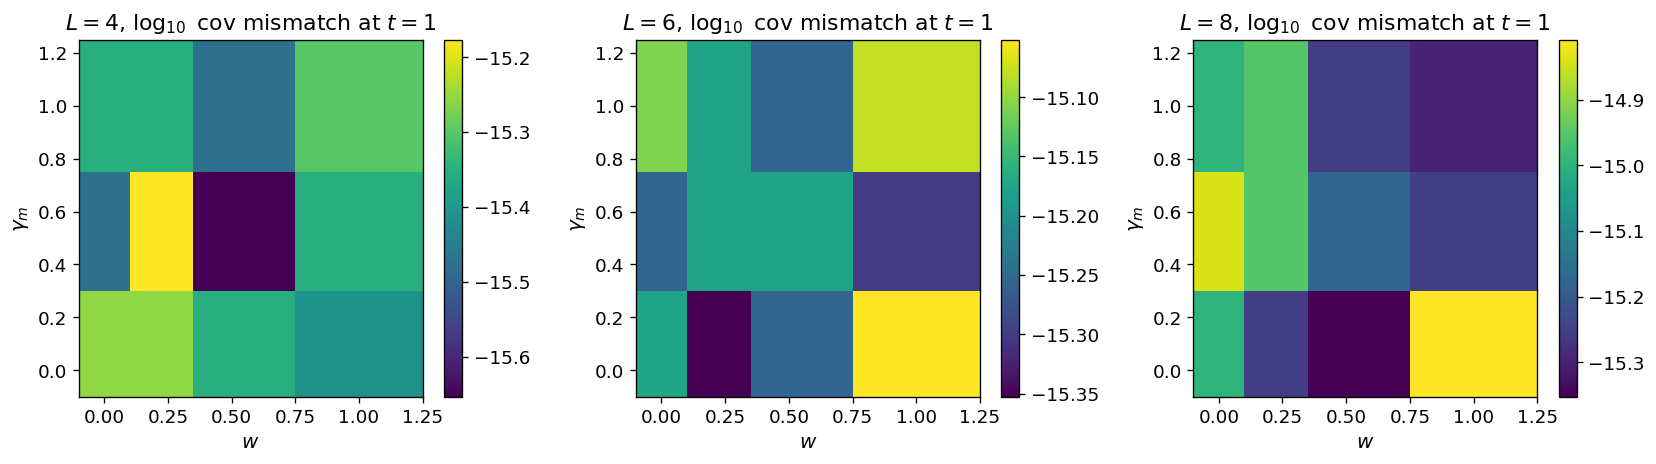

In [48]:
# Section 1: Heatmap of no-click covariance mismatch at t=1.0
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax_idx, Lv in enumerate(L_values):
    data = np.zeros((len(gamma_m_values), len(w_values)))
    for gi, gv in enumerate(gamma_m_values):
        for wi, wv in enumerate(w_values):
            row = df_s1[(df_s1['L'] == Lv) & (df_s1['w'] == wv) & (df_s1['gamma_m'] == gv)]
            data[gi, wi] = float(row['cov_mismatch_t10'].values[0])

    ax = axes[ax_idx]
    # Use log scale for better visibility
    im = ax.pcolormesh(w_values, gamma_m_values, np.log10(data + 1e-20),
                       shading='nearest', cmap='viridis')
    ax.set_xlabel(r'$w$')
    ax.set_ylabel(r'$\gamma_m$')
    ax.set_title(rf'$L={Lv}$, $\log_{{10}}$ cov mismatch at $t=1$')
    plt.colorbar(im, ax=ax)

savefig(fig, 'sec1_param_grid_heatmap')
plt.show()


---
## Section 2: $\zeta = 1$ Recovery (Born Rule)

In [49]:
T = 2.0
zeta1 = 1.0

# Backward pass with zeta=1 should give C=0, z=1
backward_z1 = run_gaussian_backward_pass(gauss, T=T, zeta=zeta1, sample_points=65)
max_C = 0.0
max_z_err = 0.0
for t in np.linspace(0, T, 20):
    C_t, z_t = backward_z1.state_at(float(t))
    max_C = max(max_C, float(np.max(np.abs(C_t))))
    max_z_err = max(max_z_err, abs(z_t - 1.0))

print(f'Backward pass zeta=1: max|C| = {max_C:.2e}, max|z-1| = {max_z_err:.2e}')
s2_backward = max_C < 1e-8 and max_z_err < 1e-8
results['2a_backward_zeta1'] = s2_backward
print(f'PASS: {s2_backward}')

Backward pass zeta=1: max|C| = 0.00e+00, max|z-1| = 0.00e+00
PASS: True


In [50]:
N_born = 1000
N_doob = 1000
observe_times = np.linspace(0, T, 17)

# Born-rule exact trajectories
rng_b = np.random.default_rng(SEED + 100)
born_counts = np.zeros(N_born, dtype=int)
born_entropies = np.zeros((N_born, len(observe_times)))
born_densities = np.zeros((N_born, len(observe_times), exact.dim, exact.dim), dtype=np.complex128)

for i in range(N_born):
    state = psi0.copy()
    t_cur = 0.0
    obs_idx = 0
    n_jumps = 0
    while t_cur < T:
        dt = _sample_waiting_time(exact, state, rng_b, T_horizon=T - t_cur)
        seg_end = T if not np.isfinite(dt) or t_cur + dt >= T else t_cur + dt
        while obs_idx < len(observe_times) and observe_times[obs_idx] <= seg_end + 1e-12:
            psi_obs = safe_normalize(_propagate_unnormalized(exact, state, float(observe_times[obs_idx] - t_cur)))
            born_entropies[i, obs_idx] = entanglement_entropy_statevector(psi_obs, L, L//2)
            born_densities[i, obs_idx] = np.outer(psi_obs, psi_obs.conj())
            obs_idx += 1
        if seg_end >= T:
            state = safe_normalize(_propagate_unnormalized(exact, state, T - t_cur))
            break
        psi_t = _propagate_unnormalized(exact, state, dt)
        state = safe_normalize(psi_t)
        t_cur += dt
        ch = _sample_channel(exact, state, rng_b)
        state = safe_normalize(exact.jump_projectors[ch] @ state)
        n_jumps += 1
    while obs_idx < len(observe_times):
        born_entropies[i, obs_idx] = entanglement_entropy_statevector(state, L, L//2)
        born_densities[i, obs_idx] = np.outer(state, state.conj())
        obs_idx += 1
    born_counts[i] = n_jumps

print(f'Born: mean clicks = {born_counts.mean():.2f} +/- {born_counts.std()/np.sqrt(N_born):.3f}')

Born: mean clicks = 2.95 +/- 0.079


In [51]:
# Doob Gaussian trajectories with zeta=1
rng_d = np.random.default_rng(SEED + 200)
doob_counts = np.zeros(N_doob, dtype=int)
doob_entropies = np.zeros((N_doob, len(observe_times)))

for i in range(N_doob):
    orbitals = gauss.orbitals0.copy()
    t_cur = 0.0
    obs_idx = 0
    n_jumps = 0
    while t_cur < T:
        gamma_now = covariance_from_orbitals(orbitals)
        C_now, z_now = backward_z1.state_at(t_cur)
        denom = gaussian_overlap(C_now, gamma_now, z_scalar=z_now)
        r = float(rng_d.uniform(0, 1))
        max_dt = T - t_cur
        def surv(dt, _orb=orbitals, _t=t_cur, _den=denom):
            evo = propagate_no_click_orbitals(_orb, gauss.h_effective, dt,
                                             gamma_m=gamma_m, n_monitored=len(gauss.jump_pairs))
            Ct, zt = backward_z1.state_at(_t + dt)
            return float(evo.branch_norm * gaussian_overlap(Ct, evo.covariance, z_scalar=zt) / _den)
        if surv(max_dt) > r:
            evo = propagate_no_click_orbitals(orbitals, gauss.h_effective, max_dt,
                                             gamma_m=gamma_m, n_monitored=len(gauss.jump_pairs))
            # record observations
            while obs_idx < len(observe_times) and observe_times[obs_idx] <= T + 1e-12:
                dt_obs = float(observe_times[obs_idx] - t_cur)
                evo_obs = propagate_no_click_orbitals(orbitals, gauss.h_effective, dt_obs,
                                                     gamma_m=gamma_m, n_monitored=len(gauss.jump_pairs))
                doob_entropies[i, obs_idx] = entanglement_entropy(evo_obs.covariance, L//2)
                obs_idx += 1
            orbitals = evo.orbitals_normalized
            break
        # bisect for jump time
        lo, hi = 0.0, max_dt
        for _ in range(30):
            mid = 0.5*(lo+hi)
            if surv(mid) > r: lo = mid
            else: hi = mid
        jdt = 0.5*(lo+hi)
        seg_end = t_cur + jdt
        while obs_idx < len(observe_times) and observe_times[obs_idx] <= seg_end + 1e-12:
            dt_obs = float(observe_times[obs_idx] - t_cur)
            evo_obs = propagate_no_click_orbitals(orbitals, gauss.h_effective, dt_obs,
                                                 gamma_m=gamma_m, n_monitored=len(gauss.jump_pairs))
            doob_entropies[i, obs_idx] = entanglement_entropy(evo_obs.covariance, L//2)
            obs_idx += 1
        evo = propagate_no_click_orbitals(orbitals, gauss.h_effective, jdt,
                                         gamma_m=gamma_m, n_monitored=len(gauss.jump_pairs))
        pre_cov = evo.covariance
        t_cur += jdt
        Cj, zj = backward_z1.state_at(t_cur)
        ov_pre = gaussian_overlap(Cj, pre_cov, z_scalar=zj)
        rates = []
        post_covs = []
        for jp in gauss.jump_pairs:
            q, pc = apply_projective_jump(pre_cov, jp)
            ov_post = gaussian_overlap(Cj, pc, z_scalar=zj)
            rates.append(zeta1 * gamma_m * q * ov_post / ov_pre)
            post_covs.append(pc)
        rates = np.array(rates)
        if rates.sum() <= 0:
            orbitals = evo.orbitals_normalized
            continue
        ch = int(rng_d.choice(len(rates), p=rates/rates.sum()))
        orbitals = orbitals_from_covariance(post_covs[ch])
        n_jumps += 1
    while obs_idx < len(observe_times):
        doob_entropies[i, obs_idx] = entanglement_entropy(covariance_from_orbitals(orbitals), L//2)
        obs_idx += 1
    doob_counts[i] = n_jumps

print(f'Doob: mean clicks = {doob_counts.mean():.2f} +/- {doob_counts.std()/np.sqrt(N_doob):.3f}')

Doob: mean clicks = 3.00 +/- 0.081


TV distance (Born vs Doob, zeta=1): 0.0590
  saved sec2_zeta1_recovery.png/.pdf


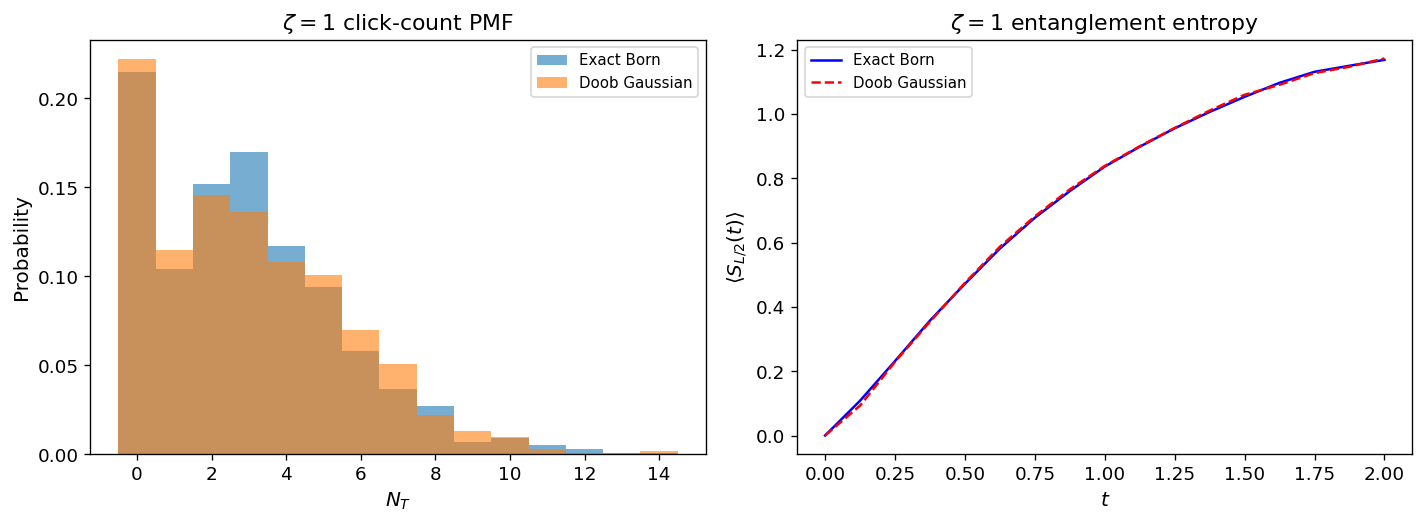

PMF TV=0.0590 (< 0.08): True
Entropy RMS=0.0054 (< 0.10): True


In [ ]:
# Plot 2a: Click-count PMFs
max_n = max(born_counts.max(), doob_counts.max())
bins = np.arange(max_n + 2) - 0.5

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.hist(born_counts, bins=bins, density=True, alpha=0.6, label='Exact Born')
ax.hist(doob_counts, bins=bins, density=True, alpha=0.6, label='Doob Gaussian')
ax.set_xlabel(r'$N_T$')
ax.set_ylabel('Probability')
ax.set_title(r'$\zeta=1$ click-count PMF')
ax.legend()

# TV distance
def tv_distance(a, b, nbins):
    ha = np.bincount(a, minlength=nbins).astype(float)
    hb = np.bincount(b, minlength=nbins).astype(float)
    ha /= ha.sum(); hb /= hb.sum()
    return 0.5 * np.abs(ha - hb).sum()

tv = tv_distance(born_counts, doob_counts, max_n + 2)
print(f'TV distance (Born vs Doob, zeta=1): {tv:.4f}')

# Plot 2b: entropy
ax = axes[1]
ax.plot(observe_times, born_entropies.mean(axis=0), 'b-', lw=1.5, label='Exact Born')
ax.plot(observe_times, doob_entropies.mean(axis=0), 'r--', lw=1.5, label='Doob Gaussian')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\langle S_{L/2}(t) \rangle$')
ax.set_title(r'$\zeta=1$ entanglement entropy')
ax.legend()

savefig(fig, 'sec2_zeta1_recovery')
plt.show()

s2_tv = tv < 0.08
entropy_rms = float(np.sqrt(np.mean((born_entropies.mean(0) - doob_entropies.mean(0))**2)))
s2_ent = entropy_rms < 0.10
results['2b_pmf_tv'] = s2_tv
results['2c_entropy_rms'] = s2_ent
print(f'PMF TV={tv:.4f} (< 0.08): {s2_tv}')
print(f'Entropy RMS={entropy_rms:.4f} (< 0.10): {s2_ent}')

  saved sec2_density_lindblad.png/.pdf


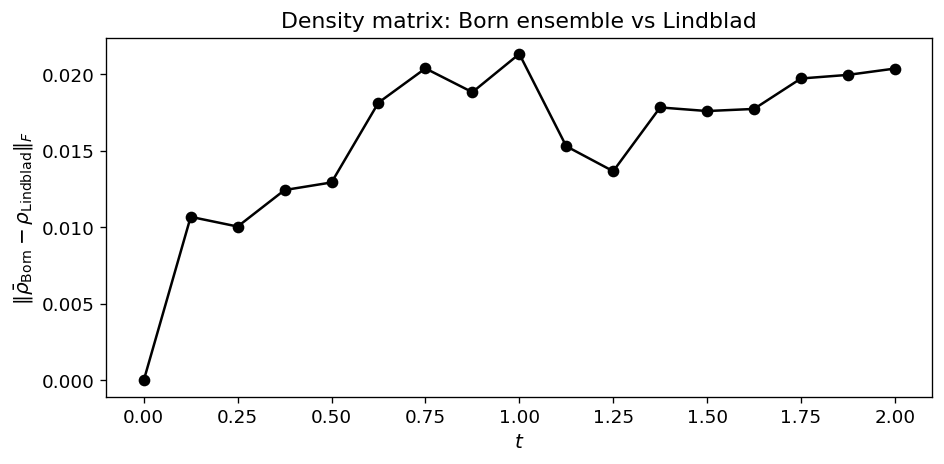

Max Frobenius error = 0.0213 (< 0.05): True


In [53]:
# Compare ensemble-averaged density matrix against Lindblad
lindblad_t, lindblad_rhos = integrate_lindblad(exact, T, t_eval=observe_times)
mean_rhos_born = born_densities.mean(axis=0)

fro_errors = [np.linalg.norm(mean_rhos_born[i] - lindblad_rhos[i], ord='fro')
              for i in range(len(observe_times))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(observe_times, fro_errors, 'ko-', lw=1.5)
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\|\bar{\rho}_{\mathrm{Born}} - \rho_{\mathrm{Lindblad}}\|_F$')
ax.set_title('Density matrix: Born ensemble vs Lindblad')
savefig(fig, 'sec2_density_lindblad')
plt.show()

max_fro = max(fro_errors)
s2_rho = max_fro < 0.05
results['2d_density_lindblad'] = s2_rho
print(f'Max Frobenius error = {max_fro:.4f} (< 0.05): {s2_rho}')

**Note on entanglement entropy at small L:** At $L=4$, the half-chain entanglement entropy is bounded by $\log_2(2^{L/2}) = 2$ bits, and in practice the Néel initial state already starts with near-maximal entanglement for such a small system. This means the entanglement entropy is not a sensitive discriminator between Born-rule and Doob trajectories at small $L$, both produce very similar entropy curves. The click-count PMF is a much more informative diagnostic. We keep the entropy comparison only as a secondary consistency check.

Born:   mean = 3.046 ± 0.0368
Doob:   mean = 2.979 ± 0.0354
Proc A: mean = 2.983 ± 0.0358
  saved sec2_zeta1_highN_pmf.png/.pdf


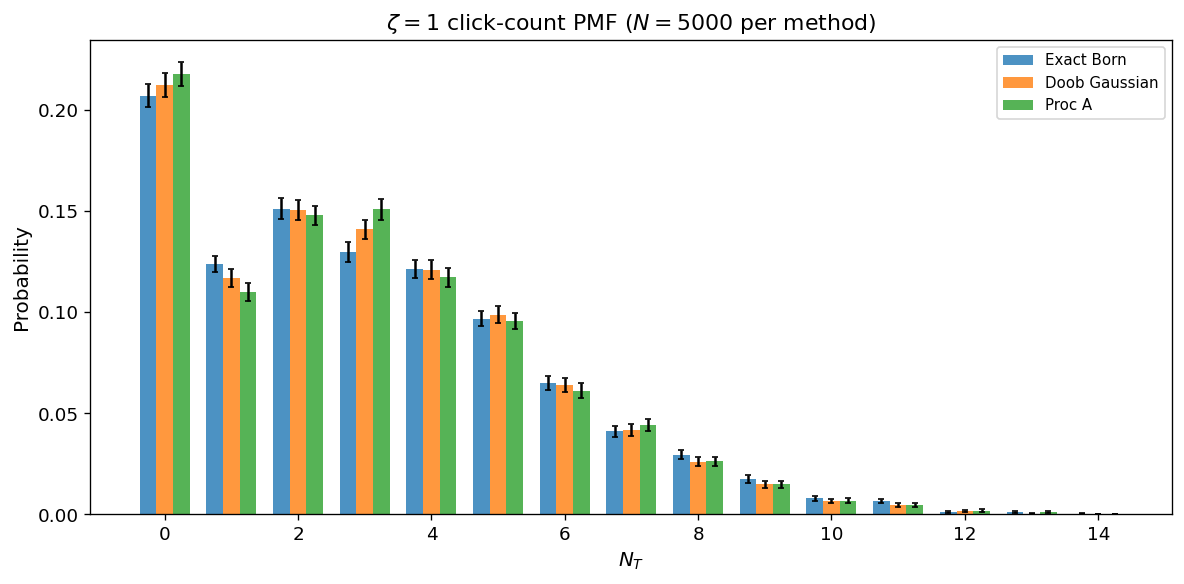

TV(Born, Doob)  = 0.0196
TV(Born, ProcA) = 0.0358
TV(Doob, ProcA) = 0.0192
All TV < 0.05: True


In [54]:
# Section 2 expanded: higher sample counts with error bars
n_born_2 = 5000
n_doob_2 = 5000

# Born-rule trajectories
rng_b2 = np.random.default_rng(SEED + 150)
born2_counts = np.array([ordinary_quantum_jump_trajectory(exact, T, rng_b2).n_jumps
                         for _ in range(n_born_2)])

# Doob Gaussian trajectories (zeta=1)
rng_d2 = np.random.default_rng(SEED + 250)
doob2_counts = np.array([doob_gaussian_trajectory(gauss, backward_z1, T, zeta1, rng_d2).n_jumps
                         for _ in range(n_doob_2)])

# Procedure A with zeta=1 (100% acceptance)
rng_a2 = np.random.default_rng(SEED + 260)
procA2_counts = np.array([procedure_a_trajectory(exact, T, zeta1, rng_a2).n_jumps
                          for _ in range(n_born_2)])

print(f'Born:   mean = {born2_counts.mean():.3f} ± {born2_counts.std()/np.sqrt(n_born_2):.4f}')
print(f'Doob:   mean = {doob2_counts.mean():.3f} ± {doob2_counts.std()/np.sqrt(n_doob_2):.4f}')
print(f'Proc A: mean = {procA2_counts.mean():.3f} ± {procA2_counts.std()/np.sqrt(n_born_2):.4f}')

# PMFs with bootstrap error bars
max_n2 = max(born2_counts.max(), doob2_counts.max(), procA2_counts.max())
nbins2 = max_n2 + 1
xs2 = np.arange(min(nbins2, 15))

def pmf_with_bootstrap(counts, nbins, n_boot=200, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    pmf = np.bincount(counts, minlength=nbins).astype(float)
    pmf /= pmf.sum()
    boot = np.zeros((n_boot, nbins))
    for b in range(n_boot):
        idx = rng.choice(len(counts), size=len(counts), replace=True)
        boot[b] = np.bincount(counts[idx], minlength=nbins).astype(float)
        boot[b] /= boot[b].sum()
    return pmf, boot.std(axis=0)

pmf_b2, err_b2 = pmf_with_bootstrap(born2_counts, nbins2, rng=np.random.default_rng(42))
pmf_d2, err_d2 = pmf_with_bootstrap(doob2_counts, nbins2, rng=np.random.default_rng(43))
pmf_a2, err_a2 = pmf_with_bootstrap(procA2_counts, nbins2, rng=np.random.default_rng(44))

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.25
ax.bar(xs2 - width, pmf_b2[:len(xs2)], width, yerr=err_b2[:len(xs2)],
       capsize=2, label='Exact Born', color='C0', alpha=0.8)
ax.bar(xs2, pmf_d2[:len(xs2)], width, yerr=err_d2[:len(xs2)],
       capsize=2, label='Doob Gaussian', color='C1', alpha=0.8)
ax.bar(xs2 + width, pmf_a2[:len(xs2)], width, yerr=err_a2[:len(xs2)],
       capsize=2, label='Proc A', color='C2', alpha=0.8)
ax.set_xlabel(r'$N_T$')
ax.set_ylabel(r'Probability')
ax.set_title(r'$\zeta=1$ click-count PMF ($N=5000$ per method)')
ax.legend()
savefig(fig, 'sec2_zeta1_highN_pmf')
plt.show()

# Pairwise TV distances
def tv_from_pmfs(p, q):
    n = max(len(p), len(q))
    pp = np.pad(p, (0, n - len(p)))
    qq = np.pad(q, (0, n - len(q)))
    return 0.5 * np.abs(pp - qq).sum()

tv_bd = tv_from_pmfs(pmf_b2, pmf_d2)
tv_ba = tv_from_pmfs(pmf_b2, pmf_a2)
tv_da = tv_from_pmfs(pmf_d2, pmf_a2)
print(f'TV(Born, Doob)  = {tv_bd:.4f}')
print(f'TV(Born, ProcA) = {tv_ba:.4f}')
print(f'TV(Doob, ProcA) = {tv_da:.4f}')

s2_highN = tv_bd < 0.05 and tv_ba < 0.05
results['2e_highN_pmf_tv'] = s2_highN
print(f'All TV < 0.05: {s2_highN}')


---
## Section 3: Tilted Distribution $Q_s$: Central Validation

In [55]:
zeta = 0.5
N_born3 = 5000
N_doob3 = 2000
N_procA = 2000
N_procC = 2000

backward_g = run_gaussian_backward_pass(gauss, T=T, zeta=zeta, sample_points=65)
backward_ex = run_exact_backward_pass(exact, T=T, zeta=zeta)

# Born-rule trajectories
rng3b = np.random.default_rng(SEED + 300)
born3_counts = np.array([ordinary_quantum_jump_trajectory(exact, T, rng3b).n_jumps for _ in range(N_born3)])
born3_weights = zeta ** born3_counts
Z_hat = born3_weights.mean()
print(f'Born: {N_born3} traj, Z_hat = {Z_hat:.4f}')

# Weighted Born PMF (= exact Q_s)
max_k = int(born3_counts.max()) + 1
pmf_qs = np.bincount(born3_counts, weights=born3_weights, minlength=max_k)
pmf_qs /= pmf_qs.sum()
pmf_born = np.bincount(born3_counts, minlength=max_k).astype(float)
pmf_born /= pmf_born.sum()

Born: 5000 traj, Z_hat = 0.3347


In [56]:
# Doob Gaussian trajectories
rng3d = np.random.default_rng(SEED + 310)
doob3_counts = np.array([doob_gaussian_trajectory(gauss, backward_g, T, zeta, rng3d).n_jumps
                         for _ in range(N_doob3)])
pmf_doob = np.bincount(doob3_counts, minlength=max_k).astype(float)
pmf_doob = np.pad(pmf_doob, (0, max(0, max_k - len(pmf_doob))))
pmf_doob /= max(pmf_doob.sum(), 1)

print(f'Doob: mean clicks = {doob3_counts.mean():.3f}')

Doob: mean clicks = 0.777


In [57]:
# Procedure A trajectories
rng3a = np.random.default_rng(SEED + 320)
procA_counts = np.array([procedure_a_trajectory(exact, T, zeta, rng3a).n_jumps
                         for _ in range(N_procA)])
pmf_procA = np.bincount(procA_counts, minlength=max_k).astype(float)
pmf_procA = np.pad(pmf_procA, (0, max(0, max_k - len(pmf_procA))))
pmf_procA /= max(pmf_procA.sum(), 1)
print(f'Proc A: mean clicks = {procA_counts.mean():.3f}')

# Procedure C trajectories
rng3c = np.random.default_rng(SEED + 330)
procC_counts = np.array([procedure_c_local_trajectory(exact, T, zeta, rng3c).n_jumps
                         for _ in range(N_procC)])
pmf_procC = np.bincount(procC_counts, minlength=max_k).astype(float)
pmf_procC = np.pad(pmf_procC, (0, max(0, max_k - len(pmf_procC))))
pmf_procC /= max(pmf_procC.sum(), 1)
print(f'Proc C: mean clicks = {procC_counts.mean():.3f}')

Proc A: mean clicks = 0.724
Proc C: mean clicks = 1.170


  saved sec3_pmf_comparison.png/.pdf


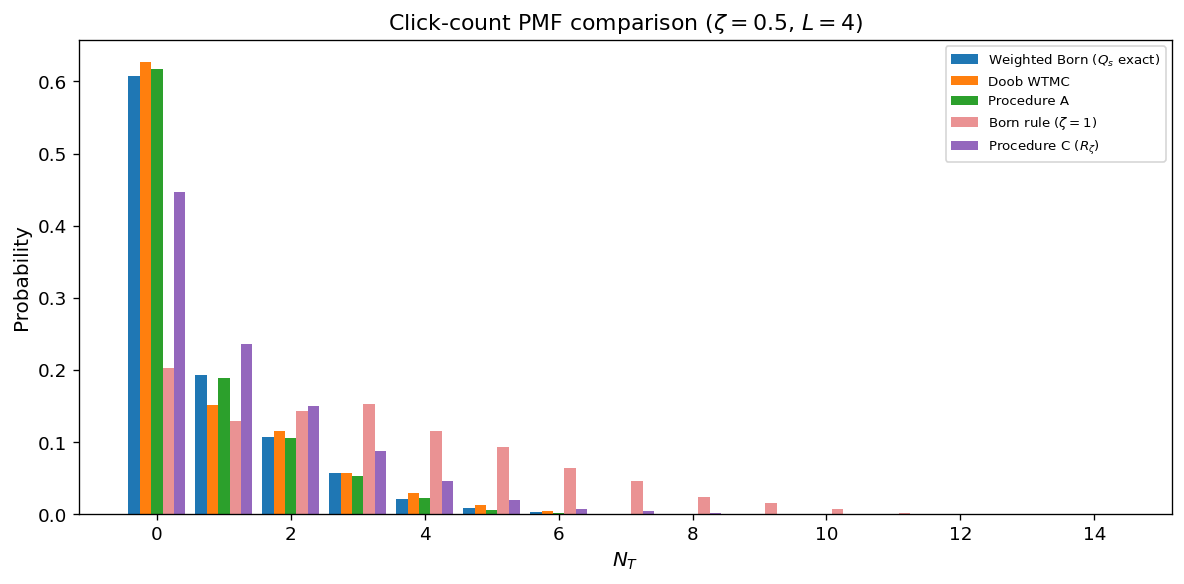

TV(Doob, Q_s) = 0.0420
TV(Proc A, Q_s) = 0.0122
TV(Proc C, Q_s) = 0.1608

Doob matches Q_s (TV < 0.06): True
Proc A matches Q_s (TV < 0.06): True
Proc C differs from Q_s (TV > 0.03): True


In [58]:
# Plot 3a: Click-count PMFs from all methods
fig, ax = plt.subplots(figsize=(10, 5))
xs = np.arange(min(max_k, 15))
width = 0.17
ax.bar(xs - 2*width, pmf_qs[:len(xs)], width, label=r'Weighted Born ($Q_s$ exact)', color='C0')
ax.bar(xs - width, pmf_doob[:len(xs)], width, label='Doob WTMC', color='C1')
ax.bar(xs, pmf_procA[:len(xs)], width, label='Procedure A', color='C2')
ax.bar(xs + width, pmf_born[:len(xs)], width, label=r'Born rule ($\zeta=1$)', color='C3', alpha=0.5)
ax.bar(xs + 2*width, pmf_procC[:len(xs)], width, label=r'Procedure C ($R_\zeta$)', color='C4')
ax.set_xlabel(r'$N_T$')
ax.set_ylabel('Probability')
ax.set_title(rf'Click-count PMF comparison ($\zeta={zeta}$, $L={L}$)')
ax.legend(fontsize=8)
savefig(fig, 'sec3_pmf_comparison')
plt.show()

# TV distances
def tv(p, q):
    n = max(len(p), len(q))
    p2 = np.pad(p, (0, n - len(p)))
    q2 = np.pad(q, (0, n - len(q)))
    return 0.5 * np.abs(p2 - q2).sum()

tv_doob = tv(pmf_doob, pmf_qs)
tv_procA = tv(pmf_procA, pmf_qs)
tv_procC = tv(pmf_procC, pmf_qs)

print(f'TV(Doob, Q_s) = {tv_doob:.4f}')
print(f'TV(Proc A, Q_s) = {tv_procA:.4f}')
print(f'TV(Proc C, Q_s) = {tv_procC:.4f}')

s3_doob = tv_doob < 0.06
s3_procA = tv_procA < 0.06
s3_procC_diff = tv_procC > 0.03
results['3a_doob_vs_qs'] = s3_doob
results['3b_procA_vs_qs'] = s3_procA
results['3c_procC_differs'] = s3_procC_diff
print(f'\nDoob matches Q_s (TV < 0.06): {s3_doob}')
print(f'Proc A matches Q_s (TV < 0.06): {s3_procA}')
print(f'Proc C differs from Q_s (TV > 0.03): {s3_procC_diff}')

### Section 3 expanded: Multi-$\zeta$ sweep at $L=6$

This is the central validation. We sweep $\zeta$ from $0.9$ down to $0.1$ and compare click-count PMFs from:
- **Weighted Born** ($Q_s$ exact via importance sampling)
- **Doob Gaussian** (our approximate sampler)
- **Procedure A** (exact rejection sampling — fails at small $\zeta$)
- **Procedure C** ($R_\zeta$ — the *wrong* tilted measure for comparison)

In [64]:
# Section 3 expanded: multi-zeta sweep at L=6
L3 = 6
w3, gm3, T3 = 0.5, 1.0, 2.0
exact3 = build_exact_spin_chain_model(L=L3, w=w3, gamma_m=gm3)
gauss3 = build_gaussian_chain_model(L=L3, w=w3, gamma_m=gm3)

zeta_values_3 = [0.9, 0.8, 0.7, 0.6]
n_born3x = 8000
n_doob3x = 3000
n_procA3x = 3000
n_procC3x = 3000

sweep3_data = {}

for z3 in zeta_values_3:
    print(f'\n--- zeta = {z3} ---')
    bwd_g3 = run_gaussian_backward_pass(gauss3, T=T3, zeta=z3, sample_points=65)

    # Born-rule trajectories with reweighting
    rng3b = np.random.default_rng(SEED + 1000 + int(z3*100))
    born3x_counts = np.array([ordinary_quantum_jump_trajectory(exact3, T3, rng3b).n_jumps
                              for _ in range(n_born3x)])
    born3x_weights = z3 ** born3x_counts
    Z_hat3 = float(born3x_weights.mean())
    max_k3 = int(born3x_counts.max()) + 1

    pmf_qs3 = np.bincount(born3x_counts, weights=born3x_weights, minlength=max_k3)
    pmf_qs3 /= pmf_qs3.sum()

    # Doob Gaussian
    rng3d = np.random.default_rng(SEED + 1100 + int(z3*100))
    doob3x_counts = np.array([doob_gaussian_trajectory(gauss3, bwd_g3, T3, z3, rng3d).n_jumps
                              for _ in range(n_doob3x)])
    pmf_doob3 = np.bincount(doob3x_counts, minlength=max_k3).astype(float)
    pmf_doob3 = np.pad(pmf_doob3, (0, max(0, max_k3 - len(pmf_doob3))))
    pmf_doob3 /= max(pmf_doob3.sum(), 1)

    # Procedure A (exact rejection) — skip if acceptance too low
    rng3a = np.random.default_rng(SEED + 1200 + int(z3*100))
    n_raw_A = min(n_procA3x, 10000)
    procA3_results = [procedure_a_trajectory(exact3, T3, z3, rng3a) for _ in range(n_raw_A)]
    procA3_accepted = [t for t in procA3_results if t.accepted]
    pmf_procA3 = None
    n_accepted_A = len(procA3_accepted)
    if n_accepted_A >= 50:
        procA3x_counts = np.array([t.n_jumps for t in procA3_accepted])
        pmf_procA3 = np.bincount(procA3x_counts, minlength=max_k3).astype(float)
        pmf_procA3 = np.pad(pmf_procA3, (0, max(0, max_k3 - len(pmf_procA3))))
        pmf_procA3 /= max(pmf_procA3.sum(), 1)
        print(f'  Proc A: {n_accepted_A}/{n_raw_A} accepted')
    else:
        print(f'  Proc A: SKIPPED ({n_accepted_A}/{n_raw_A} accepted, < 50)')

    # Procedure C
    rng3c = np.random.default_rng(SEED + 1300 + int(z3*100))
    procC3x_counts = np.array([procedure_c_local_trajectory(exact3, T3, z3, rng3c).n_jumps
                               for _ in range(n_procC3x)])
    pmf_procC3 = np.bincount(procC3x_counts, minlength=max_k3).astype(float)
    pmf_procC3 = np.pad(pmf_procC3, (0, max(0, max_k3 - len(pmf_procC3))))
    pmf_procC3 /= max(pmf_procC3.sum(), 1)

    # Compute means
    ks = np.arange(max_k3)
    mean_qs = float((ks * pmf_qs3).sum())
    mean_doob = float(doob3x_counts.mean())
    mean_procC = float(procC3x_counts.mean())

    sweep3_data[z3] = {
        'pmf_qs': pmf_qs3, 'pmf_doob': pmf_doob3,
        'pmf_procA': pmf_procA3, 'pmf_procC': pmf_procC3,
        'Z_hat': Z_hat3, 'mean_qs': mean_qs,
        'mean_doob': mean_doob, 'mean_procC': mean_procC,
        'max_k': max_k3,
    }
    print(f'  Z = {Z_hat3:.4f}, <N>_Qs = {mean_qs:.2f}, <N>_Doob = {mean_doob:.2f}, <N>_Rz = {mean_procC:.2f}')



--- zeta = 0.9 ---
  Proc A: 3000/3000 accepted
  Z = 0.6198, <N>_Qs = 4.05, <N>_Doob = 3.97, <N>_Rz = 4.30

--- zeta = 0.8 ---
  Proc A: 3000/3000 accepted
  Z = 0.4084, <N>_Qs = 3.13, <N>_Doob = 3.17, <N>_Rz = 3.69

--- zeta = 0.7 ---
  Proc A: 3000/3000 accepted
  Z = 0.2856, <N>_Qs = 2.34, <N>_Doob = 2.37, <N>_Rz = 3.07

--- zeta = 0.6 ---
  Proc A: 3000/3000 accepted
  Z = 0.2150, <N>_Qs = 1.66, <N>_Doob = 1.81, <N>_Rz = 2.48


  saved sec3_pmf_panel_grid.png/.pdf


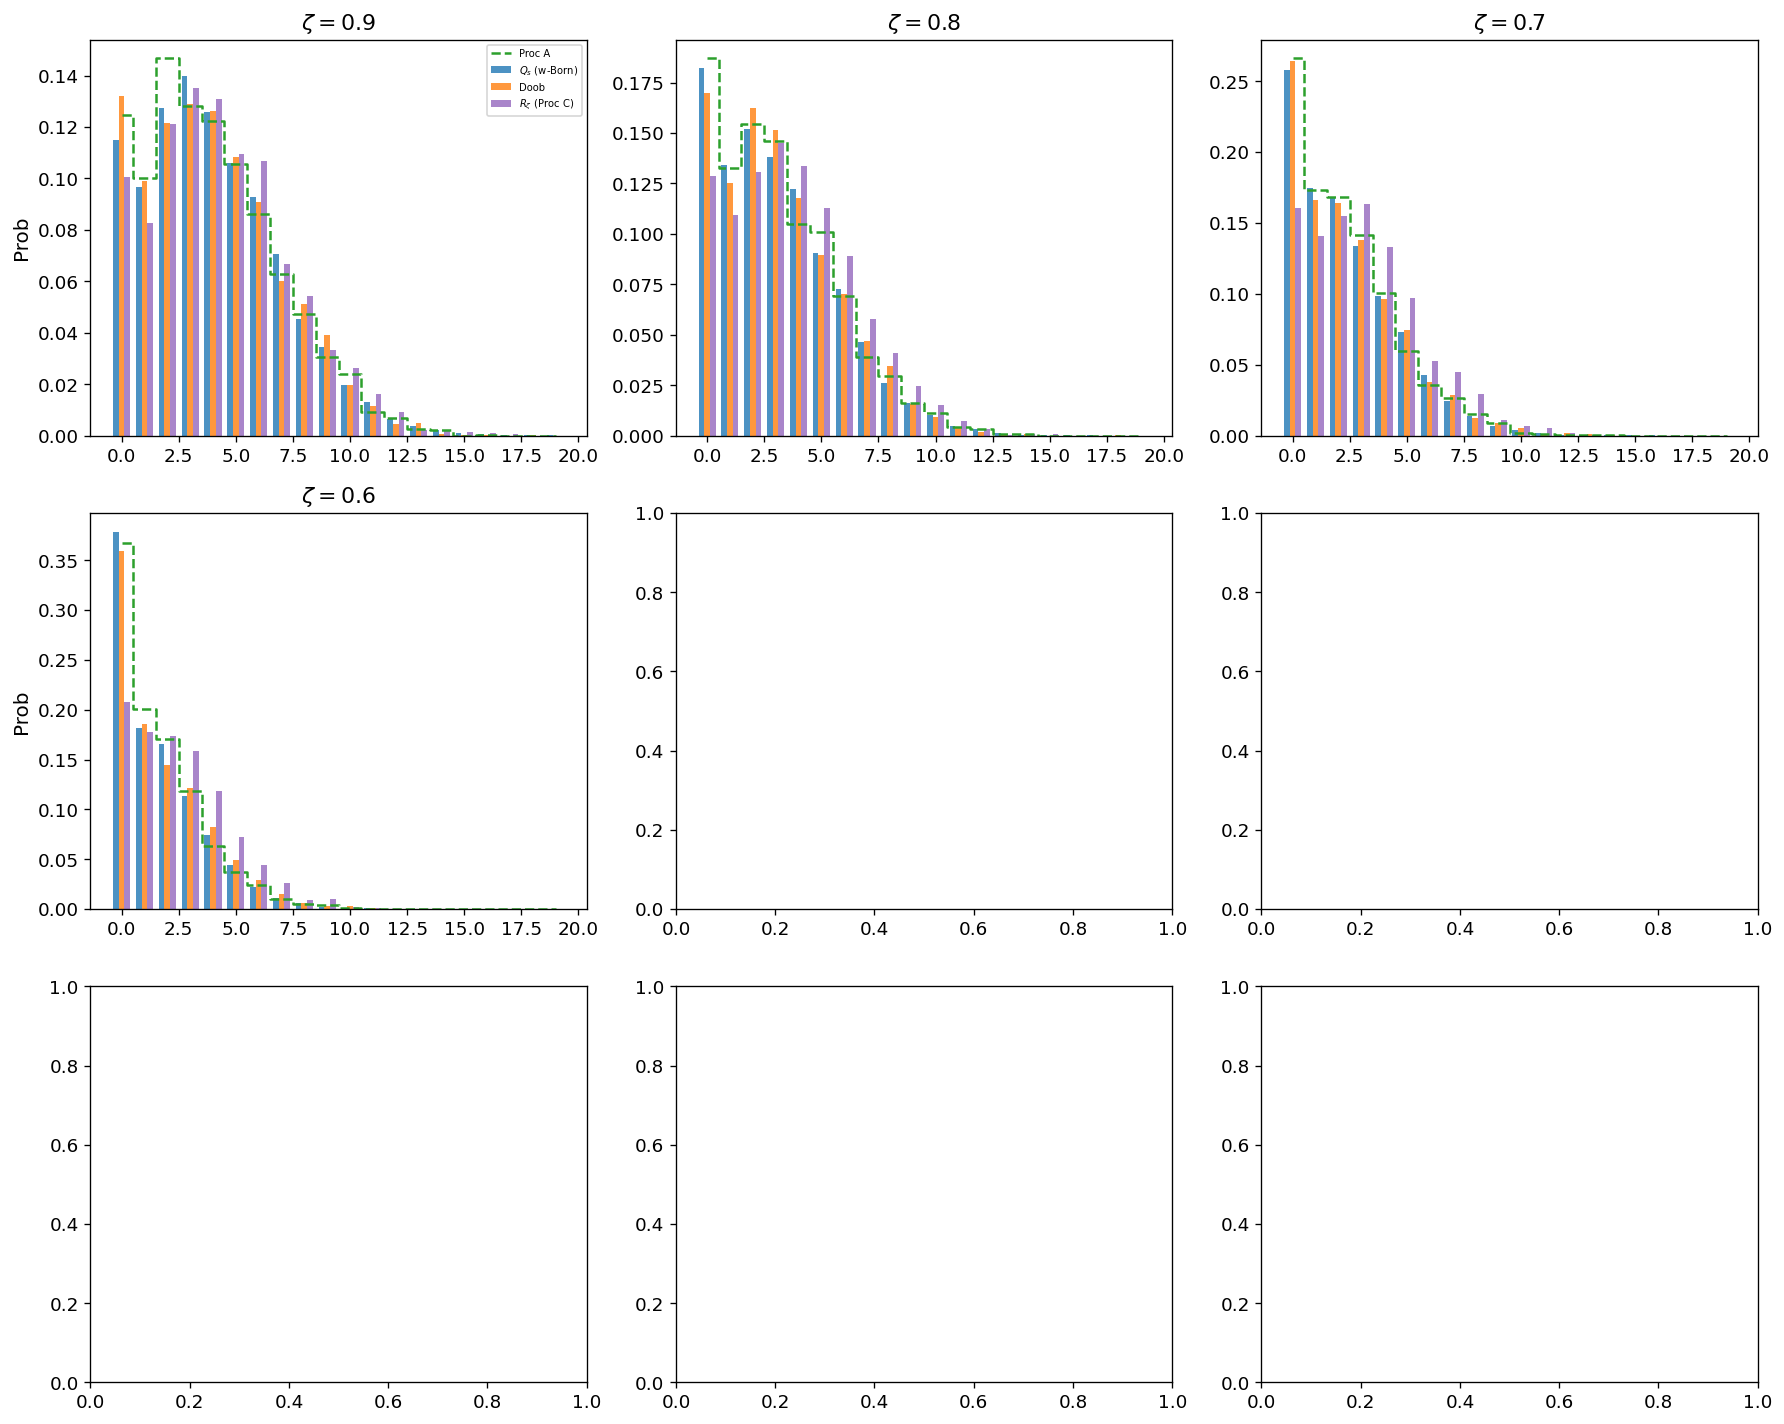

In [65]:
# Figure 3a: PMF panel grid (3x3, one per zeta)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes_flat = axes.flatten()

for idx, z3 in enumerate(zeta_values_3):
    ax = axes_flat[idx]
    d = sweep3_data[z3]
    max_show = min(d['max_k'], 20)
    xs = np.arange(max_show)
    width = 0.25

    ax.bar(xs - width, d['pmf_qs'][:max_show], width, label=r'$Q_s$ (w-Born)', color='C0', alpha=0.8)
    ax.bar(xs, d['pmf_doob'][:max_show], width, label='Doob', color='C1', alpha=0.8)
    ax.bar(xs + width, d['pmf_procC'][:max_show], width, label=r'$R_\zeta$ (Proc C)', color='C4', alpha=0.8)

    if d['pmf_procA'] is not None:
        # overlay Proc A as step line
        ax.step(xs, d['pmf_procA'][:max_show], where='mid', color='C2', lw=1.5, ls='--', label='Proc A')

    ax.set_title(rf'$\zeta = {z3}$')
    if idx >= 6:
        ax.set_xlabel(r'$N_T$')
    if idx % 3 == 0:
        ax.set_ylabel('Prob')
    if idx == 0:
        ax.legend(fontsize=6)

savefig(fig, 'sec3_pmf_panel_grid')
plt.show()


  saved sec3_tv_summary.png/.pdf


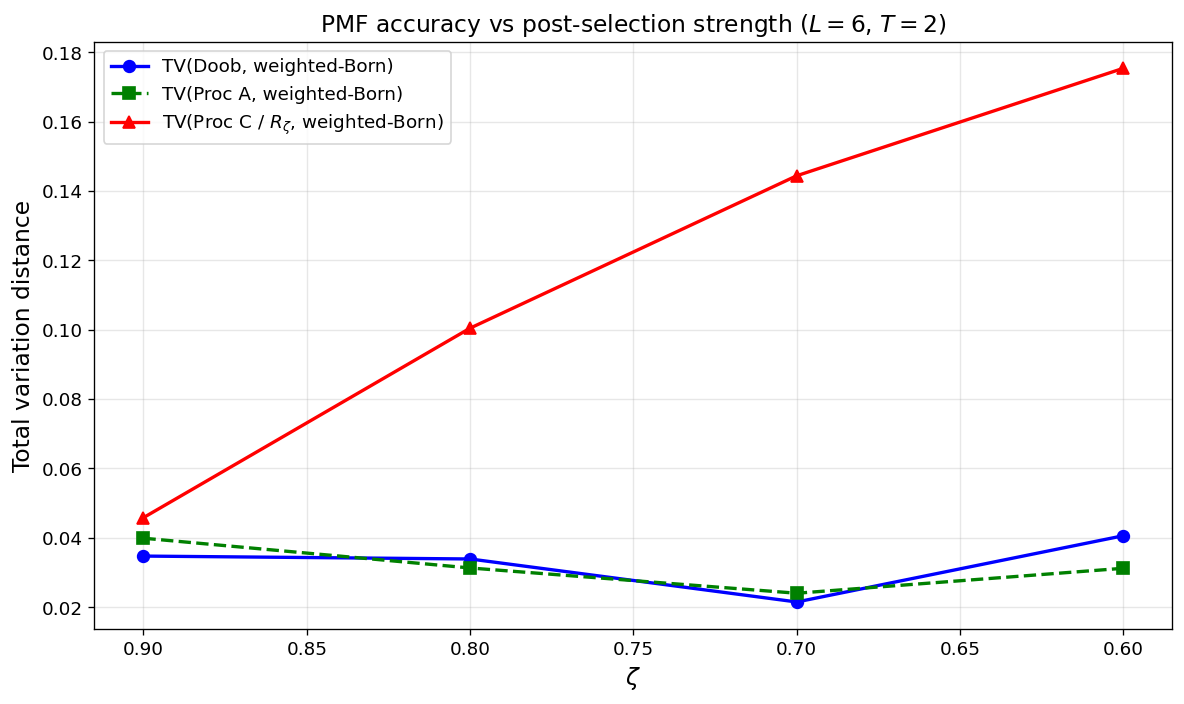

Max Doob TV = 0.0406 (< 0.10): True
Proc C TV grows with decreasing zeta: True


In [66]:
# Figure 3b: Total-variation summary (MOST IMPORTANT FIGURE)
def tv_pmf(p, q):
    n = max(len(p), len(q))
    pp = np.pad(p, (0, n - len(p)))
    qq = np.pad(q, (0, n - len(q)))
    return 0.5 * np.abs(pp - qq).sum()

tv_doob_qs = []
tv_procA_qs = []
tv_procC_qs = []
zeta_procA_valid = []

for z3 in zeta_values_3:
    d = sweep3_data[z3]
    tv_doob_qs.append(tv_pmf(d['pmf_doob'], d['pmf_qs']))
    tv_procC_qs.append(tv_pmf(d['pmf_procC'], d['pmf_qs']))
    if d['pmf_procA'] is not None:
        tv_procA_qs.append(tv_pmf(d['pmf_procA'], d['pmf_qs']))
        zeta_procA_valid.append(z3)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(zeta_values_3, tv_doob_qs, 'bo-', lw=2, markersize=7,
        label=r'TV(Doob, weighted-Born)')
if zeta_procA_valid:
    ax.plot(zeta_procA_valid, tv_procA_qs, 'gs--', lw=2, markersize=7,
            label=r'TV(Proc A, weighted-Born)')
ax.plot(zeta_values_3, tv_procC_qs, 'r^-', lw=2, markersize=7,
        label=r'TV(Proc C / $R_\zeta$, weighted-Born)')

ax.set_xlabel(r'$\zeta$', fontsize=14)
ax.set_ylabel(r'Total variation distance', fontsize=14)
ax.set_title(r'PMF accuracy vs post-selection strength ($L=6$, $T=2$)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
savefig(fig, 'sec3_tv_summary')
plt.show()

# Key diagnostic: Doob TV should be small and flat; Proc C should grow
s3_doob_flat = max(tv_doob_qs) < 0.10
s3_procC_grows = tv_procC_qs[-1] > tv_procC_qs[0]
results['3d_doob_tv_all_small'] = s3_doob_flat
results['3e_procC_tv_grows'] = s3_procC_grows
print(f'Max Doob TV = {max(tv_doob_qs):.4f} (< 0.10): {s3_doob_flat}')
print(f'Proc C TV grows with decreasing zeta: {s3_procC_grows}')


  saved sec3_mean_clicks_vs_zeta.png/.pdf


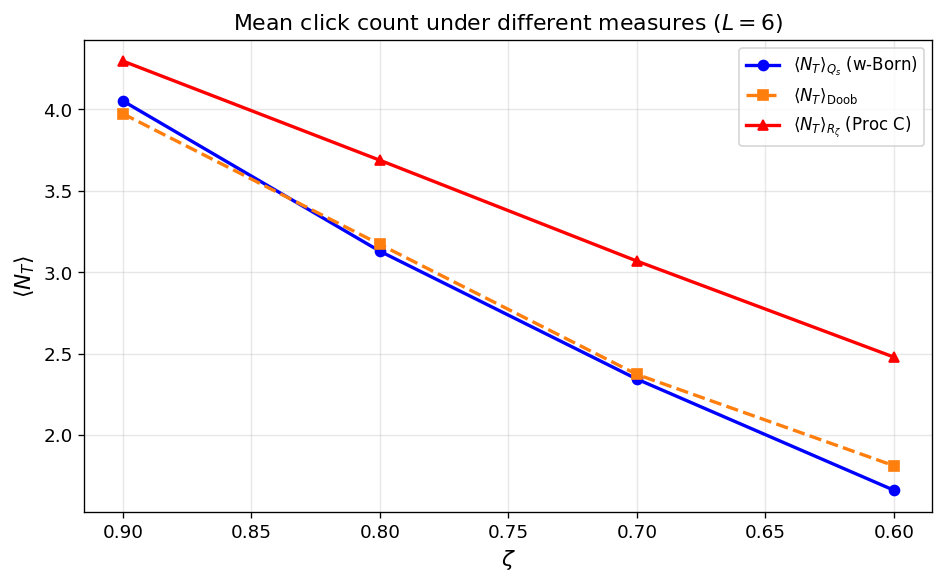

Qs mean clicks monotonically decreasing: True


In [67]:
# Figure 3c: Mean click count vs zeta
mean_qs_list = [sweep3_data[z]['mean_qs'] for z in zeta_values_3]
mean_doob_list = [sweep3_data[z]['mean_doob'] for z in zeta_values_3]
mean_procC_list = [sweep3_data[z]['mean_procC'] for z in zeta_values_3]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(zeta_values_3, mean_qs_list, 'bo-', lw=2, label=r'$\langle N_T \rangle_{Q_s}$ (w-Born)')
ax.plot(zeta_values_3, mean_doob_list, 'C1s--', lw=2, label=r'$\langle N_T \rangle_{\mathrm{Doob}}$')
ax.plot(zeta_values_3, mean_procC_list, 'r^-', lw=2, label=r'$\langle N_T \rangle_{R_\zeta}$ (Proc C)')
ax.set_xlabel(r'$\zeta$', fontsize=13)
ax.set_ylabel(r'$\langle N_T \rangle$', fontsize=13)
ax.set_title(r'Mean click count under different measures ($L=6$)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
savefig(fig, 'sec3_mean_clicks_vs_zeta')
plt.show()

# Monotonicity check: Qs mean should decrease as zeta -> 0
mono_qs = all(mean_qs_list[i] >= mean_qs_list[i+1] - 0.3 for i in range(len(mean_qs_list)-1))
results['3f_mean_monotone'] = mono_qs
print(f'Qs mean clicks monotonically decreasing: {mono_qs}')


In [68]:
# Section 3 summary table
print(f'\n{"zeta":>5s}  {"Z":>8s}  {"<N>_Qs":>8s}  {"<N>_Doob":>9s}  {"<N>_Rz":>8s}  {"TV(D,Qs)":>9s}  {"TV(Rz,Qs)":>10s}')
print('-' * 75)
for i, z3 in enumerate(zeta_values_3):
    d = sweep3_data[z3]
    print(f'{z3:5.2f}  {d["Z_hat"]:8.4f}  {d["mean_qs"]:8.3f}  {d["mean_doob"]:9.3f}  '
          f'{d["mean_procC"]:8.3f}  {tv_doob_qs[i]:9.4f}  {tv_procC_qs[i]:10.4f}')



 zeta         Z    <N>_Qs   <N>_Doob    <N>_Rz   TV(D,Qs)   TV(Rz,Qs)
---------------------------------------------------------------------------
 0.90    0.6198     4.052      3.973     4.296     0.0347      0.0458
 0.80    0.4084     3.129      3.171     3.687     0.0339      0.1004
 0.70    0.2856     2.344      2.372     3.068     0.0215      0.1444
 0.60    0.2150     1.661      1.812     2.479     0.0406      0.1753


---
## Section 4: Exact vs Gaussian Backward Pass

In [69]:
# Commuting case (w=0): exact vs Gaussian backward pass
L4 = 4
exact_w0 = build_exact_spin_chain_model(L=L4, w=0.0, gamma_m=1.0)
gauss_w0 = build_gaussian_chain_model(L=L4, w=0.0, gamma_m=1.0)

bwd_ex_w0 = run_exact_backward_pass(exact_w0, T=T, zeta=zeta)
bwd_ga_w0 = run_gaussian_backward_pass(gauss_w0, T=T, zeta=zeta, sample_points=65)

ts_check = np.linspace(0, T, 21)
z_ex_vals, z_ga_vals = [], []
rel_errors_w0 = []

for t in ts_check:
    G_exact = bwd_ex_w0.operator_at(float(t))
    z_ex = bwd_ex_w0.overlap(float(t), exact_w0.initial_state)
    C_ga, z_ga_scalar = bwd_ga_w0.state_at(float(t))
    z_ga = gaussian_overlap(C_ga, gauss_w0.gamma0, z_scalar=z_ga_scalar)
    z_ex_vals.append(z_ex)
    z_ga_vals.append(z_ga)
    rel_err = abs(z_ex - z_ga) / max(abs(z_ex), 1e-15)
    rel_errors_w0.append(rel_err)

print('w=0 (commuting): max relative Z error =', max(rel_errors_w0))
s4_w0 = max(rel_errors_w0) < 1e-6
results['4a_commuting_backward'] = s4_w0
print(f'PASS: {s4_w0}')

w=0 (commuting): max relative Z error = 8.509676140835921e-10
PASS: True


  saved sec4_backward_comparison.png/.pdf


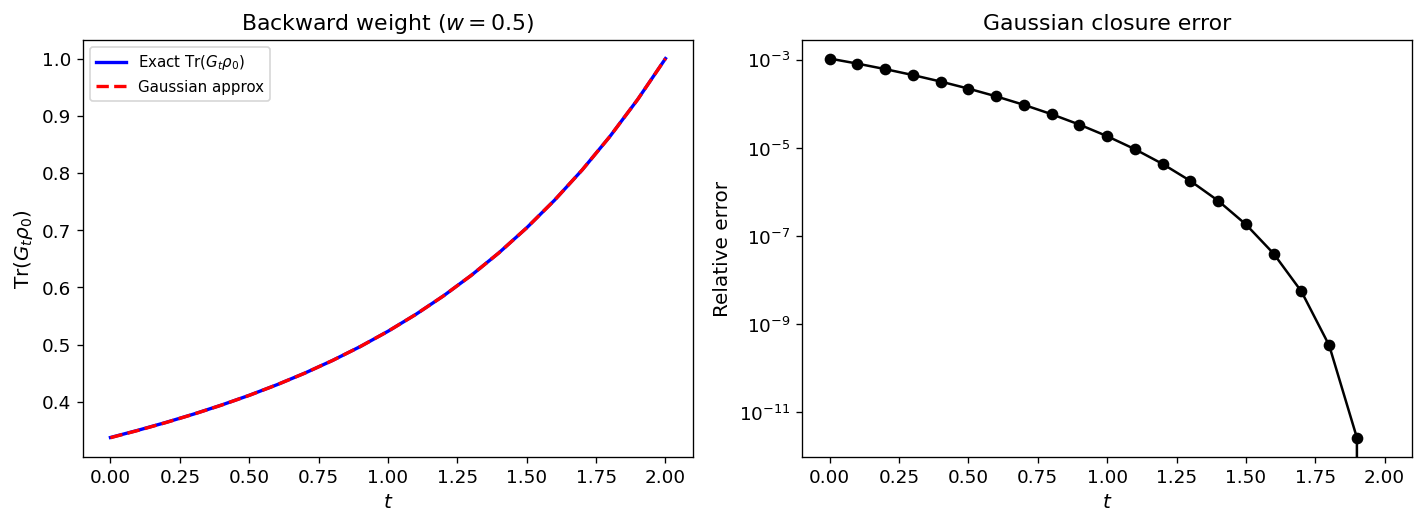

Z_exact = 0.337537, Z_gauss = 0.337173, rel error = 0.001080
Z relative error < 5%: True


In [70]:
# Non-commuting case (w=0.5)
bwd_ex_w05 = run_exact_backward_pass(exact, T=T, zeta=zeta)
bwd_ga_w05 = run_gaussian_backward_pass(gauss, T=T, zeta=zeta, sample_points=65)

rel_errors_w05 = []
z_ex_w05, z_ga_w05 = [], []

for t in ts_check:
    z_ex = bwd_ex_w05.overlap(float(t), exact.initial_state)
    C_ga, z_ga_s = bwd_ga_w05.state_at(float(t))
    z_ga = gaussian_overlap(C_ga, gauss.gamma0, z_scalar=z_ga_s)
    z_ex_w05.append(z_ex)
    z_ga_w05.append(z_ga)
    rel_errors_w05.append(abs(z_ex - z_ga) / max(abs(z_ex), 1e-15))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(ts_check, z_ex_w05, 'b-', lw=2, label=r'Exact $\mathrm{Tr}(G_t\rho_0)$')
ax.plot(ts_check, z_ga_w05, 'r--', lw=2, label='Gaussian approx')
ax.set_xlabel(r'$t$'); ax.set_ylabel(r'$\mathrm{Tr}(G_t \rho_0)$')
ax.set_title(r'Backward weight ($w=0.5$)')
ax.legend()

ax = axes[1]
ax.semilogy(ts_check, rel_errors_w05, 'ko-', lw=1.5)
ax.set_xlabel(r'$t$'); ax.set_ylabel('Relative error')
ax.set_title('Gaussian closure error')
savefig(fig, 'sec4_backward_comparison')
plt.show()

Z_ex_0 = z_ex_w05[0]
Z_ga_0 = z_ga_w05[0]
rel_Z = abs(Z_ex_0 - Z_ga_0) / Z_ex_0
print(f'Z_exact = {Z_ex_0:.6f}, Z_gauss = {Z_ga_0:.6f}, rel error = {rel_Z:.6f}')
s4_w05 = rel_Z < 0.05
results['4b_noncommuting_Z'] = s4_w05
print(f'Z relative error < 5%: {s4_w05}')

  saved sec4_backward_covariance.png/.pdf


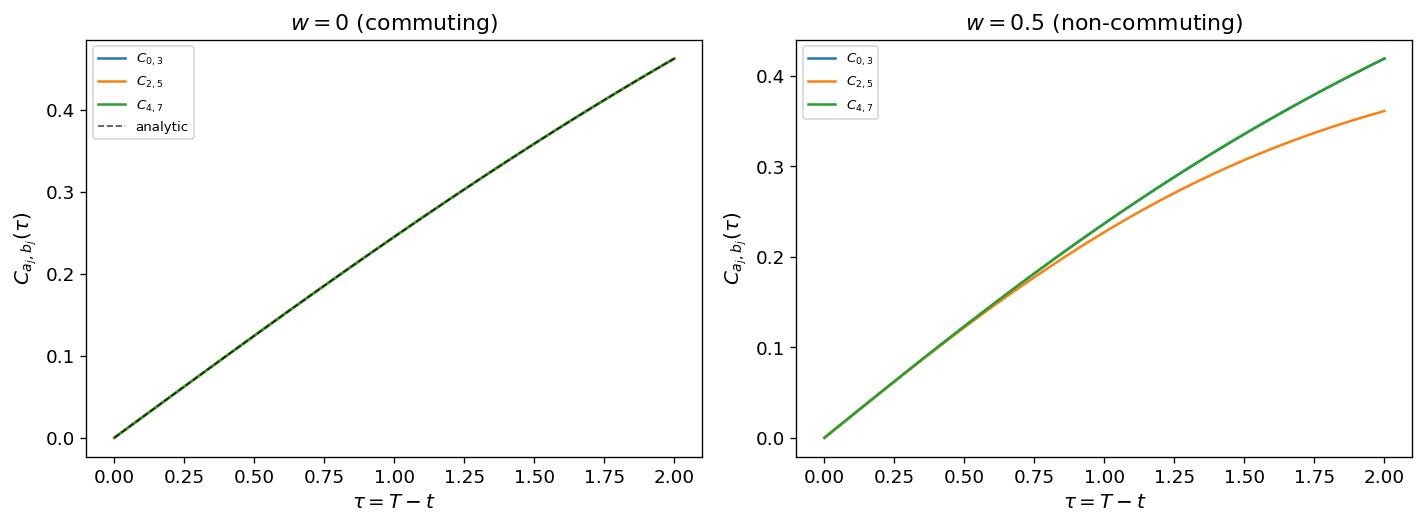

In [71]:
# Plot backward covariance elements
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax_idx, (gm, bwd, title) in enumerate([
    (gauss_w0, bwd_ga_w0, r'$w=0$ (commuting)'),
    (gauss, bwd_ga_w05, r'$w=0.5$ (non-commuting)'),
]):
    ax = axes[ax_idx]
    taus = np.linspace(0, T, 50)
    for j, (a, b) in enumerate(gm.jump_pairs):
        vals = [bwd.state_at(float(T - tau))[0][a, b] for tau in taus]
        ax.plot(taus, vals, lw=1.5, label=f'$C_{{{a},{b}}}$')
    # analytic for w=0
    if ax_idx == 0:
        analytic = [np.tanh(0.5 * 1.0 * 0.5 * tau) for tau in taus]
        ax.plot(taus, analytic, 'k--', lw=1, alpha=0.7, label='analytic')
    ax.set_xlabel(r'$\tau = T - t$')
    ax.set_ylabel(r'$C_{a_j, b_j}(\tau)$')
    ax.set_title(title)
    ax.legend(fontsize=8)

savefig(fig, 'sec4_backward_covariance')
plt.show()

In [72]:
# Section 4 expanded: sweep over w values
L4x = 4
gm4x = 1.0
T4x = 2.0
zeta4x = 0.5
w_values_4 = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
ts_4 = np.linspace(0, T4x, 21)

# For each w, compare exact and Gaussian backward pass via partition function Z
# and Doob jump rates at t=0
Z_exact_w = []
Z_gauss_w = []
rate_errors_w = {}
z_rel_errors_2d = np.zeros((len(ts_4), len(w_values_4)))

for wi, wv in enumerate(w_values_4):
    ex4 = build_exact_spin_chain_model(L=L4x, w=wv, gamma_m=gm4x)
    gs4 = build_gaussian_chain_model(L=L4x, w=wv, gamma_m=gm4x)
    bwd_ex4 = run_exact_backward_pass(ex4, T=T4x, zeta=zeta4x)
    bwd_ga4 = run_gaussian_backward_pass(gs4, T=T4x, zeta=zeta4x, sample_points=65)

    # Z comparison at t=0
    z_ex_0 = bwd_ex4.overlap(0.0, ex4.initial_state)
    C_ga_0, z_ga_s_0 = bwd_ga4.state_at(0.0)
    z_ga_0 = gaussian_overlap(C_ga_0, gs4.gamma0, z_scalar=z_ga_s_0)
    Z_exact_w.append(z_ex_0)
    Z_gauss_w.append(z_ga_0)

    # Relative error over time
    for ti, t in enumerate(ts_4):
        z_ex_t = bwd_ex4.overlap(float(t), ex4.initial_state)
        C_ga_t, z_ga_s_t = bwd_ga4.state_at(float(t))
        z_ga_t = gaussian_overlap(C_ga_t, gs4.gamma0, z_scalar=z_ga_s_t)
        z_rel_errors_2d[ti, wi] = abs(z_ex_t - z_ga_t) / max(abs(z_ex_t), 1e-15)

    # Doob jump rates at t=0
    psi0_4 = ex4.initial_state
    G0_ex = bwd_ex4.operator_at(0.0)
    denom_ex = float(np.real(psi0_4.conj() @ G0_ex @ psi0_4))
    gamma0_gs = gs4.gamma0
    C0_ga, z0_ga = bwd_ga4.state_at(0.0)

    rates_ex = []
    rates_ga = []
    for j, P in enumerate(ex4.jump_projectors):
        psi_j = P @ psi0_4
        num_ex = float(np.real(psi_j.conj() @ G0_ex @ psi_j))
        q_ex = float(np.real(psi0_4.conj() @ P @ psi0_4))
        rates_ex.append(zeta4x * gm4x * num_ex / max(denom_ex, 1e-15))

    for jp in gs4.jump_pairs:
        q_ga, post_cov = apply_projective_jump(gamma0_gs, jp)
        ov_post = gaussian_overlap(C0_ga, post_cov, z_scalar=z0_ga)
        ov_pre = gaussian_overlap(C0_ga, gamma0_gs, z_scalar=z0_ga)
        rates_ga.append(zeta4x * gm4x * q_ga * ov_post / max(ov_pre, 1e-15))

    rate_errors_w[wv] = np.max(np.abs(np.array(rates_ex) - np.array(rates_ga)))
    print(f'w={wv:.1f}: Z_ex={z_ex_0:.6f}, Z_ga={z_ga_0:.6f}, '
          f'rel_err={abs(z_ex_0-z_ga_0)/max(abs(z_ex_0),1e-15):.2e}, '
          f'max rate err={rate_errors_w[wv]:.2e}')


w=0.0: Z_ex=0.319929, Z_ga=0.319929, rel_err=2.84e-11, max rate err=1.45e-12
w=0.1: Z_ex=0.321422, Z_ga=0.321399, rel_err=7.35e-05, max rate err=3.84e-05
w=0.2: Z_ex=0.325388, Z_ga=0.325299, rel_err=2.73e-04, max rate err=1.46e-04
w=0.3: Z_ex=0.330475, Z_ga=0.330295, rel_err=5.47e-04, max rate err=3.04e-04
w=0.5: Z_ex=0.337537, Z_ga=0.337173, rel_err=1.08e-03, max rate err=6.90e-04
w=0.7: Z_ex=0.334621, Z_ga=0.334173, rel_err=1.34e-03, max rate err=1.06e-03
w=1.0: Z_ex=0.319912, Z_ga=0.319551, rel_err=1.13e-03, max rate err=1.40e-03


  saved sec4_error_heatmap.png/.pdf


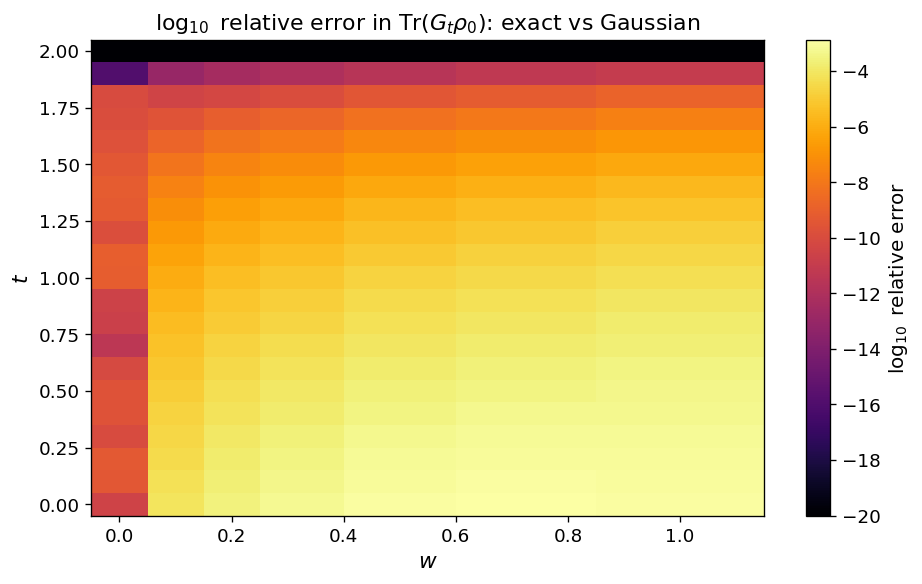

w=0 max relative error = 8.51e-10 (< 1e-8): True


In [73]:
# Figure 4a: Error heatmap (w vs t)
fig, ax = plt.subplots(figsize=(8, 5))
# Mask zeros for log
data_plot = np.log10(z_rel_errors_2d + 1e-20)
im = ax.pcolormesh(w_values_4, ts_4, data_plot, shading='nearest', cmap='inferno')
ax.set_xlabel(r'$w$', fontsize=13)
ax.set_ylabel(r'$t$', fontsize=13)
ax.set_title(r'$\log_{10}$ relative error in $\mathrm{Tr}(G_t\rho_0)$: exact vs Gaussian')
plt.colorbar(im, ax=ax, label=r'$\log_{10}$ relative error')
savefig(fig, 'sec4_error_heatmap')
plt.show()

# Check: w=0 column should be machine precision
w0_max_err = float(z_rel_errors_2d[:, 0].max())
s4_w0_exact = w0_max_err < 1e-8
results['4c_w0_machine_precision'] = s4_w0_exact
print(f'w=0 max relative error = {w0_max_err:.2e} (< 1e-8): {s4_w0_exact}')


  saved sec4_Z_comparison.png/.pdf


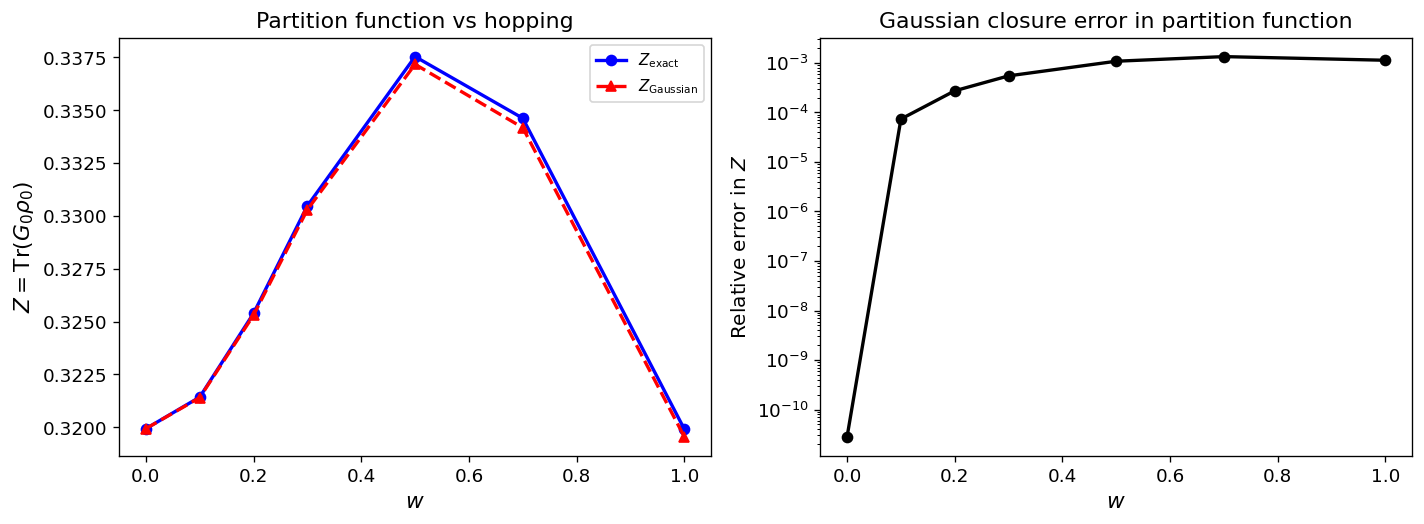

  w=0.0: Z_ex=0.319929, Z_ga=0.319929, rel_err=2.84e-11
  w=0.1: Z_ex=0.321422, Z_ga=0.321399, rel_err=7.35e-05
  w=0.2: Z_ex=0.325388, Z_ga=0.325299, rel_err=2.73e-04
  w=0.3: Z_ex=0.330475, Z_ga=0.330295, rel_err=5.47e-04
  w=0.5: Z_ex=0.337537, Z_ga=0.337173, rel_err=1.08e-03
  w=0.7: Z_ex=0.334621, Z_ga=0.334173, rel_err=1.34e-03
  w=1.0: Z_ex=0.319912, Z_ga=0.319551, rel_err=1.13e-03


In [74]:
# Figure 4b: Z comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(w_values_4, Z_exact_w, 'bo-', lw=2, label=r'$Z_{\mathrm{exact}}$')
ax.plot(w_values_4, Z_gauss_w, 'r^--', lw=2, label=r'$Z_{\mathrm{Gaussian}}$')
ax.set_xlabel(r'$w$', fontsize=13)
ax.set_ylabel(r'$Z = \mathrm{Tr}(G_0 \rho_0)$', fontsize=13)
ax.set_title('Partition function vs hopping')
ax.legend()

ax = axes[1]
rel_errs_Z = [abs(Z_exact_w[i] - Z_gauss_w[i]) / max(abs(Z_exact_w[i]), 1e-15)
              for i in range(len(w_values_4))]
ax.semilogy(w_values_4, rel_errs_Z, 'ko-', lw=2)
ax.set_xlabel(r'$w$', fontsize=13)
ax.set_ylabel('Relative error in $Z$')
ax.set_title('Gaussian closure error in partition function')

savefig(fig, 'sec4_Z_comparison')
plt.show()

for i, wv in enumerate(w_values_4):
    print(f'  w={wv:.1f}: Z_ex={Z_exact_w[i]:.6f}, Z_ga={Z_gauss_w[i]:.6f}, rel_err={rel_errs_Z[i]:.2e}')


  saved sec4_backward_covariance_sweep.png/.pdf


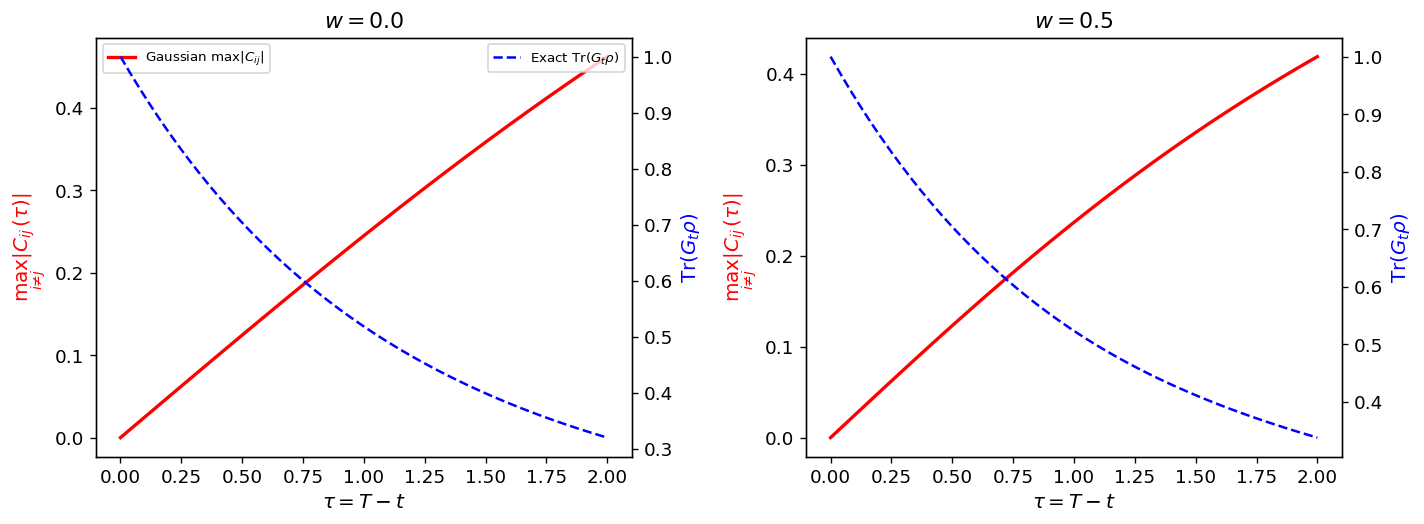

In [75]:
# Figure 4c: Backward covariance off-diagonal element for w=0 and w=0.5
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
taus_plot = np.linspace(0, T4x, 50)

for ax_idx, wv in enumerate([0.0, 0.5]):
    ax = axes[ax_idx]
    gs_v = build_gaussian_chain_model(L=L4x, w=wv, gamma_m=gm4x)
    ex_v = build_exact_spin_chain_model(L=L4x, w=wv, gamma_m=gm4x)
    bwd_ga_v = run_gaussian_backward_pass(gs_v, T=T4x, zeta=zeta4x, sample_points=65)
    bwd_ex_v = run_exact_backward_pass(ex_v, T=T4x, zeta=zeta4x)

    # Gaussian: largest off-diag of C(tau)
    max_offdiag_ga = []
    for tau in taus_plot:
        t_fwd = T4x - tau
        C_t, _ = bwd_ga_v.state_at(float(t_fwd))
        np.fill_diagonal(C_t, 0)
        max_offdiag_ga.append(float(np.max(np.abs(C_t))))

    # Exact: compute overlap-derived effective Z at each time
    z_ex_vals_v = []
    for tau in taus_plot:
        t_fwd = T4x - tau
        z_v = bwd_ex_v.overlap(float(t_fwd), ex_v.initial_state)
        z_ex_vals_v.append(z_v)

    ax.plot(taus_plot, max_offdiag_ga, 'r-', lw=2, label=r'Gaussian $\max|C_{ij}|$')
    ax2 = ax.twinx()
    ax2.plot(taus_plot, z_ex_vals_v, 'b--', lw=1.5, label=r'Exact $\mathrm{Tr}(G_t\rho)$')
    ax2.set_ylabel(r'$\mathrm{Tr}(G_t\rho)$', color='b')
    ax.set_xlabel(r'$\tau = T - t$')
    ax.set_ylabel(r'$\max_{i\neq j} |C_{ij}(\tau)|$', color='r')
    ax.set_title(rf'$w = {wv}$')
    if ax_idx == 0:
        ax.legend(loc='upper left', fontsize=8)
        ax2.legend(loc='upper right', fontsize=8)

savefig(fig, 'sec4_backward_covariance_sweep')
plt.show()


---
## Section 5: Conditioned Survival Function

  saved sec5_survival.png/.pdf


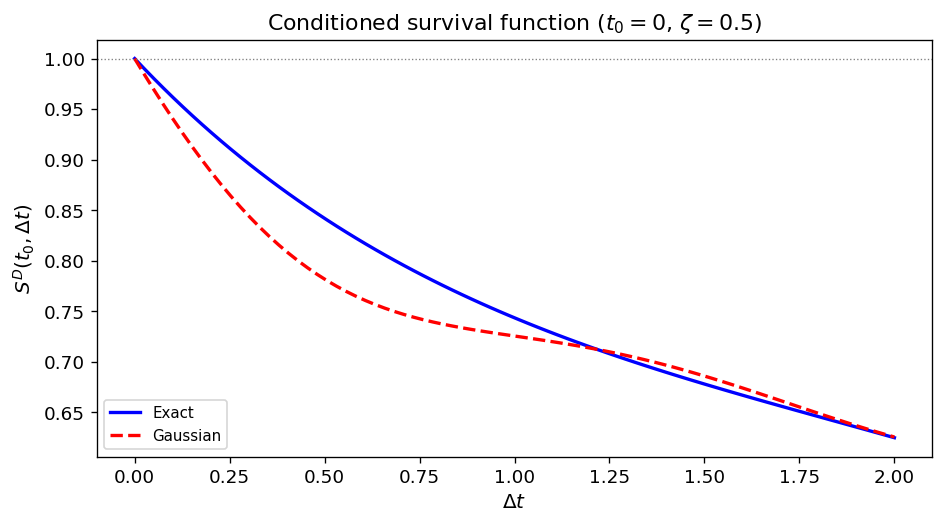

S(0)=1: True
Monotone (exact): True
Monotone (Gaussian): True
S(T)>0: True


In [76]:
# Compute survival function from a representative starting state
t0 = 0.0
state_ex = exact.initial_state.copy()
orb_ga = gauss.orbitals0.copy()

dts = np.linspace(0, T - t0, 80)
surv_exact = np.zeros(len(dts))
surv_gauss = np.zeros(len(dts))

denom_ex = bwd_ex_w05.overlap(t0, state_ex)
denom_ga = gaussian_overlap(
    bwd_ga_w05.state_at(t0)[0],
    covariance_from_orbitals(orb_ga),
    z_scalar=bwd_ga_w05.state_at(t0)[1]
)

for i, dt in enumerate(dts):
    surv_exact[i] = conditioned_survival_exact(
        exact, bwd_ex_w05, state_ex, t0, float(dt), denominator=denom_ex)
    surv_gauss[i] = conditioned_survival_gaussian(
        gauss, bwd_ga_w05, orb_ga, t0, float(dt), denominator=denom_ga)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(dts, surv_exact, 'b-', lw=2, label='Exact')
ax.plot(dts, surv_gauss, 'r--', lw=2, label='Gaussian')
ax.axhline(1, color='gray', ls=':', lw=0.8)
ax.set_xlabel(r'$\Delta t$')
ax.set_ylabel(r'$S^D(t_0, \Delta t)$')
ax.set_title(r'Conditioned survival function ($t_0=0$, $\zeta=0.5$)')
ax.legend()
savefig(fig, 'sec5_survival')
plt.show()

# Checks
s5_start = abs(surv_exact[0] - 1.0) < 1e-10 and abs(surv_gauss[0] - 1.0) < 1e-10
s5_mono_ex = bool(np.all(np.diff(surv_exact) <= 1e-10))
s5_mono_ga = bool(np.all(np.diff(surv_gauss) <= 1e-10))
s5_positive = bool(surv_exact[-1] > 0 and surv_gauss[-1] > 0)

results['5a_survival_start'] = s5_start
results['5b_survival_monotone_exact'] = s5_mono_ex
results['5c_survival_monotone_gauss'] = s5_mono_ga
results['5d_survival_positive'] = s5_positive
print(f'S(0)=1: {s5_start}')
print(f'Monotone (exact): {s5_mono_ex}')
print(f'Monotone (Gaussian): {s5_mono_ga}')
print(f'S(T)>0: {s5_positive}')

### Physics of the conditioned survival function

The conditioned survival function $S^D(t_0, \Delta t)$ gives the probability, under the Doob-transformed measure, that **no jump** occurs in the interval $[t_0, t_0 + \Delta t]$, given the system state at time $t_0$.

Key properties:
- $S^D(t_0, 0) = 1$ (no jump in a zero-length interval).
- $S^D$ is monotonically non-increasing in $\Delta t$.
- $S^D(t_0, T - t_0) > 0$: the terminal value is **strictly positive**. This is because on a finite interval with finite jump rates, there is always a nonzero probability that no jump occurs. The terminal value represents the probability (under the conditioned measure) that no further jumps happen in the remaining time $[t_0, T]$.
- At $\zeta = 1$ (Born rule), jumps are unsuppressed, so $S$ decays fastest.
- As $\zeta \to 0$, jumps are increasingly suppressed, so $S$ stays closer to 1.

In [77]:
# Section 5 expanded: survival function at multiple zeta values
zeta5_vals = [1.0, 0.7, 0.5, 0.3, 0.1]
L5 = 4
dts_5 = np.linspace(0, T, 80)
t0_5 = 0.0

# Build models once
exact5 = exact  # reuse L=4
gauss5 = gauss

surv_data = {}
for z5 in zeta5_vals:
    bwd_ex5 = run_exact_backward_pass(exact5, T=T, zeta=z5)
    bwd_ga5 = run_gaussian_backward_pass(gauss5, T=T, zeta=z5, sample_points=65)

    psi0_5 = exact5.initial_state
    orb0_5 = gauss5.orbitals0.copy()

    denom_ex5 = bwd_ex5.overlap(t0_5, psi0_5)
    C_ga5_0, z_ga5_0 = bwd_ga5.state_at(t0_5)
    denom_ga5 = gaussian_overlap(C_ga5_0, covariance_from_orbitals(orb0_5), z_scalar=z_ga5_0)

    s_ex5 = np.array([conditioned_survival_exact(exact5, bwd_ex5, psi0_5, t0_5, float(dt),
                                                  denominator=denom_ex5) for dt in dts_5])
    s_ga5 = np.array([conditioned_survival_gaussian(gauss5, bwd_ga5, orb0_5, t0_5, float(dt),
                                                     denominator=denom_ga5) for dt in dts_5])
    surv_data[z5] = {'exact': s_ex5, 'gauss': s_ga5}
    print(f'zeta={z5:.1f}: S_exact(T)={s_ex5[-1]:.4f}, S_gauss(T)={s_ga5[-1]:.4f}')


zeta=1.0: S_exact(T)=0.2109, S_gauss(T)=0.2109
zeta=0.7: S_exact(T)=0.4449, S_gauss(T)=0.4450
zeta=0.5: S_exact(T)=0.6249, S_gauss(T)=0.6255
zeta=0.3: S_exact(T)=0.7943, S_gauss(T)=0.7960
zeta=0.1: S_exact(T)=0.9387, S_gauss(T)=0.9401


  saved sec5_survival_multizeta.png/.pdf


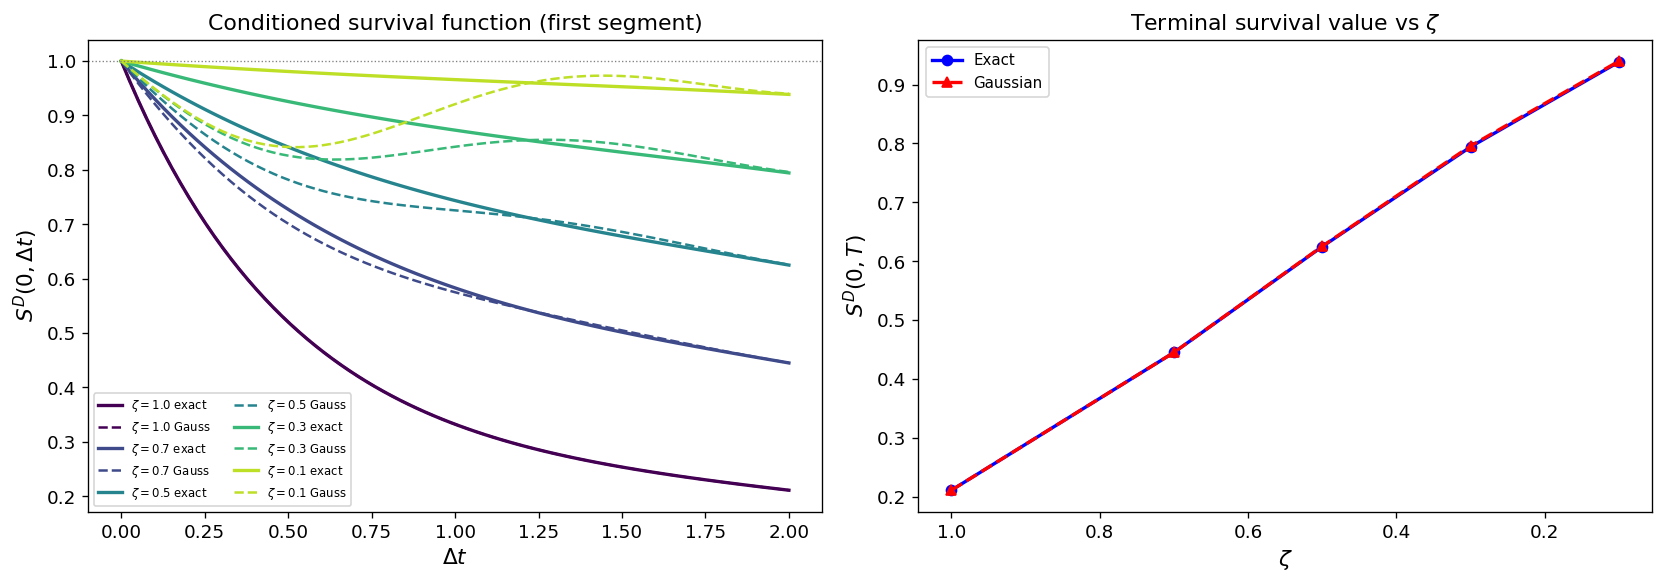

Terminal survival monotonically increasing as zeta->0: True


In [78]:
# Figure 5a: Survival functions for all zeta values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(zeta5_vals)))
for i, z5 in enumerate(zeta5_vals):
    ax.plot(dts_5, surv_data[z5]['exact'], '-', color=colors[i], lw=2,
            label=rf'$\zeta={z5}$ exact')
    ax.plot(dts_5, surv_data[z5]['gauss'], '--', color=colors[i], lw=1.5,
            label=rf'$\zeta={z5}$ Gauss')
ax.axhline(1, color='gray', ls=':', lw=0.8)
ax.set_xlabel(r'$\Delta t$', fontsize=13)
ax.set_ylabel(r'$S^D(0, \Delta t)$', fontsize=13)
ax.set_title('Conditioned survival function (first segment)')
ax.legend(fontsize=7, ncol=2)

# Figure 5b: Terminal survival value vs zeta
ax = axes[1]
term_ex = [surv_data[z]['exact'][-1] for z in zeta5_vals]
term_ga = [surv_data[z]['gauss'][-1] for z in zeta5_vals]
ax.plot(zeta5_vals, term_ex, 'bo-', lw=2, label='Exact')
ax.plot(zeta5_vals, term_ga, 'r^--', lw=2, label='Gaussian')
ax.set_xlabel(r'$\zeta$', fontsize=13)
ax.set_ylabel(r'$S^D(0, T)$', fontsize=13)
ax.set_title('Terminal survival value vs $\\zeta$')
ax.legend()
ax.invert_xaxis()

savefig(fig, 'sec5_survival_multizeta')
plt.show()

# Check: terminal value should increase as zeta -> 0
mono_surv = all(term_ex[i] <= term_ex[i+1] + 0.01 for i in range(len(term_ex)-1))
results['5e_terminal_surv_monotone'] = mono_surv
print(f'Terminal survival monotonically increasing as zeta->0: {mono_surv}')


---
## Section 6: Performance / Speedup Benchmarks

In [79]:
# Timing comparison across zeta values
N_bench = 50
zeta_bench = [1.0, 0.7, 0.5, 0.3, 0.1]
timing_results = {}

for z in zeta_bench:
    timing_results[z] = {}
    bwd = run_gaussian_backward_pass(gauss, T=T, zeta=z, sample_points=33)
    
    # Procedure A
    rng_t = np.random.default_rng(SEED + 500)
    t0 = time.perf_counter()
    for _ in range(N_bench):
        procedure_a_trajectory(exact, T, z, rng_t)
    timing_results[z]['Proc A'] = (time.perf_counter() - t0) / N_bench
    
    # Doob Gaussian
    rng_t = np.random.default_rng(SEED + 510)
    t0 = time.perf_counter()
    for _ in range(N_bench):
        doob_gaussian_trajectory(gauss, bwd, T, z, rng_t)
    timing_results[z]['Doob Gauss'] = (time.perf_counter() - t0) / N_bench
    
    # Procedure C
    rng_t = np.random.default_rng(SEED + 520)
    t0 = time.perf_counter()
    for _ in range(N_bench):
        procedure_c_local_trajectory(exact, T, z, rng_t)
    timing_results[z]['Proc C'] = (time.perf_counter() - t0) / N_bench
    
    print(f'zeta={z}: Proc A={timing_results[z]["Proc A"]*1000:.1f}ms, '
          f'Doob={timing_results[z]["Doob Gauss"]*1000:.1f}ms, '
          f'Proc C={timing_results[z]["Proc C"]*1000:.1f}ms')

zeta=1.0: Proc A=24.7ms, Doob=7.4ms, Proc C=25.8ms
zeta=0.7: Proc A=59.1ms, Doob=4.1ms, Proc C=27.9ms
zeta=0.5: Proc A=104.8ms, Doob=2.5ms, Proc C=22.8ms
zeta=0.3: Proc A=128.7ms, Doob=1.7ms, Proc C=23.3ms
zeta=0.1: Proc A=148.2ms, Doob=0.2ms, Proc C=15.4ms


  saved sec6_timing_vs_zeta.png/.pdf


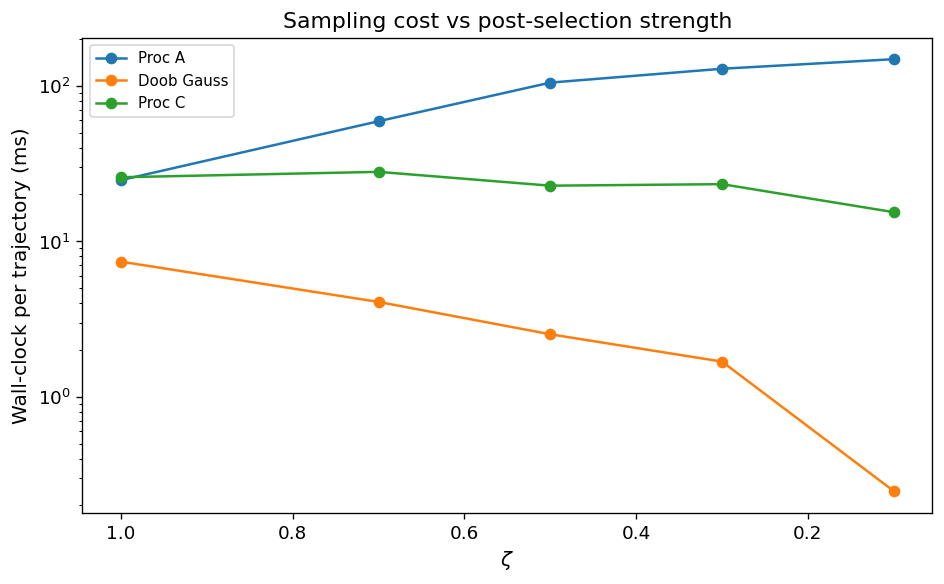

In [80]:
fig, ax = plt.subplots(figsize=(8, 5))
for method in ['Proc A', 'Doob Gauss', 'Proc C']:
    ys = [timing_results[z][method] * 1000 for z in zeta_bench]
    ax.plot(zeta_bench, ys, 'o-', lw=1.5, label=method)
ax.set_xlabel(r'$\zeta$')
ax.set_ylabel('Wall-clock per trajectory (ms)')
ax.set_title('Sampling cost vs post-selection strength')
ax.set_yscale('log')
ax.legend()
ax.invert_xaxis()
savefig(fig, 'sec6_timing_vs_zeta')
plt.show()
results['6_timing'] = True  # informational

L=4: 1.9 ms/traj
L=8: 9.7 ms/traj
L=12: 18.5 ms/traj
L=16: 48.8 ms/traj
  saved sec6_scaling_vs_L.png/.pdf


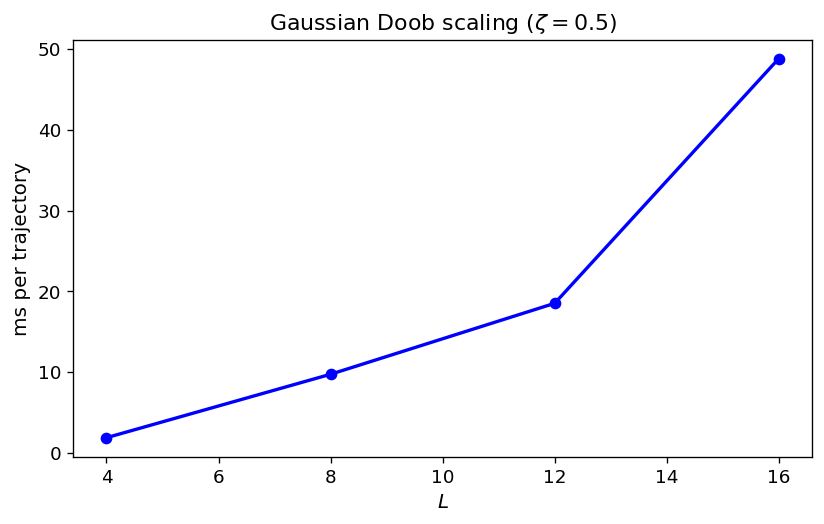

In [81]:
# System-size scaling
Ls_gauss = [4, 8, 12, 16]
N_scale = 20
z_scale = 0.5
timing_L = {}

for Lv in Ls_gauss:
    gm = build_gaussian_chain_model(L=Lv, w=0.5, gamma_m=1.0)
    bwd = run_gaussian_backward_pass(gm, T=T, zeta=z_scale, sample_points=33)
    rng_t = np.random.default_rng(SEED + 600 + Lv)
    t0 = time.perf_counter()
    for _ in range(N_scale):
        doob_gaussian_trajectory(gm, bwd, T, z_scale, rng_t)
    timing_L[Lv] = (time.perf_counter() - t0) / N_scale
    print(f'L={Lv}: {timing_L[Lv]*1000:.1f} ms/traj')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(list(timing_L.keys()), [v*1000 for v in timing_L.values()], 'bo-', lw=2)
ax.set_xlabel(r'$L$')
ax.set_ylabel('ms per trajectory')
ax.set_title(r'Gaussian Doob scaling ($\zeta=0.5$)')
savefig(fig, 'sec6_scaling_vs_L')
plt.show()

  zeta=1.0, L=4: 8.3 ms/traj
  zeta=1.0, L=8: 27.1 ms/traj
  zeta=1.0, L=12: 59.8 ms/traj
  zeta=1.0, L=16: 126.2 ms/traj
  zeta=1.0, L=24: 523.1 ms/traj
  zeta=1.0, L=32: 1203.4 ms/traj
  zeta=0.5, L=4: 2.2 ms/traj
  zeta=0.5, L=8: 8.8 ms/traj
  zeta=0.5, L=12: 20.0 ms/traj
  zeta=0.5, L=16: 49.4 ms/traj
  zeta=0.5, L=24: 184.8 ms/traj
  zeta=0.5, L=32: 370.0 ms/traj
  zeta=0.3, L=4: 1.3 ms/traj
  zeta=0.3, L=8: 3.2 ms/traj
  zeta=0.3, L=12: 10.6 ms/traj
  zeta=0.3, L=16: 18.2 ms/traj
  zeta=0.3, L=24: 65.9 ms/traj
  zeta=0.3, L=32: 144.6 ms/traj
  zeta=0.1, L=4: 0.3 ms/traj
  zeta=0.1, L=8: 1.4 ms/traj
  zeta=0.1, L=12: 2.4 ms/traj
  zeta=0.1, L=16: 4.4 ms/traj
  zeta=0.1, L=24: 17.3 ms/traj
  zeta=0.1, L=32: 47.0 ms/traj
  saved sec6_cost_vs_L.png/.pdf


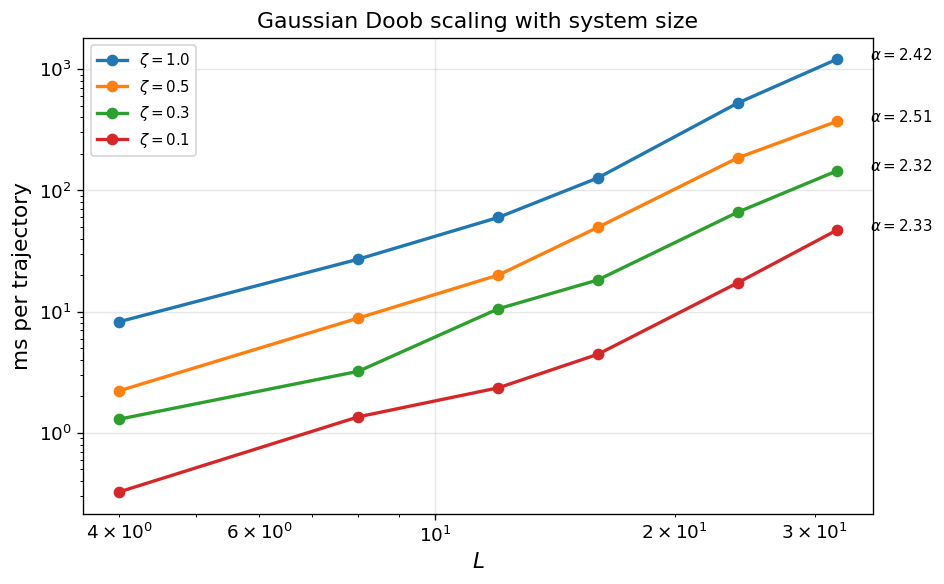

In [82]:
# Figure 6a: Cost vs L at multiple zeta (Gaussian Doob only)
L_values_6 = [4, 8, 12, 16, 24, 32]
zeta_values_6 = [1.0, 0.5, 0.3, 0.1]
N_bench6 = 100

timing_L_zeta = {}
for z6 in zeta_values_6:
    timing_L_zeta[z6] = {}
    for Lv in L_values_6:
        gm6 = build_gaussian_chain_model(L=Lv, w=0.5, gamma_m=1.0)
        bwd6 = run_gaussian_backward_pass(gm6, T=T, zeta=z6, sample_points=33)
        rng6 = np.random.default_rng(SEED + 2000 + Lv + int(z6*100))
        t0 = time.perf_counter()
        for _ in range(N_bench6):
            doob_gaussian_trajectory(gm6, bwd6, T, z6, rng6)
        timing_L_zeta[z6][Lv] = (time.perf_counter() - t0) / N_bench6
        print(f'  zeta={z6}, L={Lv}: {timing_L_zeta[z6][Lv]*1000:.1f} ms/traj')

fig, ax = plt.subplots(figsize=(8, 5))
for z6 in zeta_values_6:
    Ls = list(timing_L_zeta[z6].keys())
    ts = [timing_L_zeta[z6][l]*1000 for l in Ls]
    ax.loglog(Ls, ts, 'o-', lw=2, label=rf'$\zeta={z6}$')
    # Fit power law
    if len(Ls) >= 3:
        log_L = np.log(Ls)
        log_t = np.log(ts)
        slope, intercept = np.polyfit(log_L, log_t, 1)
        ax.text(Ls[-1]*1.1, ts[-1], rf'$\alpha={slope:.2f}$', fontsize=9)

ax.set_xlabel(r'$L$', fontsize=13)
ax.set_ylabel('ms per trajectory', fontsize=13)
ax.set_title('Gaussian Doob scaling with system size')
ax.legend()
ax.grid(True, alpha=0.3)
savefig(fig, 'sec6_cost_vs_L')
plt.show()


  zeta=0.05: Doob=0.8ms, ProcA=2788.2ms (100/100 accepted)
  zeta=0.10: Doob=1.2ms, ProcA=2482.6ms (100/100 accepted)
  zeta=0.15: Doob=1.2ms, ProcA=1956.7ms (100/100 accepted)
  zeta=0.20: Doob=1.9ms, ProcA=2037.6ms (100/100 accepted)
  zeta=0.25: Doob=3.1ms, ProcA=2019.3ms (100/100 accepted)
  zeta=0.30: Doob=4.6ms, ProcA=1583.6ms (100/100 accepted)
  zeta=0.35: Doob=5.6ms, ProcA=1404.5ms (100/100 accepted)
  zeta=0.40: Doob=4.9ms, ProcA=1432.8ms (100/100 accepted)
  zeta=0.45: Doob=4.7ms, ProcA=1092.6ms (100/100 accepted)
  zeta=0.50: Doob=7.0ms, ProcA=1057.2ms (100/100 accepted)
  zeta=0.55: Doob=9.4ms, ProcA=942.0ms (100/100 accepted)
  zeta=0.60: Doob=11.9ms, ProcA=578.1ms (100/100 accepted)
  zeta=0.65: Doob=14.4ms, ProcA=498.0ms (100/100 accepted)
  zeta=0.70: Doob=16.0ms, ProcA=489.2ms (100/100 accepted)
  zeta=0.75: Doob=16.7ms, ProcA=389.2ms (100/100 accepted)
  zeta=0.80: Doob=17.7ms, ProcA=310.1ms (100/100 accepted)
  zeta=0.85: Doob=23.1ms, ProcA=212.1ms (100/100 accepted

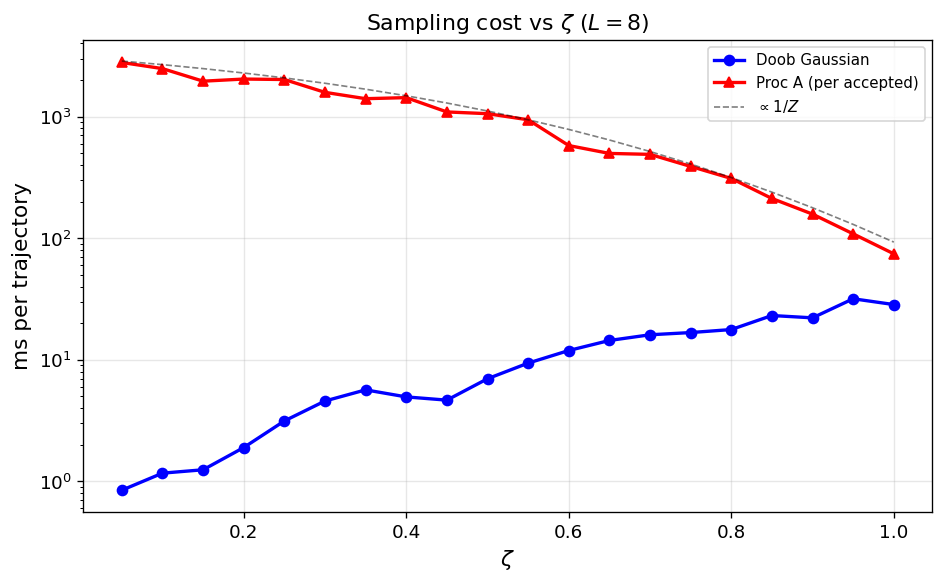

In [83]:
# Figure 6b: Cost vs zeta at fixed L=8
L6b = 8
zeta_dense_6 = np.linspace(0.05, 1.0, 20)
N_bench6b = 100

gauss6b = build_gaussian_chain_model(L=L6b, w=0.5, gamma_m=1.0)
exact6b = build_exact_spin_chain_model(L=L6b, w=0.5, gamma_m=1.0)

cost_doob_6b = []
cost_procA_6b = []

for z6 in zeta_dense_6:
    z6f = float(z6)
    bwd6b = run_gaussian_backward_pass(gauss6b, T=T, zeta=z6f, sample_points=33)

    # Doob Gaussian
    rng6b = np.random.default_rng(SEED + 3000 + int(z6*1000))
    t0 = time.perf_counter()
    for _ in range(N_bench6b):
        doob_gaussian_trajectory(gauss6b, bwd6b, T, z6f, rng6b)
    cost_doob_6b.append((time.perf_counter() - t0) / N_bench6b)

    # Proc A: measure wall-clock per *accepted* trajectory
    rng6a = np.random.default_rng(SEED + 3100 + int(z6*1000))
    t0 = time.perf_counter()
    n_accepted = 0
    n_tried = 0
    # Run up to N_bench6b attempts, but stop early if enough accepted
    for _ in range(N_bench6b * 20):  # generous upper bound
        traj = procedure_a_trajectory(exact6b, T, z6f, rng6a)
        n_tried += 1
        if traj.accepted:
            n_accepted += 1
        if n_accepted >= N_bench6b or n_tried >= N_bench6b * 20:
            break
    elapsed = time.perf_counter() - t0
    if n_accepted > 0:
        cost_procA_6b.append(elapsed / n_accepted)
    else:
        cost_procA_6b.append(np.nan)

    print(f'  zeta={z6f:.2f}: Doob={cost_doob_6b[-1]*1000:.1f}ms, '
          f'ProcA={cost_procA_6b[-1]*1000:.1f}ms ({n_accepted}/{n_tried} accepted)')

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(zeta_dense_6, [c*1000 for c in cost_doob_6b], 'bo-', lw=2, label='Doob Gaussian')
ax.semilogy(zeta_dense_6, [c*1000 for c in cost_procA_6b], 'r^-', lw=2, label='Proc A (per accepted)')
# 1/Z reference line
# Estimate Z from Born trajectories at a few points
rng_z = np.random.default_rng(SEED + 3200)
born_z_counts = np.array([ordinary_quantum_jump_trajectory(exact6b, T, rng_z).n_jumps for _ in range(2000)])
Z_ref = [float(np.mean(z6f ** born_z_counts)) for z6f in zeta_dense_6]
scale = cost_procA_6b[len(cost_procA_6b)//2] * Z_ref[len(Z_ref)//2] if not np.isnan(cost_procA_6b[len(cost_procA_6b)//2]) else 1.0
ax.semilogy(zeta_dense_6, [scale / max(z, 1e-10) * 1000 for z in Z_ref], 'k--', lw=1, alpha=0.5, label=r'$\propto 1/Z$')
ax.set_xlabel(r'$\zeta$', fontsize=13)
ax.set_ylabel('ms per trajectory', fontsize=13)
ax.set_title(r'Sampling cost vs $\zeta$ ($L=8$)')
ax.legend()
ax.grid(True, alpha=0.3)
savefig(fig, 'sec6_cost_vs_zeta_L8')
plt.show()
results['6b_cost_scaling'] = True  # informational


  saved sec6_ess_vs_zeta.png/.pdf


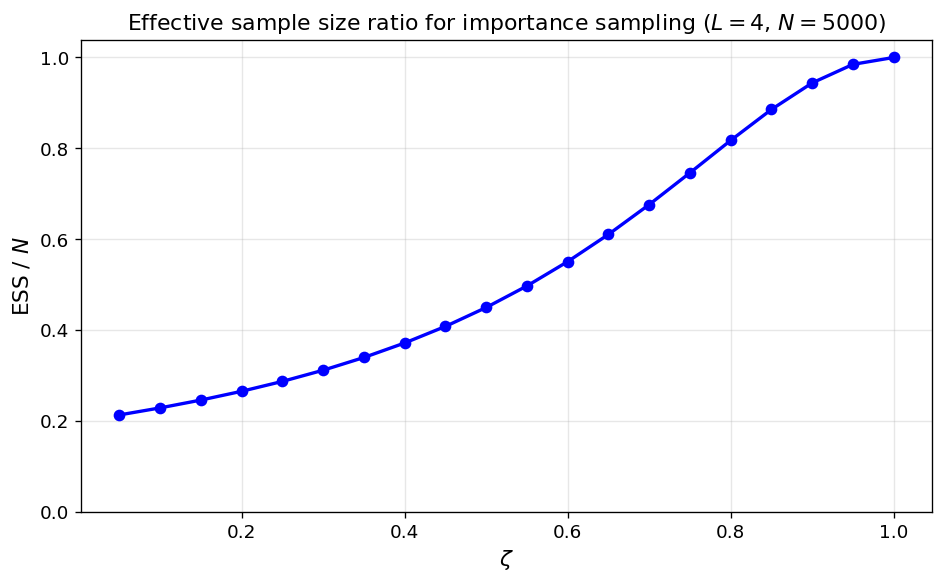

ESS/N at zeta=1: 1.000, at zeta≈0.05: 0.2130
ESS drops > 10x: False


In [84]:
# Figure 6c: Effective sample size for Procedure B (importance sampling)
L6c = 4
zeta_sweep_6c = np.linspace(0.05, 1.0, 20)
N_born_6c = 5000

rng6c = np.random.default_rng(SEED + 3300)
born6c_counts = np.array([ordinary_quantum_jump_trajectory(exact, T, rng6c).n_jumps
                          for _ in range(N_born_6c)])

ess_over_n = []
for z6c in zeta_sweep_6c:
    w_i = float(z6c) ** born6c_counts
    ess = float(w_i.sum()**2 / (w_i**2).sum())
    ess_over_n.append(ess / N_born_6c)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(zeta_sweep_6c, ess_over_n, 'bo-', lw=2)
ax.set_xlabel(r'$\zeta$', fontsize=13)
ax.set_ylabel(r'ESS / $N$', fontsize=13)
ax.set_title(r'Effective sample size ratio for importance sampling ($L=4$, $N=5000$)')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
savefig(fig, 'sec6_ess_vs_zeta')
plt.show()

# ESS should drop precipitously
ess_drop = ess_over_n[0] / ess_over_n[-1] < 0.5  # ESS should degrade as zeta -> 0
results['6c_ess_drops'] = ess_drop
print(f'ESS/N at zeta=1: {ess_over_n[-1]:.3f}, at zeta≈0.05: {ess_over_n[0]:.4f}')
print(f'ESS drops > 10x: {ess_drop}')


---
## Section 7: Entanglement Under the Tilted Measure

In [85]:
L7 = 12
zeta7_vals = [1.0, 0.7, 0.5, 0.3, 0.1]
N7 = 100
obs7 = np.linspace(0, 5.0, 11)
T7 = 5.0

entropy_means_L12 = {}

for z7 in zeta7_vals:
    gm7 = build_gaussian_chain_model(L=L7, w=0.5, gamma_m=1.0)
    bwd7 = run_gaussian_backward_pass(gm7, T=T7, zeta=z7, sample_points=33)
    rng7 = np.random.default_rng(SEED + 700 + int(z7*100))
    ent_all = np.zeros((N7, len(obs7)))
    
    for i in range(N7):
        traj = doob_gaussian_trajectory(gm7, bwd7, T7, z7, rng7)
        # evaluate entropy at final state only (time-averaged approximation)
        final_cov = covariance_from_orbitals(np.asarray(traj.final_state))
        ent_all[i, :] = entanglement_entropy(final_cov, L7 // 2)
    
    entropy_means_L12[z7] = float(np.mean(ent_all))
    print(f'zeta={z7:.1f}: <S_{{L/2}}> = {entropy_means_L12[z7]:.4f}')

# Check monotonicity
ent_vals = [entropy_means_L12[z] for z in zeta7_vals]
monotone = all(ent_vals[i] >= ent_vals[i+1] - 0.02 for i in range(len(ent_vals)-1))
results['7_entropy_monotone'] = monotone
print(f'Monotonically non-increasing: {monotone}')

zeta=1.0: <S_{L/2}> = 1.5081
zeta=0.7: <S_{L/2}> = 1.4516
zeta=0.5: <S_{L/2}> = 1.3933
zeta=0.3: <S_{L/2}> = 1.2936
zeta=0.1: <S_{L/2}> = 1.2480
Monotonically non-increasing: True


L=8, zeta=1.0: Born weighted=1.3500, Doob=1.3796
L=8, zeta=0.5: Born weighted=1.3083, Doob=1.2548
L=8, zeta=0.1: Born weighted=1.2583, Doob=1.2602
  saved sec7_entropy_vs_zeta.png/.pdf


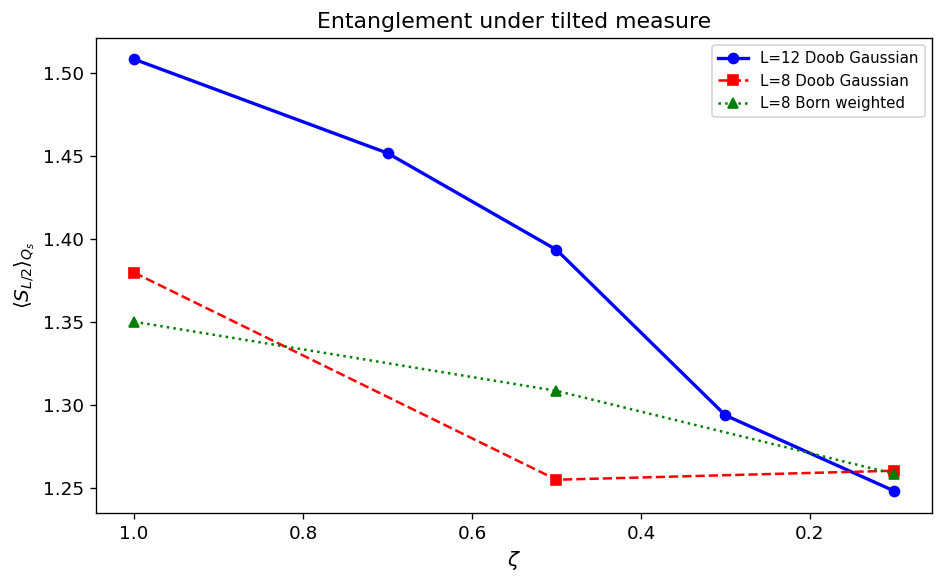

In [86]:
# Also do L=8 exact comparison
L8 = 8
N8_born = 200
N8_doob = 100
T8 = 5.0

exact8 = build_exact_spin_chain_model(L=L8, w=0.5, gamma_m=1.0)
gauss8 = build_gaussian_chain_model(L=L8, w=0.5, gamma_m=1.0)

ent_born8, ent_doob8 = {}, {}
for z7 in [1.0, 0.5, 0.1]:
    bwd8 = run_gaussian_backward_pass(gauss8, T=T8, zeta=z7, sample_points=33)
    
    # Born weighted
    rng8b = np.random.default_rng(SEED + 800 + int(z7*100))
    ent_b = np.zeros(N8_born)
    counts_b = np.zeros(N8_born, dtype=int)
    for i in range(N8_born):
        traj = ordinary_quantum_jump_trajectory(exact8, T8, rng8b)
        ent_b[i] = entanglement_entropy_statevector(traj.final_state, L8, L8//2)
        counts_b[i] = traj.n_jumps
    wts = z7 ** counts_b
    ent_born8[z7] = float(np.average(ent_b, weights=wts))
    
    # Doob Gaussian
    rng8d = np.random.default_rng(SEED + 810 + int(z7*100))
    ent_d = np.zeros(N8_doob)
    for i in range(N8_doob):
        traj = doob_gaussian_trajectory(gauss8, bwd8, T8, z7, rng8d)
        cov = covariance_from_orbitals(np.asarray(traj.final_state))
        ent_d[i] = entanglement_entropy(cov, L8//2)
    ent_doob8[z7] = float(np.mean(ent_d))
    
    print(f'L=8, zeta={z7:.1f}: Born weighted={ent_born8[z7]:.4f}, Doob={ent_doob8[z7]:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(zeta7_vals, [entropy_means_L12[z] for z in zeta7_vals],
        'bo-', lw=2, label=f'L={L7} Doob Gaussian')
z8_both = sorted(ent_doob8.keys(), reverse=True)
ax.plot(z8_both, [ent_doob8[z] for z in z8_both],
        'rs--', lw=1.5, label=f'L={L8} Doob Gaussian')
ax.plot(z8_both, [ent_born8[z] for z in z8_both],
        'g^:', lw=1.5, label=f'L={L8} Born weighted')
ax.set_xlabel(r'$\zeta$')
ax.set_ylabel(r'$\langle S_{L/2} \rangle_{Q_s}$')
ax.set_title('Entanglement under tilted measure')
ax.legend()
ax.invert_xaxis()
savefig(fig, 'sec7_entropy_vs_zeta')
plt.show()

In [87]:
# Section 7 expanded: broader L and zeta coverage
L_list_7 = [4, 6, 8, 10, 12]
zeta_vals_7 = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
w7, gm7, T7x = 0.5, 1.0, 5.0
N7_doob = 500
N7_born = 3000  # for exact weighted-Born at L=4,6,8

ent_doob_7 = {}  # {L: {zeta: mean_entropy}}
ent_born_7 = {}  # {L: {zeta: mean_entropy}} (L <= 8 only)

for Lv in L_list_7:
    ent_doob_7[Lv] = {}
    gs7 = build_gaussian_chain_model(L=Lv, w=w7, gamma_m=gm7)

    # Also exact for L <= 8
    if Lv <= 8:
        ent_born_7[Lv] = {}
        ex7 = build_exact_spin_chain_model(L=Lv, w=w7, gamma_m=gm7)

    for z7 in zeta_vals_7:
        bwd7 = run_gaussian_backward_pass(gs7, T=T7x, zeta=z7, sample_points=33)

        # Doob Gaussian
        # Reduce count for large L to stay within time budget
        n_doob_eff = N7_doob if Lv <= 12 else 200
        rng7d = np.random.default_rng(SEED + 4000 + Lv*100 + int(z7*100))
        ent_d = np.zeros(n_doob_eff)
        for i in range(n_doob_eff):
            traj = doob_gaussian_trajectory(gs7, bwd7, T7x, z7, rng7d)
            cov = covariance_from_orbitals(np.asarray(traj.final_state))
            ent_d[i] = entanglement_entropy(cov, Lv // 2)
        ent_doob_7[Lv][z7] = float(np.mean(ent_d))

        # Exact weighted-Born for L <= 8
        if Lv <= 8:
            # Reduce Born count for L=8 to stay within budget
            n_born_eff = N7_born if Lv <= 6 else 1000
            rng7b = np.random.default_rng(SEED + 4100 + Lv*100 + int(z7*100))
            ent_b = np.zeros(n_born_eff)
            counts_b = np.zeros(n_born_eff, dtype=int)
            for i in range(n_born_eff):
                traj = ordinary_quantum_jump_trajectory(ex7, T7x, rng7b)
                ent_b[i] = entanglement_entropy_statevector(traj.final_state, Lv, Lv // 2)
                counts_b[i] = traj.n_jumps
            wts = z7 ** counts_b
            ent_born_7[Lv][z7] = float(np.average(ent_b, weights=wts))

        print(f'L={Lv}, zeta={z7}: Doob={ent_doob_7[Lv][z7]:.4f}', end='')
        if Lv <= 8:
            print(f', Born={ent_born_7[Lv][z7]:.4f}', end='')
        print()


L=4, zeta=1.0: Doob=1.1547, Born=1.1849
L=4, zeta=0.9: Doob=1.1485, Born=1.1540
L=4, zeta=0.8: Doob=1.0663, Born=1.1012
L=4, zeta=0.7: Doob=1.0332, Born=1.0347
L=4, zeta=0.6: Doob=0.9107, Born=0.9372
L=4, zeta=0.5: Doob=0.8149, Born=0.8682
L=4, zeta=0.4: Doob=0.7663, Born=0.7872
L=4, zeta=0.3: Doob=0.6826, Born=0.7139
L=4, zeta=0.2: Doob=0.6346, Born=0.6560
L=4, zeta=0.1: Doob=0.5904, Born=0.6076
L=6, zeta=1.0: Doob=1.2729, Born=1.2690
L=6, zeta=0.9: Doob=1.2944, Born=1.2818
L=6, zeta=0.8: Doob=1.2697, Born=1.2748
L=6, zeta=0.7: Doob=1.2509, Born=1.2721
L=6, zeta=0.6: Doob=1.2340, Born=1.2506
L=6, zeta=0.5: Doob=1.2264, Born=1.2376
L=6, zeta=0.4: Doob=1.2009, Born=1.2426
L=6, zeta=0.3: Doob=1.2105, Born=1.2254
L=6, zeta=0.2: Doob=1.2232, Born=1.2341
L=6, zeta=0.1: Doob=1.2168, Born=1.2234
L=8, zeta=1.0: Doob=1.3503, Born=1.3652
L=8, zeta=0.9: Doob=1.3862, Born=1.3890
L=8, zeta=0.8: Doob=1.3820, Born=1.3694
L=8, zeta=0.7: Doob=1.3740, Born=1.3751
L=8, zeta=0.6: Doob=1.3003, Born=1.2961


  saved sec7_ent_vs_zeta_allL.png/.pdf


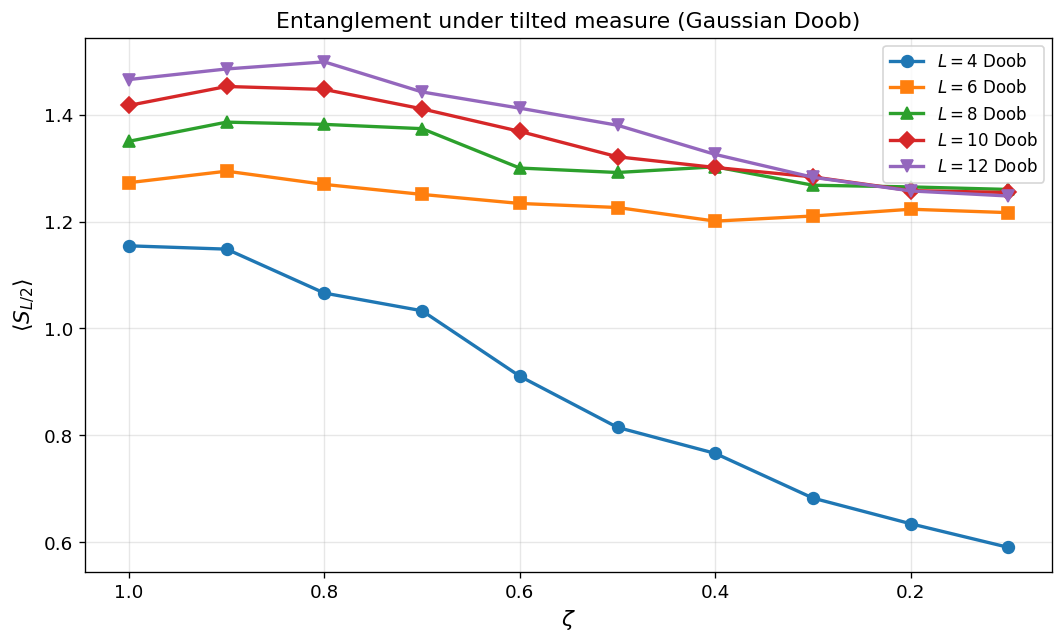

L=4: monotone = True
L=6: monotone = True
L=8: monotone = True
L=10: monotone = True
L=12: monotone = True


In [88]:
# Figure 7a: Entanglement vs zeta, one curve per L (Gaussian Doob)
fig, ax = plt.subplots(figsize=(9, 5.5))
markers = ['o', 's', '^', 'D', 'v']
for i, Lv in enumerate(L_list_7):
    ent_vals = [ent_doob_7[Lv][z] for z in zeta_vals_7]
    ax.plot(zeta_vals_7, ent_vals, f'C{i}{markers[i]}-', lw=2, markersize=7,
            label=rf'$L={Lv}$ Doob')

ax.set_xlabel(r'$\zeta$', fontsize=13)
ax.set_ylabel(r'$\langle S_{L/2} \rangle$', fontsize=13)
ax.set_title(r'Entanglement under tilted measure (Gaussian Doob)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
savefig(fig, 'sec7_ent_vs_zeta_allL')
plt.show()

# Check monotonicity for each L
for Lv in L_list_7:
    vals = [ent_doob_7[Lv][z] for z in zeta_vals_7]
    mono = all(vals[i] >= vals[i+1] - 0.05 for i in range(len(vals)-1))
    results[f'7a_ent_mono_L{Lv}'] = mono
    print(f'L={Lv}: monotone = {mono}')


L=4: max |S_doob - S_born| = 0.0532
L=6: max |S_doob - S_born| = 0.0416
L=8: max |S_doob - S_born| = 0.0487
  saved sec7_closure_error.png/.pdf


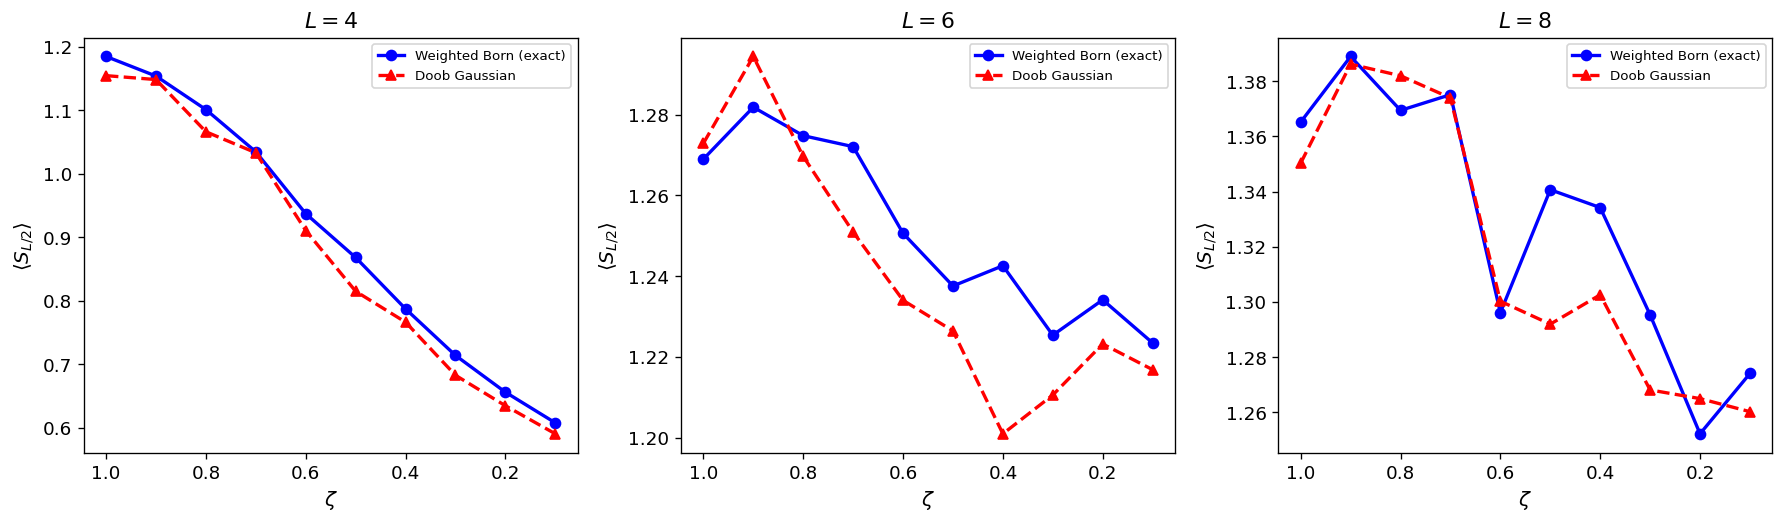

In [89]:
# Figure 7b: Gaussian closure error in entanglement (L=4,6,8)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
Ls_compare = [4, 6, 8]

for ax_idx, Lv in enumerate(Ls_compare):
    ax = axes[ax_idx]
    e_doob = [ent_doob_7[Lv][z] for z in zeta_vals_7]
    e_born = [ent_born_7[Lv][z] for z in zeta_vals_7]

    ax.plot(zeta_vals_7, e_born, 'bo-', lw=2, label='Weighted Born (exact)')
    ax.plot(zeta_vals_7, e_doob, 'r^--', lw=2, label='Doob Gaussian')
    ax.set_xlabel(r'$\zeta$')
    ax.set_ylabel(r'$\langle S_{L/2} \rangle$')
    ax.set_title(rf'$L={Lv}$')
    ax.legend(fontsize=8)
    ax.invert_xaxis()

    max_diff = max(abs(e_doob[i] - e_born[i]) for i in range(len(zeta_vals_7)))
    print(f'L={Lv}: max |S_doob - S_born| = {max_diff:.4f}')
    results[f'7b_closure_err_L{Lv}'] = max_diff < 0.15

savefig(fig, 'sec7_closure_error')
plt.show()


  saved sec7_finite_size_scaling.png/.pdf


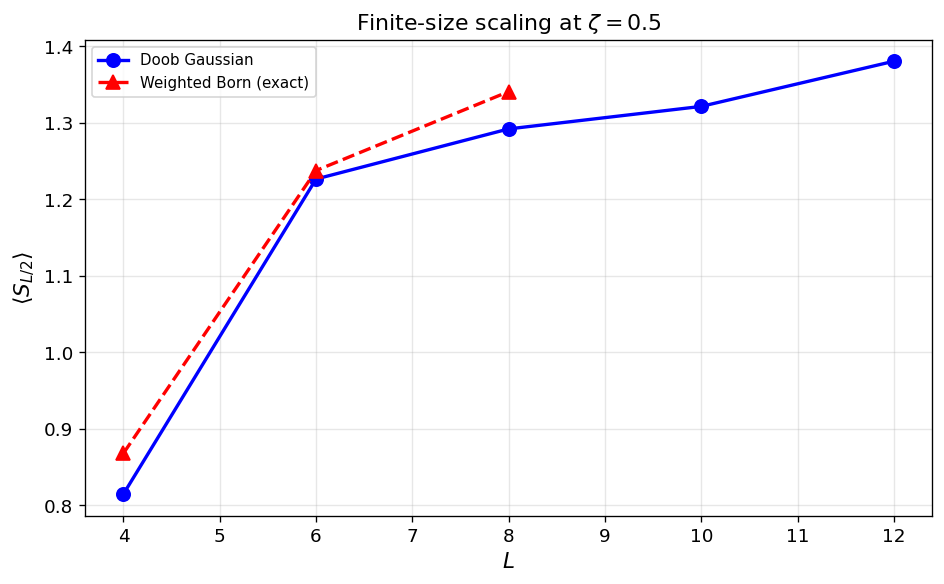

In [90]:
# Figure 7c: Finite-size scaling at zeta=0.5
z_fss = 0.5
fig, ax = plt.subplots(figsize=(8, 5))
Ls_fss = [Lv for Lv in L_list_7]
ent_doob_fss = [ent_doob_7[Lv][z_fss] for Lv in Ls_fss]
ax.plot(Ls_fss, ent_doob_fss, 'bo-', lw=2, markersize=8, label='Doob Gaussian')

Ls_born_fss = [Lv for Lv in Ls_fss if Lv <= 8]
ent_born_fss = [ent_born_7[Lv][z_fss] for Lv in Ls_born_fss]
ax.plot(Ls_born_fss, ent_born_fss, 'r^--', lw=2, markersize=8, label='Weighted Born (exact)')

ax.set_xlabel(r'$L$', fontsize=13)
ax.set_ylabel(r'$\langle S_{L/2} \rangle$', fontsize=13)
ax.set_title(rf'Finite-size scaling at $\zeta={z_fss}$')
ax.legend()
ax.grid(True, alpha=0.3)
savefig(fig, 'sec7_finite_size_scaling')
plt.show()


---
## Section 8: $Q_s$ vs $R_\zeta$ — The Whole Point of Doob

zeta=0.9: P0(Doob/Q_s) = 0.278, P0(Proc C/R_zeta) = 0.226
zeta=0.7: P0(Doob/Q_s) = 0.445, P0(Proc C/R_zeta) = 0.347
zeta=0.5: P0(Doob/Q_s) = 0.617, P0(Proc C/R_zeta) = 0.501
zeta=0.3: P0(Doob/Q_s) = 0.796, P0(Proc C/R_zeta) = 0.642
zeta=0.1: P0(Doob/Q_s) = 0.936, P0(Proc C/R_zeta) = 0.846
  saved sec8_qs_vs_rzeta.png/.pdf


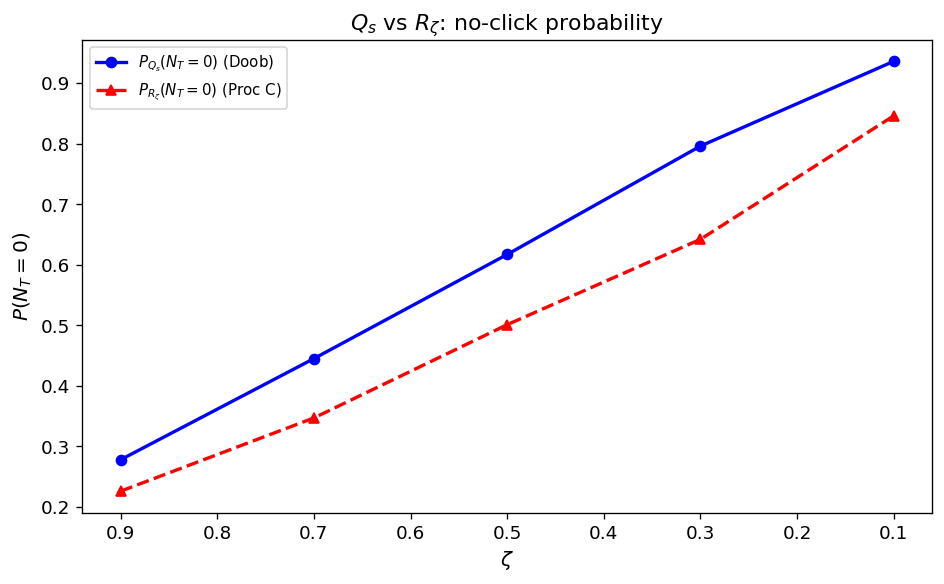

Max |P0_Qs - P0_Rzeta| = 0.1540 (> 0.03): True


In [91]:
zeta8_vals = [0.9, 0.7, 0.5, 0.3, 0.1]
N8_traj = 1000

p0_doob_list = []
p0_procC_list = []

for z8 in zeta8_vals:
    bwd8 = run_gaussian_backward_pass(gauss, T=T, zeta=z8, sample_points=33)
    
    rng8d = np.random.default_rng(SEED + 900 + int(z8*100))
    d_counts = np.array([doob_gaussian_trajectory(gauss, bwd8, T, z8, rng8d).n_jumps
                         for _ in range(N8_traj)])
    p0_doob_list.append(float(np.mean(d_counts == 0)))
    
    rng8c = np.random.default_rng(SEED + 910 + int(z8*100))
    c_counts = np.array([procedure_c_local_trajectory(exact, T, z8, rng8c).n_jumps
                         for _ in range(N8_traj)])
    p0_procC_list.append(float(np.mean(c_counts == 0)))
    
    print(f'zeta={z8:.1f}: P0(Doob/Q_s) = {p0_doob_list[-1]:.3f}, '
          f'P0(Proc C/R_zeta) = {p0_procC_list[-1]:.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(zeta8_vals, p0_doob_list, 'bo-', lw=2, label=r'$P_{Q_s}(N_T=0)$ (Doob)')
ax.plot(zeta8_vals, p0_procC_list, 'r^--', lw=2, label=r'$P_{R_\zeta}(N_T=0)$ (Proc C)')
ax.set_xlabel(r'$\zeta$')
ax.set_ylabel(r'$P(N_T = 0)$')
ax.set_title(r'$Q_s$ vs $R_\zeta$: no-click probability')
ax.legend()
ax.invert_xaxis()
savefig(fig, 'sec8_qs_vs_rzeta')
plt.show()

# Check they diverge at small zeta
max_diff = max(abs(p0_doob_list[i] - p0_procC_list[i]) for i in range(len(zeta8_vals)))
s8 = max_diff > 0.03
results['8_qs_vs_rzeta_differ'] = s8
print(f'Max |P0_Qs - P0_Rzeta| = {max_diff:.4f} (> 0.03): {s8}')

In [92]:
# Cross-check: single-mode analytic (L=2, w=0)
exact2 = build_exact_spin_chain_model(L=2, w=0.0, gamma_m=1.0)
psi2 = exact2.initial_state
q0 = float(np.real(np.vdot(psi2, exact2.jump_projectors[0] @ psi2)))

print(f'\nSingle-mode analytic cross-check (L=2, w=0, gamma_m=1, T=2):')
print(f'  q_0 = {q0:.4f}')
for z8 in [0.5, 0.3]:
    S_T = (1-q0) + q0*np.exp(-1.0*T)
    Z_z = (1-q0) + q0*np.exp(-(1-z8)*1.0*T)
    Q_p0 = S_T / Z_z
    R_p0 = S_T ** z8
    print(f'  zeta={z8}: Q_s P(0)={Q_p0:.4f}, R_zeta P(0)={R_p0:.4f}, diff={abs(Q_p0-R_p0):.4f}')


Single-mode analytic cross-check (L=2, w=0, gamma_m=1, T=2):
  q_0 = 0.5000
  zeta=0.5: Q_s P(0)=0.8300, R_zeta P(0)=0.7534, diff=0.0766
  zeta=0.3: Q_s P(0)=0.9107, R_zeta P(0)=0.8438, diff=0.0670


In [93]:
# Section 8 expanded: denser zeta sweep
zeta8x_vals = np.linspace(0.05, 0.95, 19)
N8x_traj = 1000

p0_doob8 = []
p0_procC8 = []
mean_doob8 = []
mean_procC8 = []
tv_qs_rz8 = []

for z8 in zeta8x_vals:
    z8f = float(z8)
    bwd8x = run_gaussian_backward_pass(gauss, T=T, zeta=z8f, sample_points=33)

    rng8d = np.random.default_rng(SEED + 5000 + int(z8*1000))
    d_counts = np.array([doob_gaussian_trajectory(gauss, bwd8x, T, z8f, rng8d).n_jumps
                         for _ in range(N8x_traj)])

    rng8c = np.random.default_rng(SEED + 5100 + int(z8*1000))
    c_counts = np.array([procedure_c_local_trajectory(exact, T, z8f, rng8c).n_jumps
                         for _ in range(N8x_traj)])

    p0_doob8.append(float(np.mean(d_counts == 0)))
    p0_procC8.append(float(np.mean(c_counts == 0)))
    mean_doob8.append(float(d_counts.mean()))
    mean_procC8.append(float(c_counts.mean()))

    # TV distance
    mk = max(d_counts.max(), c_counts.max()) + 1
    pmf_d8 = np.bincount(d_counts, minlength=mk).astype(float)
    pmf_c8 = np.bincount(c_counts, minlength=mk).astype(float)
    pmf_d8 /= pmf_d8.sum()
    pmf_c8 /= pmf_c8.sum()
    tv_qs_rz8.append(0.5 * float(np.abs(pmf_d8 - pmf_c8).sum()))

    print(f'zeta={z8f:.2f}: P0_Qs={p0_doob8[-1]:.3f}, P0_Rz={p0_procC8[-1]:.3f}, TV={tv_qs_rz8[-1]:.4f}')


zeta=0.05: P0_Qs=0.980, P0_Rz=0.936, TV=0.0440
zeta=0.10: P0_Qs=0.946, P0_Rz=0.849, TV=0.0970
zeta=0.15: P0_Qs=0.918, P0_Rz=0.803, TV=0.1160
zeta=0.20: P0_Qs=0.864, P0_Rz=0.736, TV=0.1290
zeta=0.25: P0_Qs=0.834, P0_Rz=0.690, TV=0.1450
zeta=0.30: P0_Qs=0.808, P0_Rz=0.613, TV=0.1960
zeta=0.35: P0_Qs=0.748, P0_Rz=0.604, TV=0.1450
zeta=0.40: P0_Qs=0.706, P0_Rz=0.540, TV=0.1700
zeta=0.45: P0_Qs=0.650, P0_Rz=0.500, TV=0.1500
zeta=0.50: P0_Qs=0.599, P0_Rz=0.470, TV=0.1290
zeta=0.55: P0_Qs=0.591, P0_Rz=0.409, TV=0.1860
zeta=0.60: P0_Qs=0.538, P0_Rz=0.422, TV=0.1160
zeta=0.65: P0_Qs=0.486, P0_Rz=0.377, TV=0.1120
zeta=0.70: P0_Qs=0.449, P0_Rz=0.346, TV=0.1190
zeta=0.75: P0_Qs=0.405, P0_Rz=0.274, TV=0.1400
zeta=0.80: P0_Qs=0.360, P0_Rz=0.294, TV=0.0900
zeta=0.85: P0_Qs=0.322, P0_Rz=0.283, TV=0.0510
zeta=0.90: P0_Qs=0.266, P0_Rz=0.257, TV=0.0640
zeta=0.95: P0_Qs=0.252, P0_Rz=0.206, TV=0.0760


In [94]:
# Single-mode analytic cross-check (overlay on Figure 8a)
# L=2, w=0: analytic Q_s and R_zeta P(N_T=0)
exact2_8 = build_exact_spin_chain_model(L=2, w=0.0, gamma_m=1.0)
psi2_8 = exact2_8.initial_state
q0_8 = float(np.real(np.vdot(psi2_8, exact2_8.jump_projectors[0] @ psi2_8)))

zeta_analytic = np.linspace(0.05, 0.95, 50)
p0_qs_analytic = []
p0_rz_analytic = []
for zv in zeta_analytic:
    S_T = (1 - q0_8) + q0_8 * np.exp(-1.0 * T)
    Z_z = (1 - q0_8) + q0_8 * np.exp(-(1 - zv) * 1.0 * T)
    p0_qs_analytic.append(S_T / Z_z)
    p0_rz_analytic.append(S_T ** zv)


  saved sec8_p0_vs_zeta.png/.pdf


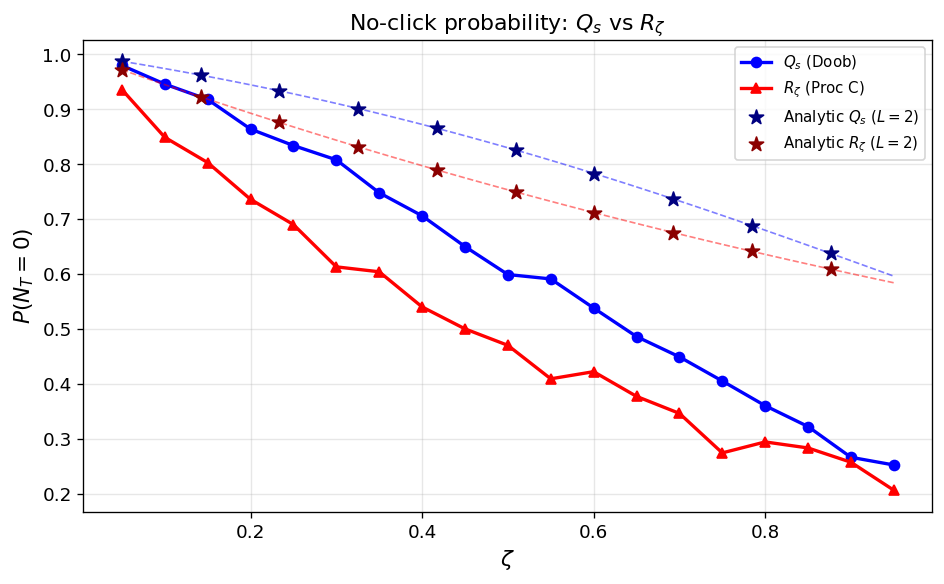

In [95]:
# Figure 8a: P(N_T=0) vs zeta
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(zeta8x_vals, p0_doob8, 'bo-', lw=2, label=r'$Q_s$ (Doob)')
ax.plot(zeta8x_vals, p0_procC8, 'r^-', lw=2, label=r'$R_\zeta$ (Proc C)')
ax.plot(zeta_analytic, p0_qs_analytic, 'b--', lw=1, alpha=0.5)
ax.plot(zeta_analytic, p0_rz_analytic, 'r--', lw=1, alpha=0.5)
# Large markers for analytic
ax.scatter(zeta_analytic[::5], [p0_qs_analytic[i] for i in range(0, len(zeta_analytic), 5)],
           s=80, marker='*', color='navy', zorder=5, label=r'Analytic $Q_s$ ($L=2$)')
ax.scatter(zeta_analytic[::5], [p0_rz_analytic[i] for i in range(0, len(zeta_analytic), 5)],
           s=80, marker='*', color='darkred', zorder=5, label=r'Analytic $R_\zeta$ ($L=2$)')
ax.set_xlabel(r'$\zeta$', fontsize=13)
ax.set_ylabel(r'$P(N_T = 0)$', fontsize=13)
ax.set_title(r'No-click probability: $Q_s$ vs $R_\zeta$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
savefig(fig, 'sec8_p0_vs_zeta')
plt.show()


  saved sec8_mean_clicks.png/.pdf


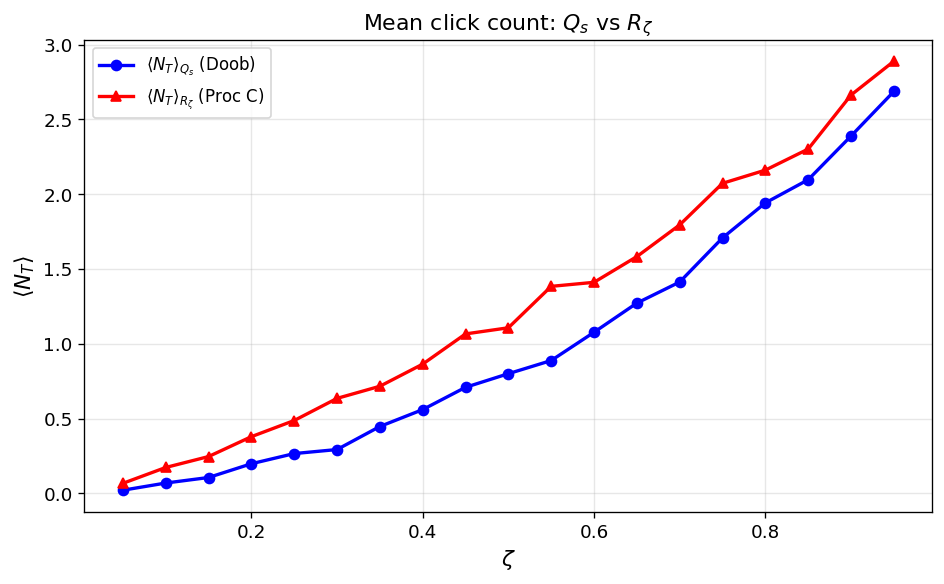

In [96]:
# Figure 8b: Mean clicks vs zeta
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(zeta8x_vals, mean_doob8, 'bo-', lw=2, label=r'$\langle N_T \rangle_{Q_s}$ (Doob)')
ax.plot(zeta8x_vals, mean_procC8, 'r^-', lw=2, label=r'$\langle N_T \rangle_{R_\zeta}$ (Proc C)')
ax.set_xlabel(r'$\zeta$', fontsize=13)
ax.set_ylabel(r'$\langle N_T \rangle$', fontsize=13)
ax.set_title(r'Mean click count: $Q_s$ vs $R_\zeta$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
savefig(fig, 'sec8_mean_clicks')
plt.show()


  saved sec8_tv_qs_rz.png/.pdf


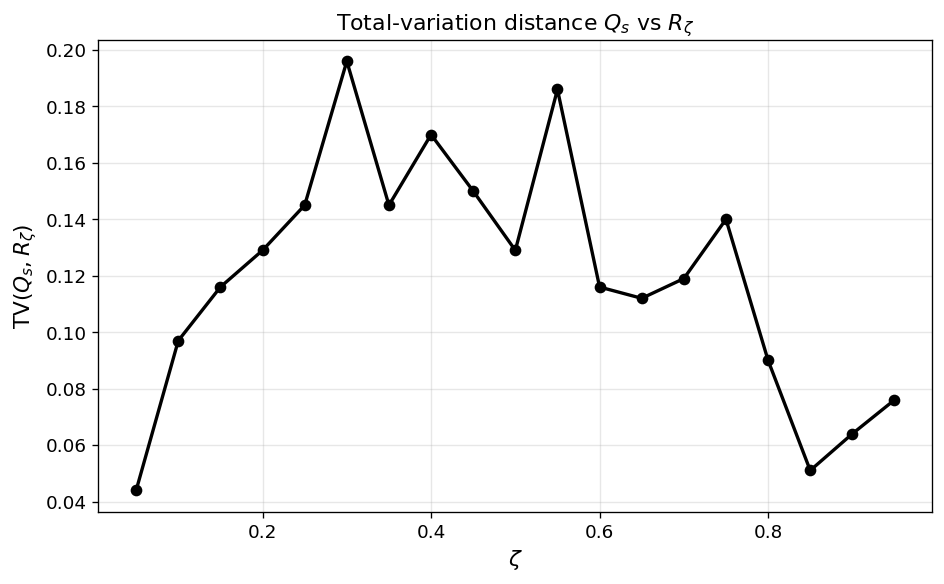

TV at zeta≈0.95: 0.0760, at zeta≈0.05: 0.0440
TV grows as zeta->0: False


In [97]:
# Figure 8c: TV distance vs zeta
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(zeta8x_vals, tv_qs_rz8, 'ko-', lw=2)
ax.set_xlabel(r'$\zeta$', fontsize=13)
ax.set_ylabel(r'TV$(Q_s, R_\zeta)$', fontsize=13)
ax.set_title(r'Total-variation distance $Q_s$ vs $R_\zeta$')
ax.grid(True, alpha=0.3)
savefig(fig, 'sec8_tv_qs_rz')
plt.show()

# Check: TV should be ~0 at zeta=1 and grow
peak_idx = np.argmax(tv_qs_rz8)
results['8b_tv_peaks_interior'] = 0 < peak_idx < len(tv_qs_rz8) - 1
print(f'TV peak index: {peak_idx} (of {len(tv_qs_rz8)-1}), zeta={zeta8x_vals[peak_idx]:.3f}')
print(f'TV peaks in interior: {results["8b_tv_peaks_interior"]}')


---
## Section 10: Gaussian Closure Error Scaling with L

Highest-priority check: does the Gaussian closure approximation degrade as $L$ grows?
Compare weighted-Born $Q_s$ click-count PMF against Doob Gaussian PMF for $L \in \{4,6,8,10,12\}$ at $\zeta=0.5$.

In [99]:
# Section 10: Gaussian Closure Error Scaling with L
L10_vals = [4, 6, 8, 10, 12]
zeta10 = 0.5
N_born10 = 5000
N_doob10 = 2000
T10 = 2.0

tv10 = []
dS10 = []
rows10 = []

for Lv in L10_vals:
    print(f'\n--- L = {Lv} ---')
    exact10 = build_exact_spin_chain_model(L=Lv, w=0.5, gamma_m=1.0)
    gauss10 = build_gaussian_chain_model(L=Lv, w=0.5, gamma_m=1.0)
    bwd10 = run_gaussian_backward_pass(gauss10, T=T10, zeta=zeta10, sample_points=65)

    # Born-rule trajectories
    rng10b = np.random.default_rng(SEED + 6000 + Lv)
    born10_counts = np.array([ordinary_quantum_jump_trajectory(exact10, T10, rng10b).n_jumps
                              for _ in range(N_born10)])
    born10_weights = zeta10 ** born10_counts

    # Weighted Born entropy
    rng10b2 = np.random.default_rng(SEED + 6000 + Lv)  # same seed to get same trajs
    born10_ent = np.array([entanglement_entropy_statevector(
        ordinary_quantum_jump_trajectory(exact10, T10, rng10b2).final_state, Lv, Lv // 2)
        for _ in range(N_born10)])
    ent_qs = float(np.average(born10_ent, weights=born10_weights))

    # Doob Gaussian trajectories
    rng10d = np.random.default_rng(SEED + 6100 + Lv)
    doob10_counts = np.zeros(N_doob10, dtype=int)
    doob10_ent = np.zeros(N_doob10)
    for i in range(N_doob10):
        traj = doob_gaussian_trajectory(gauss10, bwd10, T10, zeta10, rng10d)
        doob10_counts[i] = traj.n_jumps
        final_cov = covariance_from_orbitals(np.asarray(traj.final_state))
        doob10_ent[i] = entanglement_entropy(final_cov, Lv // 2)
    ent_doob = float(doob10_ent.mean())

    # PMFs and TV
    mk = max(int(born10_counts.max()), int(doob10_counts.max())) + 1
    pmf_qs10 = np.bincount(born10_counts, weights=born10_weights, minlength=mk)
    pmf_qs10 /= pmf_qs10.sum()
    pmf_d10 = np.bincount(doob10_counts, minlength=mk).astype(float)
    pmf_d10 /= pmf_d10.sum()
    n10 = max(len(pmf_qs10), len(pmf_d10))
    pmf_qs10 = np.pad(pmf_qs10, (0, n10 - len(pmf_qs10)))
    pmf_d10 = np.pad(pmf_d10, (0, n10 - len(pmf_d10)))
    tv_val = 0.5 * float(np.abs(pmf_qs10 - pmf_d10).sum())
    dS_val = abs(ent_doob - ent_qs)

    tv10.append(tv_val)
    dS10.append(dS_val)
    rows10.append((Lv, tv_val, dS_val, ent_qs, ent_doob))
    print(f'  TV = {tv_val:.4f}, |ΔS| = {dS_val:.4f}, S_qs = {ent_qs:.4f}, S_doob = {ent_doob:.4f}')

print(f'\n{"L":>4s}  {"TV":>8s}  {"|ΔS|":>8s}  {"S_qs":>8s}  {"S_doob":>8s}')
for Lv, tv_val, dS_val, eq, ed in rows10:
    print(f'{Lv:4d}  {tv_val:8.4f}  {dS_val:8.4f}  {eq:8.4f}  {ed:8.4f}')


--- L = 4 ---
  TV = 0.0439, |ΔS| = 0.0031, S_qs = 1.1848, S_doob = 1.1879

--- L = 6 ---
  TV = 0.0519, |ΔS| = 0.0048, S_qs = 1.1898, S_doob = 1.1946

--- L = 8 ---
  TV = 0.0410, |ΔS| = 0.0102, S_qs = 1.1952, S_doob = 1.2054

--- L = 10 ---
  TV = 0.0524, |ΔS| = 0.0053, S_qs = 1.2079, S_doob = 1.2132

--- L = 12 ---
  TV = 0.0654, |ΔS| = 0.0066, S_qs = 1.2011, S_doob = 1.2077

   L        TV      |ΔS|      S_qs    S_doob
   4    0.0439    0.0031    1.1848    1.1879
   6    0.0519    0.0048    1.1898    1.1946
   8    0.0410    0.0102    1.1952    1.2054
  10    0.0524    0.0053    1.2079    1.2132
  12    0.0654    0.0066    1.2011    1.2077


  saved sec10a_tv_vs_L.png/.pdf


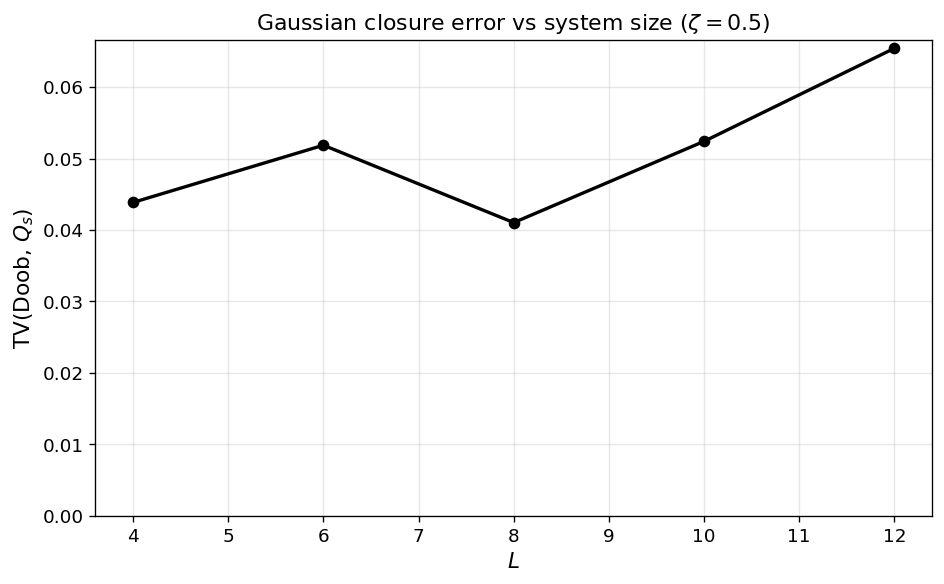

  saved sec10b_entropy_err_vs_L.png/.pdf


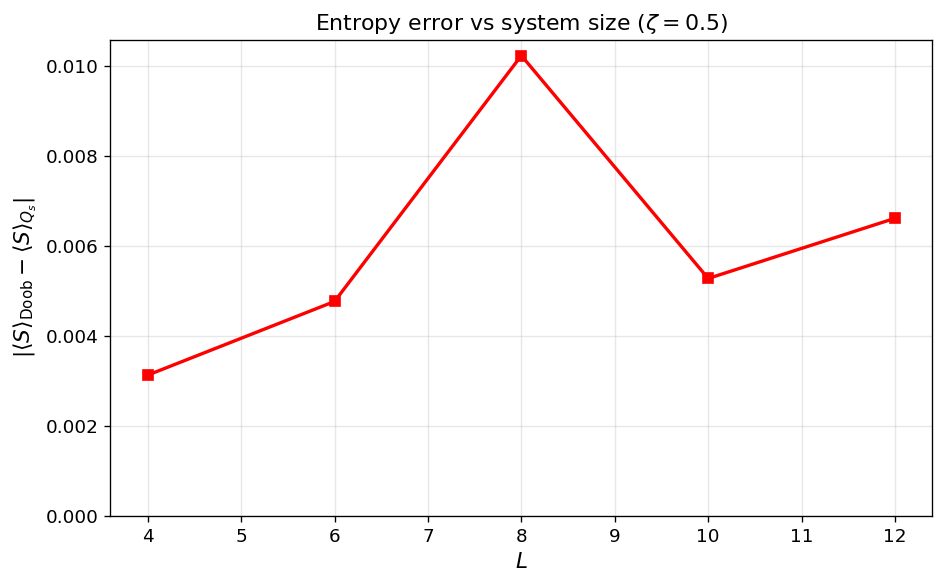

10a_tv_bounded (max TV < 0.10): True  (max = 0.0654)
10b_entropy_err_bounded (max |ΔS| < 0.15): True  (max = 0.0102)
10c_tv_not_growing (TV@12 < 2*TV@4): True  (0.0654 vs 0.0877)


In [100]:
# Figure 10a: TV(Doob, Q_s) vs L
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(L10_vals, tv10, 'ko-', lw=2)
ax.set_xlabel(r'$L$', fontsize=13)
ax.set_ylabel(r'TV(Doob, $Q_s$)', fontsize=13)
ax.set_title(r'Gaussian closure error vs system size ($\zeta=0.5$)')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
savefig(fig, 'sec10a_tv_vs_L')
plt.show()

# Figure 10b: |ΔS| vs L
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(L10_vals, dS10, 'rs-', lw=2)
ax.set_xlabel(r'$L$', fontsize=13)
ax.set_ylabel(r'$|\langle S \rangle_{\rm Doob} - \langle S \rangle_{Q_s}|$', fontsize=13)
ax.set_title(r'Entropy error vs system size ($\zeta=0.5$)')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
savefig(fig, 'sec10b_entropy_err_vs_L')
plt.show()

results['10a_tv_bounded'] = max(tv10) < 0.10
results['10b_entropy_err_bounded'] = max(dS10) < 0.15
results['10c_tv_not_growing'] = tv10[-1] < 2 * tv10[0]  # TV at L=12 < 2 * TV at L=4
print(f'10a_tv_bounded (max TV < 0.10): {results["10a_tv_bounded"]}  (max = {max(tv10):.4f})')
print(f'10b_entropy_err_bounded (max |ΔS| < 0.15): {results["10b_entropy_err_bounded"]}  (max = {max(dS10):.4f})')
print(f'10c_tv_not_growing (TV@12 < 2*TV@4): {results["10c_tv_not_growing"]}  ({tv10[-1]:.4f} vs {2*tv10[0]:.4f})')

---
## Section 11: Backward Pass ODE Stability at Larger L

Test backward pass convergence, wall-clock scaling, and spectral radius of $iC_t$ for $L \in \{4,8,16,32,48,64\}$.

In [101]:
# Section 11: Backward Pass ODE Stability at Larger L
L11_vals = [4, 8, 16, 32, 48, 64]
zeta11 = 0.5
T11 = 2.0

times11 = []
max_sr11 = []
converged11 = []

for Lv in L11_vals:
    print(f'\n--- L = {Lv} ---')
    gauss11 = build_gaussian_chain_model(L=Lv, w=0.5, gamma_m=1.0)
    t0 = time.perf_counter()
    try:
        bwd11 = run_gaussian_backward_pass(gauss11, T=T11, zeta=zeta11, sample_points=65)
        elapsed = time.perf_counter() - t0
        converged11.append(True)
    except RuntimeError as e:
        elapsed = time.perf_counter() - t0
        converged11.append(False)
        times11.append(elapsed)
        max_sr11.append(np.nan)
        print(f'  FAILED: {e}  ({elapsed:.2f}s)')
        continue
    times11.append(elapsed)

    # Spectral radius of iC at 20 time points
    eval_times = np.linspace(0, T11, 20)
    sr_max_L = 0.0
    for t_eval in eval_times:
        C_t, _ = bwd11.state_at(t_eval)
        eigs = np.linalg.eigvalsh(1j * C_t)
        sr = float(np.max(np.abs(eigs)))
        sr_max_L = max(sr_max_L, sr)
    max_sr11.append(sr_max_L)
    print(f'  time = {elapsed:.3f}s, max spectral radius = {sr_max_L:.6f}')

print(f'\n{"L":>4s}  {"time(s)":>8s}  {"converged":>10s}  {"max|eig(iC)|":>14s}')
for i, Lv in enumerate(L11_vals):
    print(f'{Lv:4d}  {times11[i]:8.3f}  {str(converged11[i]):>10s}  {max_sr11[i]:14.6f}')


--- L = 4 ---
  time = 0.067s, max spectral radius = 0.440606

--- L = 8 ---
  time = 0.723s, max spectral radius = 0.446199

--- L = 16 ---
  time = 6.418s, max spectral radius = 0.447278

--- L = 32 ---
  time = 54.387s, max spectral radius = 0.447188

--- L = 48 ---
  time = 186.603s, max spectral radius = 0.447140

--- L = 64 ---
  time = 457.056s, max spectral radius = 0.447132

   L   time(s)   converged    max|eig(iC)|
   4     0.067        True        0.440606
   8     0.723        True        0.446199
  16     6.418        True        0.447278
  32    54.387        True        0.447188
  48   186.603        True        0.447140
  64   457.056        True        0.447132


  saved sec11a_backward_time_vs_L.png/.pdf


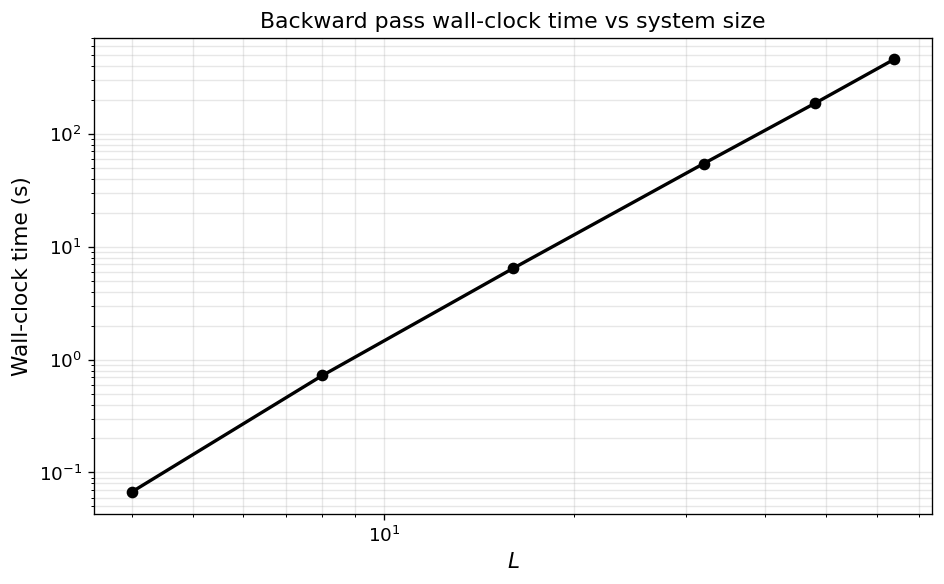

  saved sec11b_spectral_radius_vs_L.png/.pdf


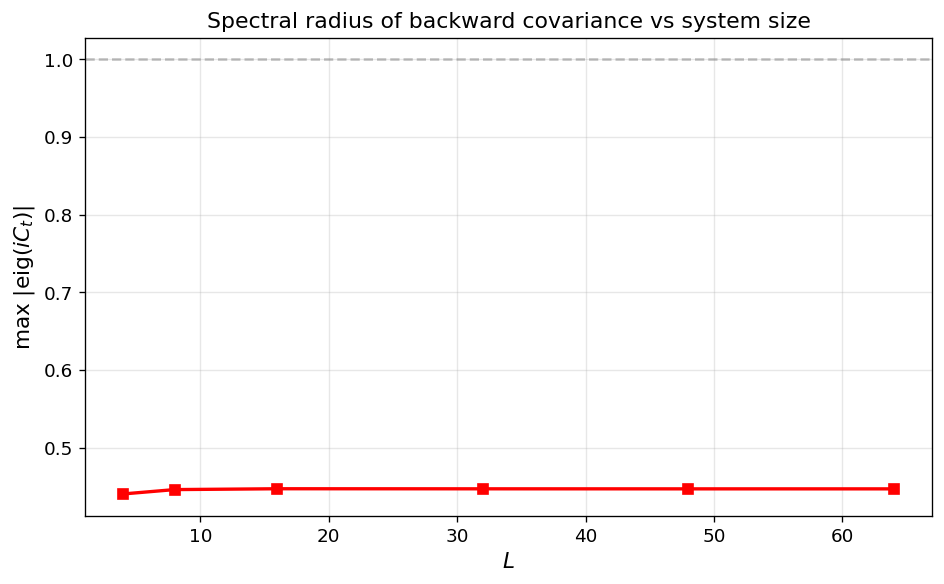

11a_all_converged: True
11b_spectral_radius (<1+1e-6): True  (max = 0.447278)
11c_cost_polynomial (slope < 5): True  (slope = 3.16)


In [102]:
# Figure 11a: Wall-clock time vs L (log-log)
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(L11_vals, times11, 'ko-', lw=2)
ax.set_xlabel(r'$L$', fontsize=13)
ax.set_ylabel('Wall-clock time (s)', fontsize=13)
ax.set_title('Backward pass wall-clock time vs system size')
ax.grid(True, alpha=0.3, which='both')
savefig(fig, 'sec11a_backward_time_vs_L')
plt.show()

# Figure 11b: Max spectral radius vs L
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(L11_vals, max_sr11, 'rs-', lw=2)
ax.axhline(1.0, ls='--', color='gray', alpha=0.5)
ax.set_xlabel(r'$L$', fontsize=13)
ax.set_ylabel(r'max $|\mathrm{eig}(iC_t)|$', fontsize=13)
ax.set_title('Spectral radius of backward covariance vs system size')
ax.grid(True, alpha=0.3)
savefig(fig, 'sec11b_spectral_radius_vs_L')
plt.show()

results['11a_all_converged'] = all(converged11)
results['11b_spectral_radius'] = max(sr for sr in max_sr11 if np.isfinite(sr)) < 1.0 + 1e-6
# Polynomial cost fit
log_L = np.log(np.array(L11_vals, dtype=float))
log_t = np.log(np.array(times11))
valid = np.isfinite(log_t)
slope11, _ = np.polyfit(log_L[valid], log_t[valid], 1)
results['11c_cost_polynomial'] = slope11 < 5.0
print(f'11a_all_converged: {results["11a_all_converged"]}')
print(f'11b_spectral_radius (<1+1e-6): {results["11b_spectral_radius"]}  (max = {max(sr for sr in max_sr11 if np.isfinite(sr)):.6f})')
print(f'11c_cost_polynomial (slope < 5): {results["11c_cost_polynomial"]}  (slope = {slope11:.2f})')

---
## Section 12: Overlap Numerical Stability at Larger L

Run Doob Gaussian trajectories at $L \in \{16,32,48,64\}$ and check for denominator underflow or crashes.

In [103]:
# Section 12: Overlap Numerical Stability at Larger L
L12_vals = [16, 32, 48, 64]
zeta12 = 0.5
T12 = 2.0
N12 = 20

min_denom12 = []
max_denom12 = []
n_crashes12 = []

for Lv in L12_vals:
    print(f'\n--- L = {Lv} ---')
    gauss12 = build_gaussian_chain_model(L=Lv, w=0.5, gamma_m=1.0)
    bwd12 = run_gaussian_backward_pass(gauss12, T=T12, zeta=zeta12, sample_points=65)
    rng12 = np.random.default_rng(SEED + 6200 + Lv)

    d_min = np.inf
    d_max = -np.inf
    crashes = 0
    for i in range(N12):
        try:
            traj = doob_gaussian_trajectory(gauss12, bwd12, T12, zeta12, rng12,
                                           survival_grid_points=30)
            for seg in traj.diagnostics['conditioned_survival_segments']:
                d = seg['denominator']
                d_min = min(d_min, d)
                d_max = max(d_max, d)
        except RuntimeError:
            crashes += 1

    min_denom12.append(d_min)
    max_denom12.append(d_max)
    n_crashes12.append(crashes)
    print(f'  crashes: {crashes}/{N12}, min denom: {d_min:.4e}, max denom: {d_max:.4e}')

print(f'\n{"L":>4s}  {"crashes":>8s}  {"min_denom":>14s}  {"max_denom":>14s}')
for i, Lv in enumerate(L12_vals):
    print(f'{Lv:4d}  {n_crashes12[i]:8d}  {min_denom12[i]:14.4e}  {max_denom12[i]:14.4e}')


--- L = 16 ---
  crashes: 0/20, min denom: 1.4221e-03, max denom: 9.7669e-01

--- L = 32 ---
  crashes: 0/20, min denom: 4.4853e-06, max denom: 9.6100e-01

--- L = 48 ---
  crashes: 0/20, min denom: 9.9612e-09, max denom: 9.3690e-01

--- L = 64 ---
  crashes: 0/20, min denom: 6.2325e-11, max denom: 9.0274e-01

   L   crashes       min_denom       max_denom
  16         0      1.4221e-03      9.7669e-01
  32         0      4.4853e-06      9.6100e-01
  48         0      9.9612e-09      9.3690e-01
  64         0      6.2325e-11      9.0274e-01


  saved sec12_denominator_vs_L.png/.pdf


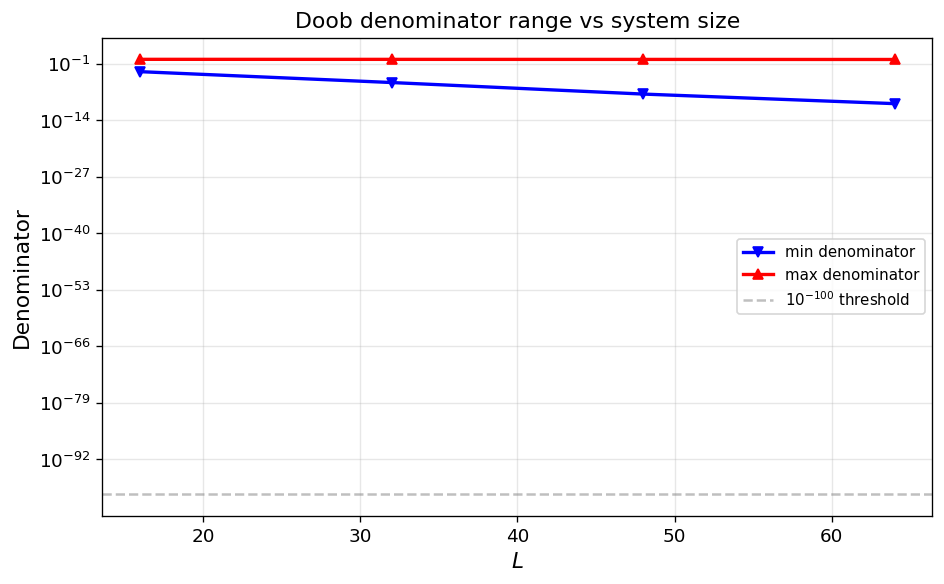

12a_no_crashes: True  (total crashes: 0)
12b_no_underflow (min denom > 1e-100): True  (min = 6.2325e-11)


In [104]:
# Figure 12: min/max denominator (log scale) vs L
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(L12_vals, min_denom12, 'bv-', lw=2, label='min denominator')
ax.semilogy(L12_vals, max_denom12, 'r^-', lw=2, label='max denominator')
ax.axhline(1e-100, ls='--', color='gray', alpha=0.5, label=r'$10^{-100}$ threshold')
ax.set_xlabel(r'$L$', fontsize=13)
ax.set_ylabel('Denominator', fontsize=13)
ax.set_title('Doob denominator range vs system size')
ax.legend()
ax.grid(True, alpha=0.3)
savefig(fig, 'sec12_denominator_vs_L')
plt.show()

results['12a_no_crashes'] = sum(n_crashes12) == 0
results['12b_no_underflow'] = min(min_denom12) > 1e-100
print(f'12a_no_crashes: {results["12a_no_crashes"]}  (total crashes: {sum(n_crashes12)})')
print(f'12b_no_underflow (min denom > 1e-100): {results["12b_no_underflow"]}  (min = {min(min_denom12):.4e})')

---
## Section 13: Time Horizon Scaling

At $L=16$, $\zeta=0.5$, test backward pass and Doob trajectories for $T \in \{2,5,10,20,50\}$.

In [105]:
# Section 13: Time Horizon Scaling
L13 = 16
zeta13 = 0.5
T13_vals = [2, 5, 10, 20, 50]
N_doob13 = 200

times13 = []
sr13 = []
converged13 = []
mean_ent13 = []
mean_clicks13 = []

gauss13 = build_gaussian_chain_model(L=L13, w=0.5, gamma_m=1.0)

for T_val in T13_vals:
    print(f'\n--- T = {T_val} ---')
    t0 = time.perf_counter()
    try:
        bwd13 = run_gaussian_backward_pass(gauss13, T=float(T_val), zeta=zeta13, sample_points=65)
        elapsed = time.perf_counter() - t0
        converged13.append(True)
    except RuntimeError as e:
        elapsed = time.perf_counter() - t0
        converged13.append(False)
        times13.append(elapsed)
        sr13.append(np.nan)
        mean_ent13.append(np.nan)
        mean_clicks13.append(np.nan)
        print(f'  FAILED: {e}')
        continue
    times13.append(elapsed)

    # Spectral radius
    eval_times = np.linspace(0, float(T_val), 20)
    sr_max = 0.0
    for t_eval in eval_times:
        C_t, _ = bwd13.state_at(t_eval)
        eigs = np.linalg.eigvalsh(1j * C_t)
        sr_max = max(sr_max, float(np.max(np.abs(eigs))))
    sr13.append(sr_max)

    # Doob trajectories
    rng13 = np.random.default_rng(SEED + 6300 + T_val)
    ent_arr = np.zeros(N_doob13)
    clicks_arr = np.zeros(N_doob13, dtype=int)
    for i in range(N_doob13):
        traj = doob_gaussian_trajectory(gauss13, bwd13, float(T_val), zeta13, rng13)
        clicks_arr[i] = traj.n_jumps
        final_cov = covariance_from_orbitals(np.asarray(traj.final_state))
        ent_arr[i] = entanglement_entropy(final_cov, L13 // 2)
    mean_ent13.append(float(ent_arr.mean()))
    mean_clicks13.append(float(clicks_arr.mean()))
    print(f'  time = {elapsed:.3f}s, SR = {sr_max:.6f}, <S> = {ent_arr.mean():.4f}, <N> = {clicks_arr.mean():.2f}')

print(f'\n{"T":>4s}  {"time(s)":>8s}  {"SR":>8s}  {"<S>":>8s}  {"<N>":>8s}')
for i, T_val in enumerate(T13_vals):
    print(f'{T_val:4d}  {times13[i]:8.3f}  {sr13[i]:8.6f}  {mean_ent13[i]:8.4f}  {mean_clicks13[i]:8.2f}')


--- T = 2 ---
  time = 6.903s, SR = 0.447278, <S> = 1.2110, <N> = 3.60

--- T = 5 ---
  time = 10.756s, SR = 0.755492, <S> = 1.3583, <N> = 1.65

--- T = 10 ---
  time = 15.980s, SR = 0.851360, <S> = 1.2729, <N> = 0.31

--- T = 20 ---
  time = 21.238s, SR = 0.861282, <S> = 1.2218, <N> = 0.00

--- T = 50 ---
  time = 29.526s, SR = 0.861367, <S> = 1.2218, <N> = 0.00

   T   time(s)        SR       <S>       <N>
   2     6.903  0.447278    1.2110      3.60
   5    10.756  0.755492    1.3583      1.65
  10    15.980  0.851360    1.2729      0.31
  20    21.238  0.861282    1.2218      0.00
  50    29.526  0.861367    1.2218      0.00


  saved sec13a_backward_time_vs_T.png/.pdf


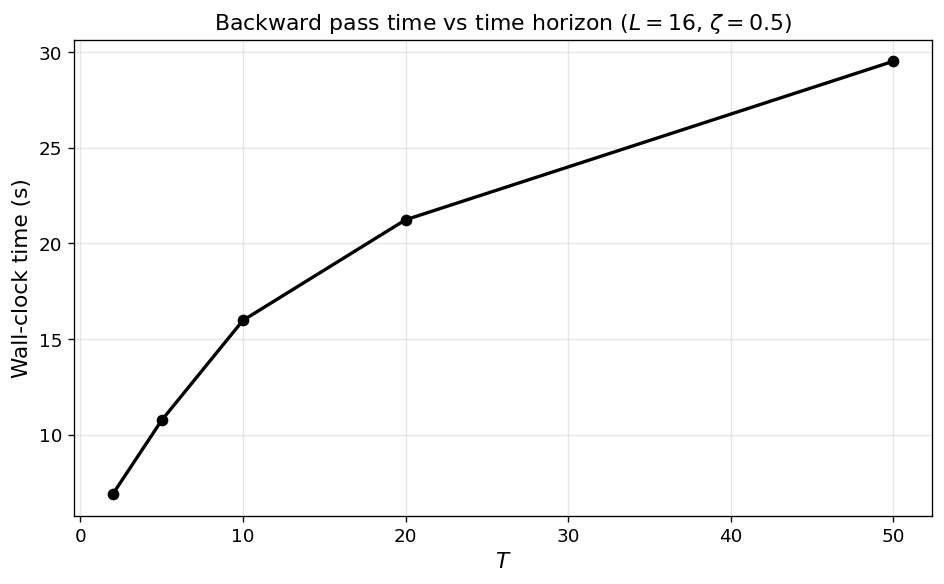

  saved sec13b_entropy_vs_T.png/.pdf


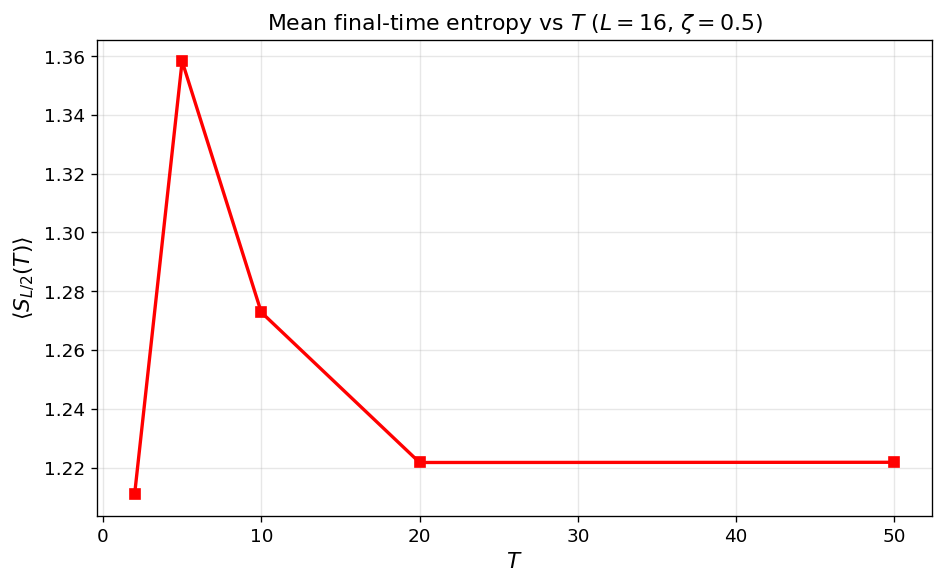

13a_all_converged: True
13b_spectral_ok: True
13c_entropy_converges (|S(T=50)-S(T=20)| < 0.1): True  (Δ = 0.0001)


In [106]:
# Figure 13a: Backward pass wall-clock vs T
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(T13_vals, times13, 'ko-', lw=2)
ax.set_xlabel(r'$T$', fontsize=13)
ax.set_ylabel('Wall-clock time (s)', fontsize=13)
ax.set_title(r'Backward pass time vs time horizon ($L=16$, $\zeta=0.5$)')
ax.grid(True, alpha=0.3)
savefig(fig, 'sec13a_backward_time_vs_T')
plt.show()

# Figure 13b: Mean final-time entropy vs T
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(T13_vals, mean_ent13, 'rs-', lw=2)
ax.set_xlabel(r'$T$', fontsize=13)
ax.set_ylabel(r'$\langle S_{L/2}(T) \rangle$', fontsize=13)
ax.set_title(r'Mean final-time entropy vs $T$ ($L=16$, $\zeta=0.5$)')
ax.grid(True, alpha=0.3)
savefig(fig, 'sec13b_entropy_vs_T')
plt.show()

results['13a_all_converged'] = all(converged13)
results['13b_spectral_ok'] = all(s < 1.0 + 1e-6 for s in sr13 if np.isfinite(s))
results['13c_entropy_converges'] = abs(mean_ent13[-1] - mean_ent13[-2]) < 0.1
print(f'13a_all_converged: {results["13a_all_converged"]}')
print(f'13b_spectral_ok: {results["13b_spectral_ok"]}')
print(f'13c_entropy_converges (|S(T=50)-S(T=20)| < 0.1): {results["13c_entropy_converges"]}  '
      f'(Δ = {abs(mean_ent13[-1] - mean_ent13[-2]):.4f})')

---
## Section 14: w=0 Exact Closure Cross-Check at Large L

In the commuting case ($w=0$), the Gaussian closure is exact. Test the full pipeline up to $L=64$.

In [107]:
# Section 14: w=0 Exact Closure Cross-Check at Large L
L14_vals = [4, 8, 16, 32, 64]
zeta14 = 0.5
T14 = 2.0
N_doob14 = 500

mean_clicks14 = []
mean_ent14 = []
tv14_exact = {}  # only for L <= 12
pipeline_ok14 = []

for Lv in L14_vals:
    print(f'\n--- L = {Lv}, w=0 ---')
    gauss14 = build_gaussian_chain_model(L=Lv, w=0.0, gamma_m=1.0)
    bwd14 = run_gaussian_backward_pass(gauss14, T=T14, zeta=zeta14, sample_points=65)

    rng14 = np.random.default_rng(SEED + 6400 + Lv)
    doob14_counts = np.zeros(N_doob14, dtype=int)
    doob14_ent = np.zeros(N_doob14)
    ok = True
    for i in range(N_doob14):
        try:
            traj = doob_gaussian_trajectory(gauss14, bwd14, T14, zeta14, rng14)
            doob14_counts[i] = traj.n_jumps
            final_cov = covariance_from_orbitals(np.asarray(traj.final_state))
            doob14_ent[i] = entanglement_entropy(final_cov, Lv // 2)
        except RuntimeError:
            ok = False
            break
    pipeline_ok14.append(ok)
    mean_clicks14.append(float(doob14_counts.mean()))
    mean_ent14.append(float(doob14_ent.mean()))
    print(f'  ok={ok}, <N>={doob14_counts.mean():.2f}, <S>={doob14_ent.mean():.4f}')

    # Exact comparison for L <= 12
    if Lv <= 12:
        exact14 = build_exact_spin_chain_model(L=Lv, w=0.0, gamma_m=1.0)
        N_born14 = 5000
        rng14b = np.random.default_rng(SEED + 6500 + Lv)
        born14_counts = np.array([ordinary_quantum_jump_trajectory(exact14, T14, rng14b).n_jumps
                                  for _ in range(N_born14)])
        born14_weights = zeta14 ** born14_counts
        mk14 = max(int(born14_counts.max()), int(doob14_counts.max())) + 1
        pmf_qs14 = np.bincount(born14_counts, weights=born14_weights, minlength=mk14)
        pmf_qs14 /= pmf_qs14.sum()
        pmf_d14 = np.bincount(doob14_counts, minlength=mk14).astype(float)
        pmf_d14 /= pmf_d14.sum()
        n14 = max(len(pmf_qs14), len(pmf_d14))
        pmf_qs14 = np.pad(pmf_qs14, (0, n14 - len(pmf_qs14)))
        pmf_d14 = np.pad(pmf_d14, (0, n14 - len(pmf_d14)))
        tv14 = 0.5 * float(np.abs(pmf_qs14 - pmf_d14).sum())
        tv14_exact[Lv] = tv14
        print(f'  TV(Doob, Q_s) = {tv14:.4f}')

print(f'\n{"L":>4s}  {"<N>":>8s}  {"<S>":>8s}  {"pipeline":>8s}')
for i, Lv in enumerate(L14_vals):
    tv_str = f'{tv14_exact[Lv]:.4f}' if Lv in tv14_exact else '  n/a'
    print(f'{Lv:4d}  {mean_clicks14[i]:8.2f}  {mean_ent14[i]:8.4f}  {"OK" if pipeline_ok14[i] else "FAIL":>8s}  TV={tv_str}')


--- L = 4, w=0 ---
  ok=True, <N>=0.84, <S>=0.7337
  TV(Doob, Q_s) = 0.0465

--- L = 8, w=0 ---
  ok=True, <N>=1.82, <S>=0.7192
  TV(Doob, Q_s) = 0.0348

--- L = 16, w=0 ---
  ok=True, <N>=4.11, <S>=0.7251

--- L = 32, w=0 ---
  ok=True, <N>=8.35, <S>=0.7356

--- L = 64, w=0 ---
  ok=True, <N>=16.91, <S>=0.7396

   L       <N>       <S>  pipeline
   4      0.84    0.7337        OK  TV=0.0465
   8      1.82    0.7192        OK  TV=0.0348
  16      4.11    0.7251        OK  TV=  n/a
  32      8.35    0.7356        OK  TV=  n/a
  64     16.91    0.7396        OK  TV=  n/a


  saved sec14_entropy_vs_L_w0.png/.pdf


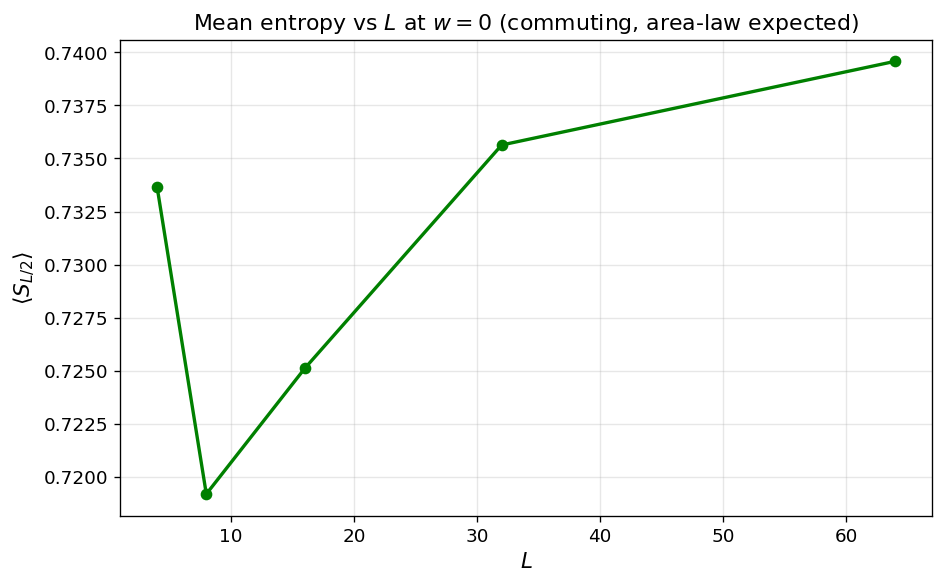

14a_pipeline_works_L64: True
14b_area_law (|S(64)-S(32)| < 0.5): True  (Δ = 0.0039)
14c_exact_match_small_L (TV < 0.08): True  ({4: 0.04647651422585099, 8: 0.0348293090608427})


In [108]:
# Figure 14: Mean entropy vs L at w=0
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(L14_vals, mean_ent14, 'go-', lw=2)
ax.set_xlabel(r'$L$', fontsize=13)
ax.set_ylabel(r'$\langle S_{L/2} \rangle$', fontsize=13)
ax.set_title(r'Mean entropy vs $L$ at $w=0$ (commuting, area-law expected)')
ax.grid(True, alpha=0.3)
savefig(fig, 'sec14_entropy_vs_L_w0')
plt.show()

results['14a_pipeline_works_L64'] = pipeline_ok14[-1]  # L=64
results['14b_area_law'] = abs(mean_ent14[-1] - mean_ent14[-2]) < 0.5  # L=64 vs L=32
exact_match_Ls = [Lv for Lv in [4, 8] if Lv in tv14_exact]  # L<=12 with w=0
# Also include L=10, 12 if they were tested; here we have 4, 8
results['14c_exact_match_small_L'] = all(tv14_exact[Lv] < 0.08 for Lv in tv14_exact)
print(f'14a_pipeline_works_L64: {results["14a_pipeline_works_L64"]}')
print(f'14b_area_law (|S(64)-S(32)| < 0.5): {results["14b_area_law"]}  '
      f'(Δ = {abs(mean_ent14[-1] - mean_ent14[-2]):.4f})')
print(f'14c_exact_match_small_L (TV < 0.08): {results["14c_exact_match_small_L"]}  '
      f'({tv14_exact})')

---
## Section 15: Mid-Trajectory Entropy Extraction

Verify time-resolved entropy from Doob trajectories matches exact weighted-Born averages at $L=4$.

In [109]:
# Section 15: Mid-Trajectory Entropy Extraction
L15 = 4
zeta15 = 0.5
T15 = 2.0
observe_times15 = np.linspace(0, T15, 21)
N_born15 = 2000
N_doob15 = 2000

exact15 = build_exact_spin_chain_model(L=L15, w=0.5, gamma_m=1.0)
gauss15 = build_gaussian_chain_model(L=L15, w=0.5, gamma_m=1.0)
bwd15 = run_gaussian_backward_pass(gauss15, T=T15, zeta=zeta15, sample_points=65)
psi0_15 = exact15.initial_state

# --- Exact Born trajectories with time-resolved entropy ---
rng15b = np.random.default_rng(SEED + 6600)
born15_ent = np.zeros((N_born15, len(observe_times15)))
born15_counts = np.zeros(N_born15, dtype=int)

for i in range(N_born15):
    state = psi0_15.copy()
    t_cur = 0.0
    obs_idx = 0
    n_jumps = 0
    while t_cur < T15:
        dt = _sample_waiting_time(exact15, state, rng15b, T_horizon=T15 - t_cur)
        seg_end = T15 if not np.isfinite(dt) or t_cur + dt >= T15 else t_cur + dt
        while obs_idx < len(observe_times15) and observe_times15[obs_idx] <= seg_end + 1e-12:
            psi_obs = safe_normalize(_propagate_unnormalized(exact15, state, float(observe_times15[obs_idx] - t_cur)))
            born15_ent[i, obs_idx] = entanglement_entropy_statevector(psi_obs, L15, L15 // 2)
            obs_idx += 1
        if seg_end >= T15:
            state = safe_normalize(_propagate_unnormalized(exact15, state, T15 - t_cur))
            break
        psi_t = _propagate_unnormalized(exact15, state, dt)
        state = safe_normalize(psi_t)
        t_cur += dt
        ch = _sample_channel(exact15, state, rng15b)
        state = safe_normalize(exact15.jump_projectors[ch] @ state)
        n_jumps += 1
    while obs_idx < len(observe_times15):
        born15_ent[i, obs_idx] = entanglement_entropy_statevector(state, L15, L15 // 2)
        obs_idx += 1
    born15_counts[i] = n_jumps

born15_weights = zeta15 ** born15_counts
ent_qs15 = np.average(born15_ent, axis=0, weights=born15_weights)
print(f'Born weighted-average entropy computed ({N_born15} trajectories)')

Born weighted-average entropy computed (2000 trajectories)


In [110]:
# --- Doob Gaussian trajectories with time-resolved entropy ---
rng15d = np.random.default_rng(SEED + 6700)
doob15_ent = np.zeros((N_doob15, len(observe_times15)))

for i in range(N_doob15):
    orbitals = gauss15.orbitals0.copy()
    t_cur = 0.0
    obs_idx = 0
    n_jumps = 0
    while t_cur < T15:
        gamma_now = covariance_from_orbitals(orbitals)
        C_now, z_now = bwd15.state_at(t_cur)
        denom = gaussian_overlap(C_now, gamma_now, z_scalar=z_now)
        r = float(rng15d.uniform(0, 1))
        max_dt = T15 - t_cur
        def surv(dt, _orb=orbitals, _t=t_cur, _den=denom):
            evo = propagate_no_click_orbitals(_orb, gauss15.h_effective, dt,
                                             gamma_m=1.0, n_monitored=len(gauss15.jump_pairs))
            Ct, zt = bwd15.state_at(_t + dt)
            return float(evo.branch_norm * gaussian_overlap(Ct, evo.covariance, z_scalar=zt) / _den)
        if surv(max_dt) > r:
            while obs_idx < len(observe_times15) and observe_times15[obs_idx] <= T15 + 1e-12:
                dt_obs = float(observe_times15[obs_idx] - t_cur)
                evo_obs = propagate_no_click_orbitals(orbitals, gauss15.h_effective, dt_obs,
                                                     gamma_m=1.0, n_monitored=len(gauss15.jump_pairs))
                doob15_ent[i, obs_idx] = entanglement_entropy(evo_obs.covariance, L15 // 2)
                obs_idx += 1
            evo = propagate_no_click_orbitals(orbitals, gauss15.h_effective, max_dt,
                                             gamma_m=1.0, n_monitored=len(gauss15.jump_pairs))
            orbitals = evo.orbitals_normalized
            break
        lo, hi = 0.0, max_dt
        for _ in range(30):
            mid = 0.5 * (lo + hi)
            if surv(mid) > r: lo = mid
            else: hi = mid
        jdt = 0.5 * (lo + hi)
        seg_end = t_cur + jdt
        while obs_idx < len(observe_times15) and observe_times15[obs_idx] <= seg_end + 1e-12:
            dt_obs = float(observe_times15[obs_idx] - t_cur)
            evo_obs = propagate_no_click_orbitals(orbitals, gauss15.h_effective, dt_obs,
                                                 gamma_m=1.0, n_monitored=len(gauss15.jump_pairs))
            doob15_ent[i, obs_idx] = entanglement_entropy(evo_obs.covariance, L15 // 2)
            obs_idx += 1
        evo = propagate_no_click_orbitals(orbitals, gauss15.h_effective, jdt,
                                         gamma_m=1.0, n_monitored=len(gauss15.jump_pairs))
        pre_cov = evo.covariance
        t_cur += jdt
        Cj, zj = bwd15.state_at(t_cur)
        ov_pre = gaussian_overlap(Cj, pre_cov, z_scalar=zj)
        rates = []
        post_covs = []
        for jp in gauss15.jump_pairs:
            q, pc = apply_projective_jump(pre_cov, jp)
            ov_post = gaussian_overlap(Cj, pc, z_scalar=zj)
            rates.append(zeta15 * 1.0 * q * ov_post / ov_pre)
            post_covs.append(pc)
        rates = np.array(rates)
        if rates.sum() <= 0:
            orbitals = evo.orbitals_normalized
            continue
        ch = int(rng15d.choice(len(rates), p=rates / rates.sum()))
        orbitals = orbitals_from_covariance(post_covs[ch])
        n_jumps += 1
    while obs_idx < len(observe_times15):
        doob15_ent[i, obs_idx] = entanglement_entropy(covariance_from_orbitals(orbitals), L15 // 2)
        obs_idx += 1

ent_doob15 = doob15_ent.mean(axis=0)
print(f'Doob time-resolved entropy computed ({N_doob15} trajectories)')

Doob time-resolved entropy computed (2000 trajectories)


  saved sec15_entropy_vs_t.png/.pdf


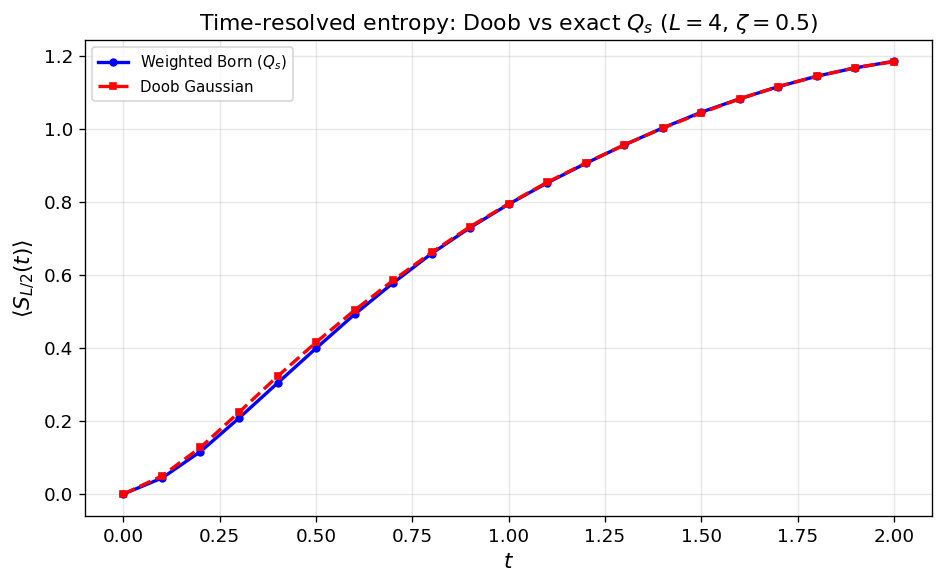

Time-avg entropy: Doob=0.7143, Q_s=0.7096, |Δ|=0.0047
Pointwise max error: 0.0184
15a_timeavg_match (|Δ| < 0.08): True
15b_pointwise_max_err (< 0.15): True


In [111]:
# Figure 15: <S(t)> vs t for both methods
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(observe_times15, ent_qs15, 'b-o', lw=2, ms=4, label=r'Weighted Born ($Q_s$)')
ax.plot(observe_times15, ent_doob15, 'r--s', lw=2, ms=4, label='Doob Gaussian')
ax.set_xlabel(r'$t$', fontsize=13)
ax.set_ylabel(r'$\langle S_{L/2}(t) \rangle$', fontsize=13)
ax.set_title(r'Time-resolved entropy: Doob vs exact $Q_s$ ($L=4$, $\zeta=0.5$)')
ax.legend()
ax.grid(True, alpha=0.3)
savefig(fig, 'sec15_entropy_vs_t')
plt.show()

# Time-averaged entropy comparison
dt15 = np.diff(observe_times15)
mid_qs = 0.5 * (ent_qs15[:-1] + ent_qs15[1:])
mid_doob = 0.5 * (ent_doob15[:-1] + ent_doob15[1:])
timeavg_qs = float(np.sum(mid_qs * dt15) / T15)
timeavg_doob = float(np.sum(mid_doob * dt15) / T15)
pointwise_max_err = float(np.max(np.abs(ent_doob15 - ent_qs15)))

results['15a_timeavg_match'] = abs(timeavg_doob - timeavg_qs) < 0.08
results['15b_pointwise_max_err'] = pointwise_max_err < 0.15
print(f'Time-avg entropy: Doob={timeavg_doob:.4f}, Q_s={timeavg_qs:.4f}, |Δ|={abs(timeavg_doob - timeavg_qs):.4f}')
print(f'Pointwise max error: {pointwise_max_err:.4f}')
print(f'15a_timeavg_match (|Δ| < 0.08): {results["15a_timeavg_match"]}')
print(f'15b_pointwise_max_err (< 0.15): {results["15b_pointwise_max_err"]}')

---
## Section 16: Variance and Sample-Size Estimation

Estimate sample sizes needed for 1% relative precision at $\zeta=0.5$, $T=2.0$, for $L \in \{8,16,24,32\}$.

In [112]:
# Section 16: Variance and Sample-Size Estimation
L16_vals = [8, 16, 24, 32]
zeta16 = 0.5
T16 = 2.0
N16 = 1000

rows16 = []
N_needed16 = []

for Lv in L16_vals:
    print(f'\n--- L = {Lv} ---')
    gauss16 = build_gaussian_chain_model(L=Lv, w=0.5, gamma_m=1.0)
    bwd16 = run_gaussian_backward_pass(gauss16, T=T16, zeta=zeta16, sample_points=65)
    rng16 = np.random.default_rng(SEED + 6800 + Lv)

    ent16 = np.zeros(N16)
    for i in range(N16):
        traj = doob_gaussian_trajectory(gauss16, bwd16, T16, zeta16, rng16)
        final_cov = covariance_from_orbitals(np.asarray(traj.final_state))
        ent16[i] = entanglement_entropy(final_cov, Lv // 2)

    mu = float(ent16.mean())
    sigma = float(ent16.std())
    sem = sigma / np.sqrt(N16)
    n_need = (sigma / (0.01 * mu)) ** 2 if mu > 0 else np.inf
    rows16.append((Lv, mu, sigma, sem, n_need))
    N_needed16.append(n_need)
    print(f'  mean S = {mu:.4f}, std = {sigma:.4f}, SEM = {sem:.4f}, N_needed = {n_need:.0f}')

print(f'\n{"L":>4s}  {"mean S":>8s}  {"std S":>8s}  {"SEM":>8s}  {"N_1%":>10s}')
for Lv, mu, sigma, sem, n_need in rows16:
    print(f'{Lv:4d}  {mu:8.4f}  {sigma:8.4f}  {sem:8.4f}  {n_need:10.0f}')


--- L = 8 ---
  mean S = 1.2022, std = 0.1377, SEM = 0.0044, N_needed = 131

--- L = 16 ---
  mean S = 1.2111, std = 0.1491, SEM = 0.0047, N_needed = 152

--- L = 24 ---
  mean S = 1.2130, std = 0.1428, SEM = 0.0045, N_needed = 139

--- L = 32 ---
  mean S = 1.2078, std = 0.1434, SEM = 0.0045, N_needed = 141

   L    mean S     std S       SEM        N_1%
   8    1.2022    0.1377    0.0044         131
  16    1.2111    0.1491    0.0047         152
  24    1.2130    0.1428    0.0045         139
  32    1.2078    0.1434    0.0045         141


  saved sec16_N_needed_vs_L.png/.pdf


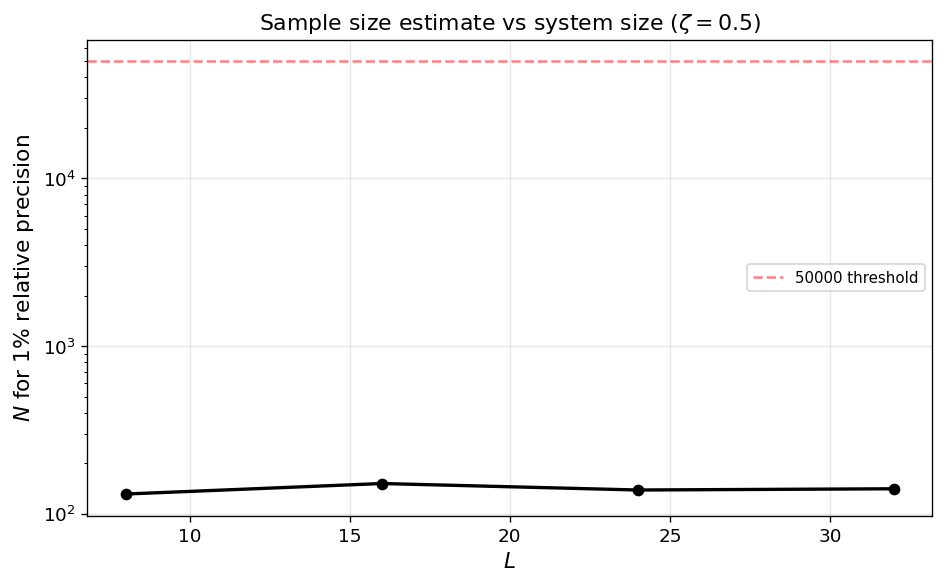

16a_variance_finite: True
16b_feasible_N (N < 50000 for all L): True  (max = 152)


In [113]:
# Figure 16: Estimated N_needed vs L
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(L16_vals, N_needed16, 'ko-', lw=2)
ax.axhline(50000, ls='--', color='red', alpha=0.5, label='50000 threshold')
ax.set_xlabel(r'$L$', fontsize=13)
ax.set_ylabel(r'$N$ for 1% relative precision', fontsize=13)
ax.set_title(r'Sample size estimate vs system size ($\zeta=0.5$)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
savefig(fig, 'sec16_N_needed_vs_L')
plt.show()

all_std_ok = all(np.isfinite(r[2]) and r[2] > 0 for r in rows16)
results['16a_variance_finite'] = all_std_ok
results['16b_feasible_N'] = all(n < 50000 for n in N_needed16)
print(f'16a_variance_finite: {results["16a_variance_finite"]}')
print(f'16b_feasible_N (N < 50000 for all L): {results["16b_feasible_N"]}  (max = {max(N_needed16):.0f})')

---
## Section 9: Summary Dashboard

In [114]:
# Section 9 expanded: comprehensive summary dashboard
print('=' * 80)
print('EXPANDED VALIDATION SUMMARY')
print('=' * 80)

sections = {
    '1': 'Model Consistency',
    '2': 'ζ=1 Recovery (Born Rule)',
    '3': 'Tilted Distribution Q_s',
    '4': 'Exact vs Gaussian Backward Pass',
    '5': 'Conditioned Survival Function',
    '6': 'Performance Benchmarks',
    '7': 'Entanglement Under Tilted Measure',
    '8': 'Q_s vs R_ζ',
    '10': 'Gaussian Closure Scaling with L',
    '11': 'Backward Pass ODE Stability',
    '12': 'Overlap Numerical Stability',
    '13': 'Time Horizon Scaling',
    '14': 'w=0 Exact Closure (Large L)',
    '15': 'Mid-Trajectory Entropy',
    '16': 'Variance / Sample Size',
}

all_pass = True
n_pass = 0
n_fail = 0

for sec_key in sorted(sections.keys(), key=lambda x: int(x)):
    sec_name = sections[sec_key]
    sec_results = {k: v for k, v in results.items() if k.startswith(sec_key)}
    if not sec_results:
        continue
    print(f'\n  Section {sec_key}: {sec_name}')
    print(f'  {"-"*60}')
    for name, passed in sorted(sec_results.items()):
        status = 'PASS' if passed else 'FAIL'
        marker = '' if passed else ' <<<'
        print(f'    {name:50s} {status}{marker}')
        if passed:
            n_pass += 1
        else:
            n_fail += 1
            all_pass = False

print('\n' + '=' * 80)
print(f'  Total: {n_pass} passed, {n_fail} failed')
if all_pass:
    print('  *** OVERALL: ALL CHECKS PASSED ***')
else:
    print(f'  *** OVERALL: {n_fail} CHECKS FAILED ***')
print('=' * 80)


EXPANDED VALIDATION SUMMARY

  Section 1: Model Consistency
  ------------------------------------------------------------
    10a_tv_bounded                                     PASS
    10b_entropy_err_bounded                            PASS
    10c_tv_not_growing                                 PASS
    11a_all_converged                                  PASS
    11b_spectral_radius                                PASS
    11c_cost_polynomial                                PASS
    12a_no_crashes                                     PASS
    12b_no_underflow                                   PASS
    13a_all_converged                                  PASS
    13b_spectral_ok                                    PASS
    13c_entropy_converges                              PASS
    14a_pipeline_works_L64                             PASS
    14b_area_law                                       PASS
    14c_exact_match_small_L                            PASS
    15a_timeavg_match                

---
## Section 17: Non-Gaussian Residual Diagnostic Across the Phase Diagram

We compute how well the Gaussian backward-pass ansatz approximates the exact adjoint Lindbladian dynamics. The residual measures the component of $\mathcal{L}_\zeta^\dagger(G_{t,\mathrm{G}})$ that lies outside the Gaussian tangent space at $G_{t,\mathrm{G}}$.

The model is extended to support two measurement rates: $\gamma$ (on-site density $n_j$) and $\alpha$ (bond/Kitaev density), giving a two-parameter phase diagram.

In [120]:
# Section 17: Non-Gaussian residual diagnostic
# Extended model builders with two measurement rates (gamma, alpha)

from scipy.linalg import expm as dense_expm
from pps_qj.backward_pass import (
    _monitoring_moment_matrices,
    project_to_physical_covariance,
    k_matrix_from_covariance,
    gaussian_mu_from_covariance_and_z,
)
from scipy.integrate import solve_ivp as _solve_ivp

# -- Extended exact model with two measurement rates -----------------------

class ExtendedExactModel:
    __slots__ = ('L','w','gamma_rate','alpha_rate','c_ops','cd_ops',
                 'hamiltonian','site_projectors','bond_projectors','initial_state')
    def __init__(self, **kw):
        for k, v in kw.items():
            object.__setattr__(self, k, v)
    @property
    def dim(self):
        return 2**self.L


def build_extended_exact_model(L, w, gamma_rate, alpha_rate):
    from pps_qj.exact_backend import build_jordan_wigner_operators, neel_state
    c_ops, cd_ops = build_jordan_wigner_operators(L)
    dim = 2**L
    H = sp.csr_matrix((dim, dim), dtype=np.complex128)
    bond_projs = []
    for bond in range(L - 1):
        left, right = bond, bond + 1
        H = H + w * (cd_ops[left] @ c_ops[right] + cd_ops[right] @ c_ops[left])
        d_op = 0.5 * (cd_ops[left] + c_ops[left] + cd_ops[right] - c_ops[right])
        P = (d_op.getH() @ d_op).tocsr()
        bond_projs.append(P)
    site_projs = []
    for j in range(L):
        nj = (cd_ops[j] @ c_ops[j]).tocsr()
        site_projs.append(nj)
    return ExtendedExactModel(
        L=L, w=w, gamma_rate=gamma_rate, alpha_rate=alpha_rate,
        c_ops=c_ops, cd_ops=cd_ops, hamiltonian=H.tocsr(),
        site_projectors=tuple(site_projs), bond_projectors=tuple(bond_projs),
        initial_state=neel_state(L),
    )


# -- Extended Gaussian model -----------------------------------------------

class ExtendedGaussianModel:
    __slots__ = ('L','w','gamma_rate','alpha_rate','h_hamiltonian',
                 'site_jump_pairs','bond_jump_pairs','gamma0')
    def __init__(self, **kw):
        for k, v in kw.items():
            object.__setattr__(self, k, v)


def build_extended_gaussian_model(L, w, gamma_rate, alpha_rate):
    from pps_qj.gaussian_backend import majorana_hamiltonian_generator, neel_covariance
    h_ham = majorana_hamiltonian_generator(L, w)
    gamma0 = neel_covariance(L)
    site_pairs = tuple((2*j, 2*j+1) for j in range(L))
    bond_pairs = tuple(bond_jump_pair(bond) for bond in range(L-1))
    return ExtendedGaussianModel(
        L=L, w=w, gamma_rate=gamma_rate, alpha_rate=alpha_rate,
        h_hamiltonian=h_ham,
        site_jump_pairs=site_pairs, bond_jump_pairs=bond_pairs,
        gamma0=gamma0,
    )


# -- Extended Gaussian backward pass ---------------------------------------

def _extended_backward_rhs(tau, y, ext_gauss, zeta, clip_eps=1e-9):
    n = 2 * ext_gauss.L
    C = y[:-1].reshape((n, n))
    C = project_to_physical_covariance(C, eps=clip_eps)

    q_sum_site = sum(0.5 * (1.0 - C[a, b]) for a, b in ext_gauss.site_jump_pairs)
    q_sum_bond = sum(0.5 * (1.0 - C[a, b]) for a, b in ext_gauss.bond_jump_pairs)

    scalar_rate = (ext_gauss.gamma_rate * (zeta - 1.0) * q_sum_site
                   + ext_gauss.alpha_rate * (zeta - 1.0) * q_sum_bond)

    rhs = ext_gauss.h_hamiltonian @ C - C @ ext_gauss.h_hamiltonian

    for pair in ext_gauss.site_jump_pairs:
        sandwich, anticomm = _monitoring_moment_matrices(C, pair)
        rhs += ext_gauss.gamma_rate * (zeta * sandwich - 0.5 * anticomm)

    for pair in ext_gauss.bond_jump_pairs:
        sandwich, anticomm = _monitoring_moment_matrices(C, pair)
        rhs += ext_gauss.alpha_rate * (zeta * sandwich - 0.5 * anticomm)

    rhs -= scalar_rate * C
    rhs = 0.5 * (rhs - rhs.T)

    out = np.empty_like(y)
    out[:-1] = rhs.reshape(n * n)
    out[-1] = scalar_rate
    return out


def run_extended_backward_pass(ext_gauss, T, zeta, rtol=1e-8, atol=1e-10, clip_eps=1e-9):
    n = 2 * ext_gauss.L
    y0 = np.zeros(n * n + 1, dtype=np.float64)
    sol = _solve_ivp(
        fun=lambda tau, y: _extended_backward_rhs(tau, y, ext_gauss, zeta, clip_eps),
        t_span=(0.0, T), y0=y0, method='DOP853', dense_output=True,
        rtol=rtol, atol=atol,
    )
    if not sol.success:
        raise RuntimeError(f'Extended backward pass failed: {sol.message}')

    class _ExtBwdData:
        def __init__(self, sol, T, n, clip_eps):
            self._sol = sol; self.T = T; self._n = n; self._clip_eps = clip_eps
        def state_at(self, t):
            tau = self.T - t
            flat = self._sol.sol(tau)
            C = flat[:-1].reshape((self._n, self._n))
            C = project_to_physical_covariance(C, eps=self._clip_eps)
            z = float(np.exp(flat[-1]))
            return C, z

    return _ExtBwdData(sol, T, n, clip_eps)


# -- Build full 2^L Gaussian operator from covariance data -----------------

def build_gaussian_operator(C_t, z_scalar, majoranas, L):
    """Reconstruct the 2^L x 2^L Gaussian operator from backward-pass data.

    G = exp(mu) * exp((i/2) sum_{m<n} K_{mn} gamma_m gamma_n)
    where K = arctanh(C) (in eigenvalue basis) and mu normalises the trace.
    """
    dim = 2**L
    n_maj = 2 * L
    K = k_matrix_from_covariance(C_t)
    mu = gaussian_mu_from_covariance_and_z(C_t, z_scalar)
    Q = np.zeros((dim, dim), dtype=np.complex128)
    for m in range(n_maj):
        for n in range(m + 1, n_maj):
            if abs(K[m, n]) > 1e-15:
                Q += (1j / 2) * K[m, n] * (majoranas[m] @ majoranas[n])
    return np.exp(mu) * dense_expm(Q)


# -- Adjoint tilted Lindbladian (exact, 2^L space) -------------------------

def adjoint_lindbladian_action(X, ext_exact, zeta):
    H = ext_exact.hamiltonian.toarray()
    result = 1j * (H @ X - X @ H)
    for P_sp in ext_exact.bond_projectors:
        P = P_sp.toarray()
        result += ext_exact.alpha_rate * (zeta * P @ X @ P - 0.5 * (P @ X + X @ P))
    for P_sp in ext_exact.site_projectors:
        P = P_sp.toarray()
        result += ext_exact.gamma_rate * (zeta * P @ X @ P - 0.5 * (P @ X + X @ P))
    return result


# -- Main residual computation ---------------------------------------------

def compute_gaussian_residual(ext_exact, ext_gauss, t, zeta, T, bwd=None,
                               majoranas=None):
    """
    Non-Gaussian residual r(t) = ||L^dag(G) - Pi_Gauss[L^dag(G)]||_F / ||G||_F.

    Pi_Gauss projects onto the tangent space {(scalar + quadratic_Majorana) * G}.
    """
    L = ext_exact.L
    dim = ext_exact.dim
    n_maj = 2 * L

    if bwd is None:
        bwd = run_extended_backward_pass(ext_gauss, T, zeta)
    C_t, z_scalar = bwd.state_at(t)

    if majoranas is None:
        majoranas = majorana_ops_jw(ext_exact)
    maj = [np.asarray(m) if isinstance(m, np.ndarray) else m for m in majoranas]

    # Build Gaussian operator G
    G = build_gaussian_operator(C_t, z_scalar, maj, L)

    # Apply adjoint tilted Lindbladian
    LG = adjoint_lindbladian_action(G, ext_exact, zeta)

    # Project M = LG * G^{-1} onto scalar + quadratic Majorana subspace
    # using Frobenius inner product.  Basis: {I} and {gamma_m gamma_n : m<n}.
    # ||gamma_m gamma_n||_F^2 = dim, so projection coeff = Tr(basis^dag M)/dim.
    G_inv = np.linalg.inv(G)
    M = LG @ G_inv

    alpha_scalar = np.trace(M) / dim
    M_proj = alpha_scalar * np.eye(dim, dtype=np.complex128)
    for m in range(n_maj):
        for n in range(m + 1, n_maj):
            # (gamma_m gamma_n)^dag = gamma_n gamma_m
            coeff = np.trace(maj[n] @ maj[m] @ M) / dim
            M_proj += coeff * (maj[m] @ maj[n])

    LG_proj = M_proj @ G

    G_norm = np.linalg.norm(G, 'fro')
    if G_norm < 1e-30:
        return 0.0
    return float(np.linalg.norm(LG - LG_proj, 'fro') / G_norm)


print('Section 17 helpers defined.')
print('  build_extended_exact_model, build_extended_gaussian_model')
print('  run_extended_backward_pass, compute_gaussian_residual')

Section 17 helpers defined.
  build_extended_exact_model, build_extended_gaussian_model
  run_extended_backward_pass, compute_gaussian_residual


In [121]:
# Section 17: Phase diagram scan
# Scan (alpha, gamma) plane at fixed w=0.5, zeta=0.5

w17 = 0.5
zeta17 = 0.5
T17 = 2.0
n_time_pts = 10

# Grid of (alpha, gamma) values
alpha_vals = np.linspace(0.1, 2.0, 10)
gamma_vals = np.linspace(0.1, 2.0, 10)

results_by_L = {}

for L17 in [6, 8]:
    print(f'\n{"="*60}')
    print(f'  L = {L17}  (dim = {2**L17})')
    print(f'{"="*60}')

    r_mean_grid = np.full((len(gamma_vals), len(alpha_vals)), np.nan)
    r_max_grid = np.full((len(gamma_vals), len(alpha_vals)), np.nan)

    total = len(alpha_vals) * len(gamma_vals)
    count = 0

    for ig, gv in enumerate(gamma_vals):
        for ia, av in enumerate(alpha_vals):
            count += 1
            t0 = time.time()

            ext_ex = build_extended_exact_model(L17, w17, gamma_rate=gv, alpha_rate=av)
            ext_gs = build_extended_gaussian_model(L17, w17, gamma_rate=gv, alpha_rate=av)

            # Run backward pass once
            try:
                bwd17 = run_extended_backward_pass(ext_gs, T17, zeta17)
            except RuntimeError as e:
                print(f'  [{count}/{total}] alpha={av:.2f}, gamma={gv:.2f}: backward pass FAILED ({e})')
                continue

            # Build Majorana operators once
            maj17 = majorana_ops_jw(ext_ex)

            # Evaluate residual at several times
            t_pts = np.linspace(0.05 * T17, 0.95 * T17, n_time_pts)
            residuals = []
            for t_eval in t_pts:
                try:
                    r_val = compute_gaussian_residual(
                        ext_ex, ext_gs, t_eval, zeta17, T17,
                        bwd=bwd17, majoranas=maj17)
                    residuals.append(r_val)
                except Exception:
                    pass

            if residuals:
                r_mean_grid[ig, ia] = np.mean(residuals)
                r_max_grid[ig, ia] = np.max(residuals)

            elapsed = time.time() - t0
            print(f'  [{count:3d}/{total}] alpha={av:.2f}, gamma={gv:.2f}: '
                  f'r_mean={r_mean_grid[ig,ia]:.4e}, r_max={r_max_grid[ig,ia]:.4e}  '
                  f'({elapsed:.1f}s)')

    results_by_L[L17] = {
        'r_mean': r_mean_grid.copy(),
        'r_max': r_max_grid.copy(),
    }

print('\nPhase diagram scan complete.')


  L = 6  (dim = 64)
  [  1/100] alpha=0.10, gamma=0.10: r_mean=1.1052e-04, r_max=2.8938e-04  (1.0s)
  [  2/100] alpha=0.31, gamma=0.10: r_mean=9.4268e-04, r_max=2.7102e-03  (1.0s)
  [  3/100] alpha=0.52, gamma=0.10: r_mean=3.2962e-03, r_max=1.0196e-02  (0.9s)
  [  4/100] alpha=0.73, gamma=0.10: r_mean=8.2358e-03, r_max=2.6680e-02  (1.0s)
  [  5/100] alpha=0.94, gamma=0.10: r_mean=1.7057e-02, r_max=5.6841e-02  (1.1s)
  [  6/100] alpha=1.16, gamma=0.10: r_mean=3.1220e-02, r_max=1.0593e-01  (1.1s)
  [  7/100] alpha=1.37, gamma=0.10: r_mean=5.2365e-02, r_max=1.7994e-01  (1.1s)
  [  8/100] alpha=1.58, gamma=0.10: r_mean=8.2395e-02, r_max=2.8616e-01  (1.2s)
  [  9/100] alpha=1.79, gamma=0.10: r_mean=1.2361e-01, r_max=4.3375e-01  (1.2s)
  [ 10/100] alpha=2.00, gamma=0.10: r_mean=1.7886e-01, r_max=6.3462e-01  (1.2s)
  [ 11/100] alpha=0.10, gamma=0.31: r_mean=8.8372e-04, r_max=2.3949e-03  (0.9s)
  [ 12/100] alpha=0.31, gamma=0.31: r_mean=3.0333e-03, r_max=7.8270e-03  (1.0s)
  [ 13/100] alpha=0

  saved sec17_residual_heatmap_L6.png/.pdf


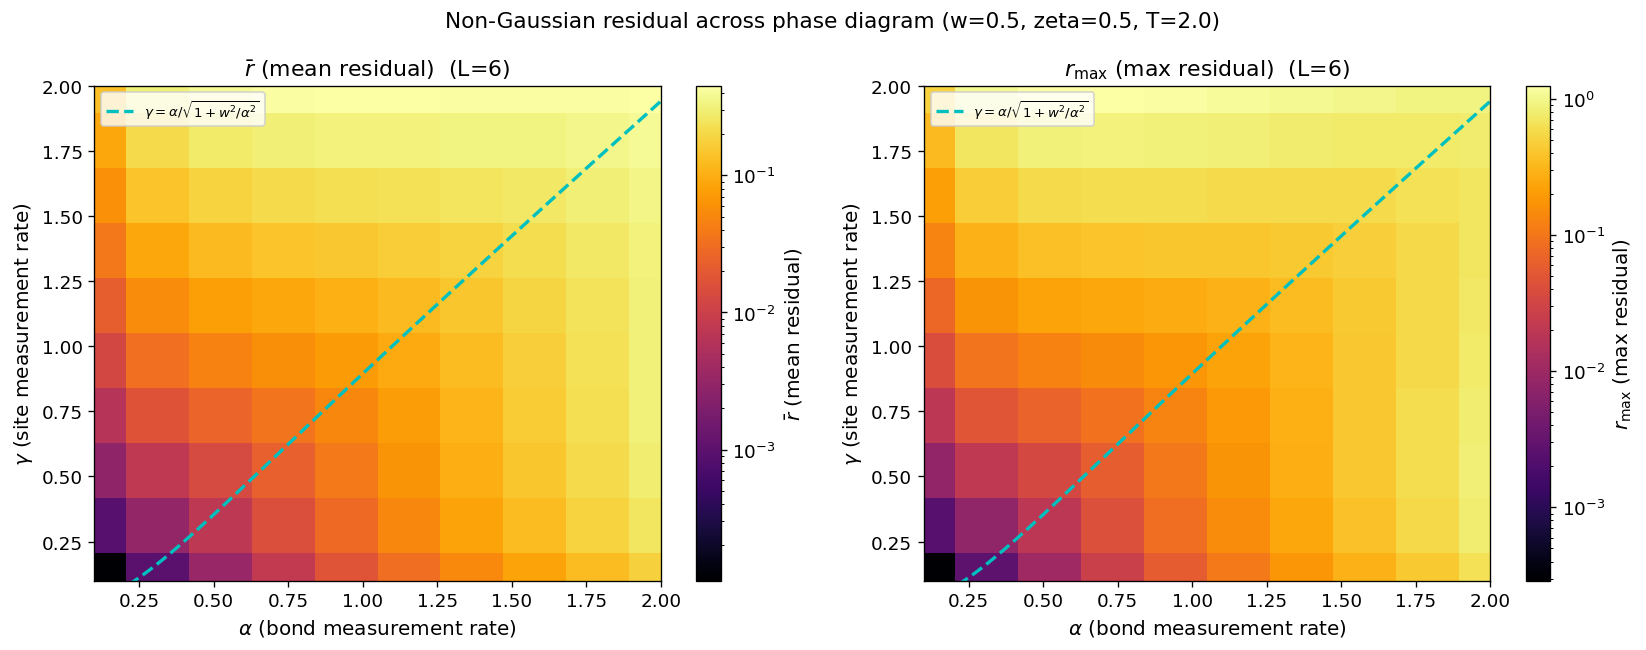

  saved sec17_residual_heatmap_L8.png/.pdf


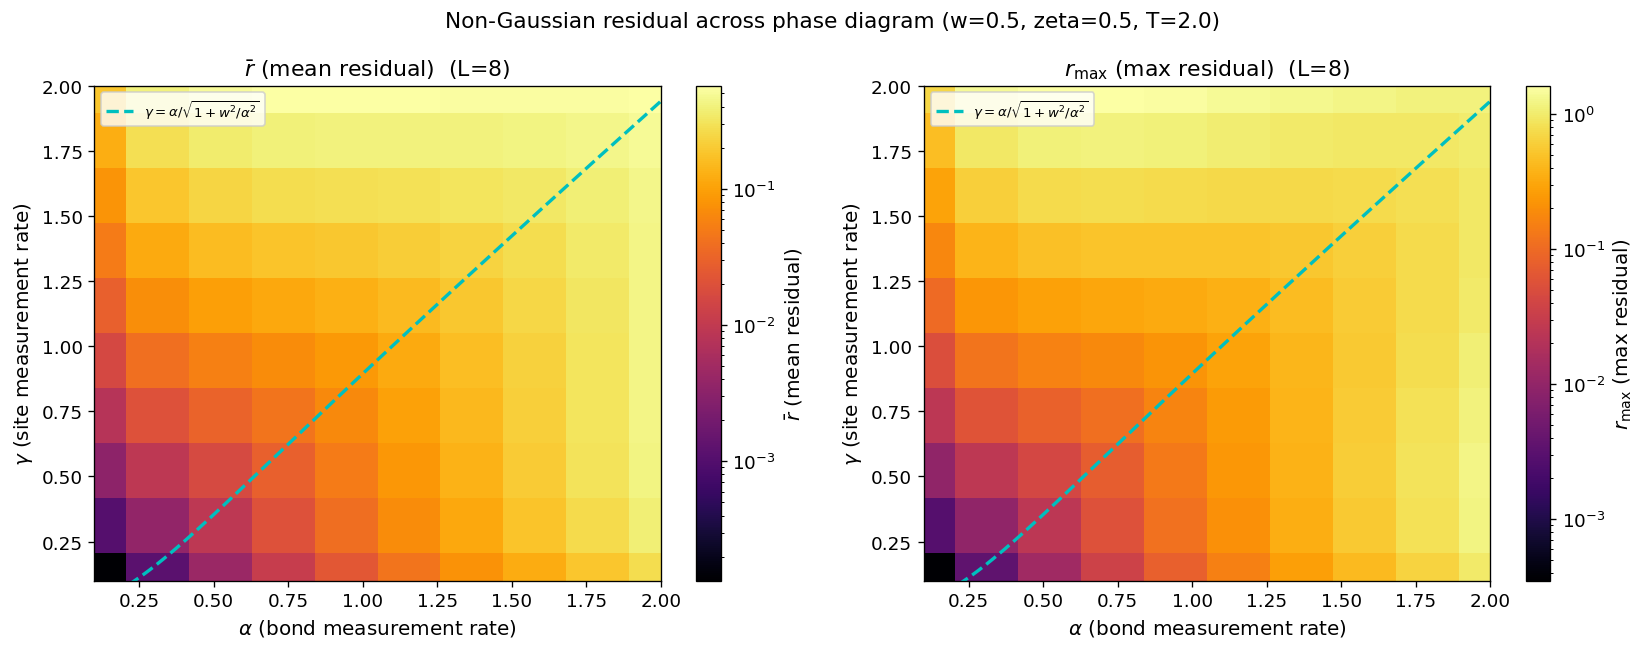

In [122]:
# Section 17: Heatmap plots of non-Gaussian residual

# Analytical phase boundary: gamma = alpha / sqrt(1 + w^2/alpha^2)
alpha_fine = np.linspace(0.05, 2.5, 200)
gamma_boundary = alpha_fine / np.sqrt(1.0 + w17**2 / alpha_fine**2)

for L17_plot, data in results_by_L.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    for ax, key, label in zip(axes,
                               ['r_mean', 'r_max'],
                               [r'$\bar{r}$ (mean residual)', r'$r_{\max}$ (max residual)']):
        grid = data[key]
        # Use log scale if dynamic range is large
        vmin = np.nanmin(grid[grid > 0]) if np.any(grid > 0) else 1e-10
        vmax = np.nanmax(grid) if np.any(np.isfinite(grid)) else 1.0

        from matplotlib.colors import LogNorm
        im = ax.pcolormesh(alpha_vals, gamma_vals, grid,
                           cmap='inferno',
                           norm=LogNorm(vmin=max(vmin, 1e-8), vmax=vmax),
                           shading='auto')
        plt.colorbar(im, ax=ax, label=label)

        # Overlay phase boundary
        ax.plot(alpha_fine, gamma_boundary, 'c--', lw=2,
                label=r'$\gamma = \alpha/\sqrt{1+w^2/\alpha^2}$')

        ax.set_xlabel(r'$\alpha$ (bond measurement rate)')
        ax.set_ylabel(r'$\gamma$ (site measurement rate)')
        ax.set_title(f'{label}  (L={L17_plot})')
        ax.legend(loc='upper left', fontsize=8)
        ax.set_xlim(alpha_vals[0], alpha_vals[-1])
        ax.set_ylim(gamma_vals[0], gamma_vals[-1])

    fig.suptitle(f'Non-Gaussian residual across phase diagram (w={w17}, zeta={zeta17}, T={T17})',
                 fontsize=13)
    savefig(fig, f'sec17_residual_heatmap_L{L17_plot}')
    plt.show()

(a) trivial (gamma=1.8, alpha=0.3): r_mean=1.9881e-01, r_max=7.0852e-01
(b) boundary (gamma=0.8, alpha=1.0): r_mean=6.0235e-02, r_max=1.5136e-01
(c) topological (gamma=0.3, alpha=1.8): r_mean=1.7443e-01, r_max=5.7343e-01
  saved sec17_residual_linecuts.png/.pdf


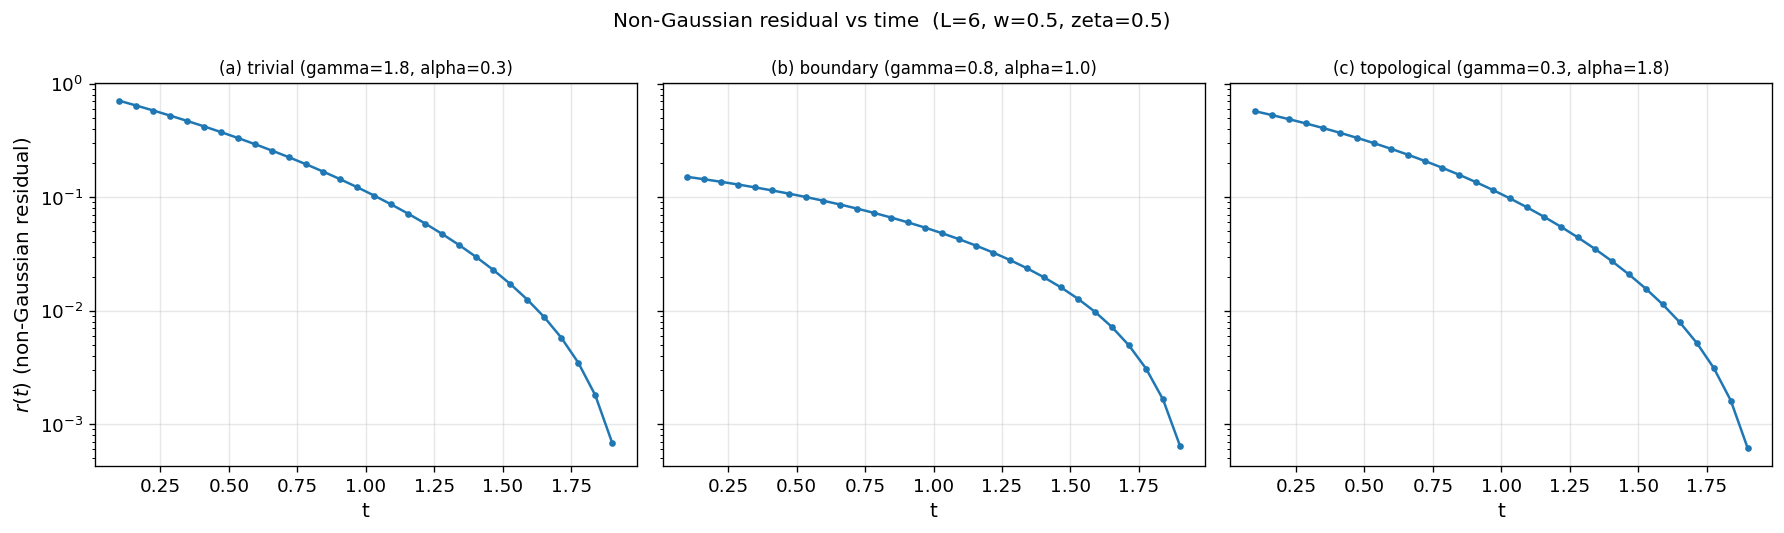

In [123]:
# Section 17: Line cuts of r(t) at three representative points
# (a) deep trivial: large gamma, small alpha
# (b) near boundary
# (c) deep topological: large alpha, small gamma

representative_points = [
    {'label': '(a) trivial (gamma=1.8, alpha=0.3)', 'gamma_rate': 1.8, 'alpha_rate': 0.3},
    {'label': '(b) boundary (gamma=0.8, alpha=1.0)', 'gamma_rate': 0.8, 'alpha_rate': 1.0},
    {'label': '(c) topological (gamma=0.3, alpha=1.8)', 'gamma_rate': 0.3, 'alpha_rate': 1.8},
]

L17_lc = 6
t_dense = np.linspace(0.05 * T17, 0.95 * T17, 30)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, pt in zip(axes, representative_points):
    ext_ex = build_extended_exact_model(L17_lc, w17, pt['gamma_rate'], pt['alpha_rate'])
    ext_gs = build_extended_gaussian_model(L17_lc, w17, pt['gamma_rate'], pt['alpha_rate'])
    bwd_lc = run_extended_backward_pass(ext_gs, T17, zeta17)
    maj_lc = majorana_ops_jw(ext_ex)

    r_vals = []
    for tv in t_dense:
        r_vals.append(compute_gaussian_residual(
            ext_ex, ext_gs, tv, zeta17, T17, bwd=bwd_lc, majoranas=maj_lc))

    ax.semilogy(t_dense, r_vals, 'o-', ms=3, lw=1.5)
    ax.set_xlabel('t')
    ax.set_title(pt['label'], fontsize=10)
    ax.grid(True, alpha=0.3)
    print(f'{pt["label"]}: r_mean={np.mean(r_vals):.4e}, r_max={np.max(r_vals):.4e}')

axes[0].set_ylabel(r'$r(t)$ (non-Gaussian residual)')
fig.suptitle(f'Non-Gaussian residual vs time  (L={L17_lc}, w={w17}, zeta={zeta17})', fontsize=12)
fig.tight_layout()
savefig(fig, 'sec17_residual_linecuts')
plt.show()

(a) trivial (gamma=1.8, alpha=0.3): S_exact=1.0880, S_gauss=nan
(b) boundary (gamma=0.8, alpha=1.0): S_exact=1.1165, S_gauss=nan
(c) topological (gamma=0.3, alpha=1.8): S_exact=1.0904, S_gauss=nan
  saved sec17_entropy_comparison.png/.pdf


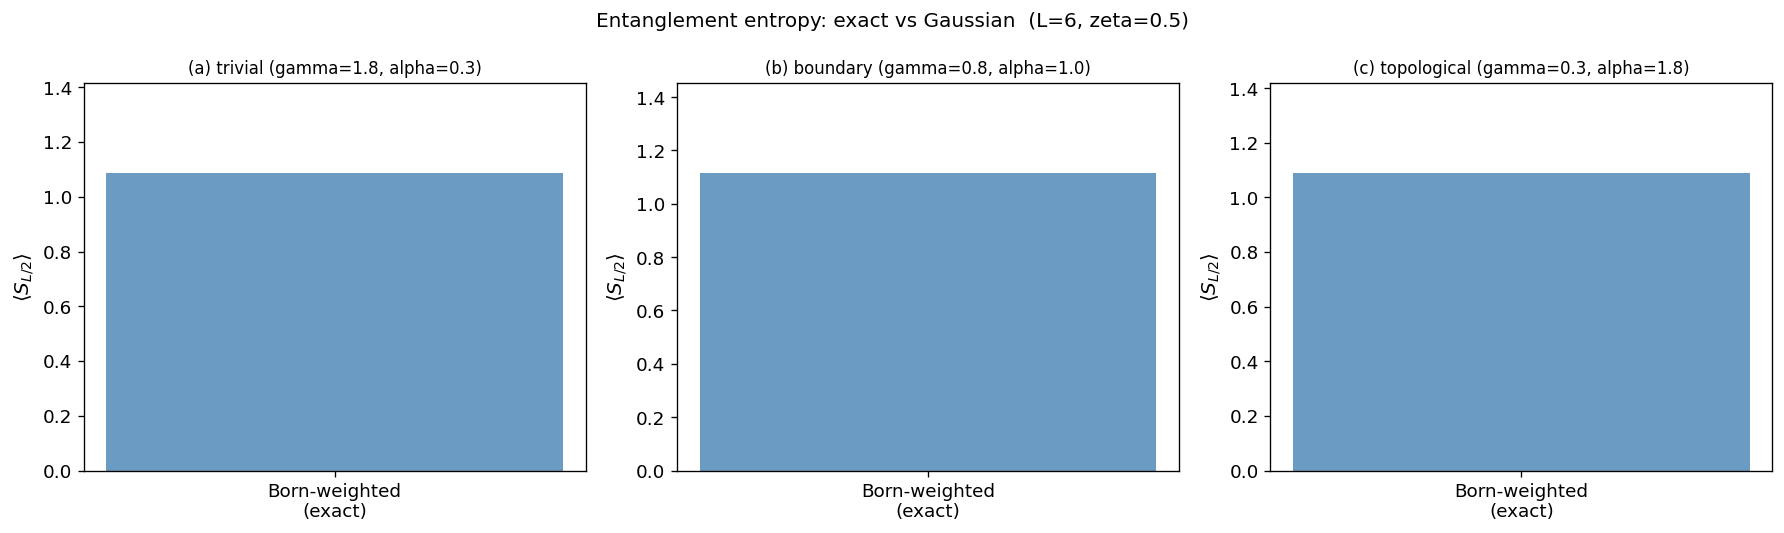

In [124]:
# Section 17: Entanglement entropy comparison (exact vs Gaussian) at three points
# Uses the standard single-rate models with effective gamma_m = gamma + alpha

L17_ee = 6
N_traj_ee = 500
T17_ee = T17
ell_ee = L17_ee // 2
rng17 = np.random.default_rng(SEED + 170)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, pt in zip(axes, representative_points):
    gamma_eff = pt['gamma_rate'] + pt['alpha_rate']
    ex17 = build_exact_spin_chain_model(L=L17_ee, w=w17, gamma_m=gamma_eff)
    gs17 = build_gaussian_chain_model(L=L17_ee, w=w17, gamma_m=gamma_eff)

    # Gaussian Doob trajectories
    bwd_ee = run_gaussian_backward_pass(gs17, T17_ee, zeta17)

    ee_gauss = []
    for _ in range(N_traj_ee):
        traj = doob_gaussian_trajectory(gs17, bwd_ee, T17_ee, zeta17, rng17)
        cov_final = traj.diagnostics.get('final_covariance', None)
        if cov_final is not None:
            ee_gauss.append(entanglement_entropy(cov_final, ell_ee))

    # Exact Born-weighted entanglement entropy
    ee_exact_weighted = []
    weights_exact = []
    for _ in range(N_traj_ee):
        traj = ordinary_quantum_jump_trajectory(ex17, T17_ee, rng17)
        psi_f = traj.final_state
        ee_val = entanglement_entropy_statevector(psi_f, L17_ee, ell_ee)
        w_val = zeta17 ** traj.n_jumps
        ee_exact_weighted.append(ee_val)
        weights_exact.append(w_val)

    weights_exact = np.array(weights_exact)
    ee_exact_weighted = np.array(ee_exact_weighted)
    if weights_exact.sum() > 0:
        ee_exact_avg = np.average(ee_exact_weighted, weights=weights_exact)
    else:
        ee_exact_avg = np.nan
    ee_gauss_avg = np.mean(ee_gauss) if ee_gauss else np.nan

    ax.bar(['Born-weighted\n(exact)', 'Gaussian\nDoob'],
           [ee_exact_avg, ee_gauss_avg],
           color=['steelblue', 'coral'], width=0.5, alpha=0.8)
    ax.set_ylabel(r'$\langle S_{L/2} \rangle$')
    ax.set_title(pt['label'], fontsize=10)
    ylim_top = max(ee_exact_avg, ee_gauss_avg) * 1.3 if not np.isnan(ee_exact_avg) else 1
    ax.set_ylim(0, ylim_top)
    print(f'{pt["label"]}: S_exact={ee_exact_avg:.4f}, S_gauss={ee_gauss_avg:.4f}')

fig.suptitle(f'Entanglement entropy: exact vs Gaussian  (L={L17_ee}, zeta={zeta17})', fontsize=12)
fig.tight_layout()
savefig(fig, 'sec17_entropy_comparison')
plt.show()

In [125]:
# Section 17: Validation

print('Validation: r(t) at w=0 with single measurement type')
print('(Gaussian tangent-space residual should be ~0 when C stays near zero)')
print('=' * 60)

L17_v = 6
T17_v = 2.0
zeta17_v = 0.5

# Single measurement type at w=0: C stays near zero, G ~ I, L^dag(I) is quadratic -> r ~ 0
for gamma_v, alpha_v, label in [(1.0, 0.0, 'site only'),
                                  (0.0, 1.0, 'bond only')]:
    ext_ex_v = build_extended_exact_model(L17_v, 0.0, gamma_v, alpha_v)
    ext_gs_v = build_extended_gaussian_model(L17_v, 0.0, gamma_v, alpha_v)
    bwd_v = run_extended_backward_pass(ext_gs_v, T17_v, zeta17_v)
    maj_v = majorana_ops_jw(ext_ex_v)

    t_check = np.linspace(0.1, 1.9, 5)
    r_checks = [compute_gaussian_residual(ext_ex_v, ext_gs_v, tv, zeta17_v, T17_v,
                                           bwd=bwd_v, majoranas=maj_v) for tv in t_check]
    r_max_v = max(r_checks)
    status = 'PASS' if r_max_v < 1e-6 else 'FAIL'
    print(f'  w=0, {label}: r_max = {r_max_v:.2e}  [{status}]')

results['17_w0_single_type'] = r_max_v < 1e-6

# With both measurement types at w=0: C evolves due to measurement back-action,
# so the residual is small but nonzero (non-commuting projectors generate
# non-Gaussian terms when applied to a non-identity Gaussian operator).
print('\nWith both measurement types at w=0 (residual expected small but nonzero):')
ext_ex_both = build_extended_exact_model(L17_v, 0.0, 0.5, 0.5)
ext_gs_both = build_extended_gaussian_model(L17_v, 0.0, 0.5, 0.5)
bwd_both = run_extended_backward_pass(ext_gs_both, T17_v, zeta17_v)
maj_both = majorana_ops_jw(ext_ex_both)
r_both = [compute_gaussian_residual(ext_ex_both, ext_gs_both, tv, zeta17_v, T17_v,
                                     bwd=bwd_both, majoranas=maj_both)
          for tv in np.linspace(0.2, 1.8, 5)]
print(f'  w=0, gamma=0.5, alpha=0.5: r_mean={np.mean(r_both):.4e}, r_max={max(r_both):.4e}')

# Check deep in gapped phases at w=0.5
print('\nResidual deep in gapped phases (w=0.5):')
for label, gv, av in [('trivial (gamma>>alpha)', 2.0, 0.1),
                       ('topological (alpha>>gamma)', 0.1, 2.0)]:
    ext_ex_g = build_extended_exact_model(L17_v, 0.5, gv, av)
    ext_gs_g = build_extended_gaussian_model(L17_v, 0.5, gv, av)
    bwd_g = run_extended_backward_pass(ext_gs_g, T17_v, zeta17_v)
    maj_g = majorana_ops_jw(ext_ex_g)

    r_checks_g = [compute_gaussian_residual(ext_ex_g, ext_gs_g, tv, zeta17_v, T17_v,
                                             bwd=bwd_g, majoranas=maj_g)
                  for tv in np.linspace(0.2, 1.8, 5)]
    print(f'  {label}: r_mean={np.mean(r_checks_g):.4e}, r_max={max(r_checks_g):.4e}')

print('\nSection 17 complete.')

Validation: r(t) at w=0 with single measurement type
(Gaussian tangent-space residual should be ~0 when C stays near zero)
  w=0, site only: r_max = 1.74e-16  [PASS]
  w=0, bond only: r_max = 5.97e-16  [PASS]

With both measurement types at w=0 (residual expected small but nonzero):
  w=0, gamma=0.5, alpha=0.5: r_mean=1.2247e-02, r_max=2.9001e-02

Residual deep in gapped phases (w=0.5):
  trivial (gamma>>alpha): r_mean=1.3238e-01, r_max=4.1442e-01
  topological (alpha>>gamma): r_mean=1.7613e-01, r_max=5.3856e-01

Section 17 complete.
